# The Unraveling Guarantee, Companion Charts

Reproducible code for every chart in the Ahmadi Research deck **The Unraveling Guarantee: Has the U.S. Lost Its Exorbitant Privilege?** (February 2026).

Deck: https://ahmadiresearch.com/papers/the-unraveling-guarantee-feb2026.pdf

Run the setup cell first. Each section cell is self-contained after that, so any one can be re-run independently. Sources for every series and claim live in the companion notebook `Unraveling_Guarantee_Sources.ipynb`.


## Setup

Shared imports, brand palette, FRED fetcher, and styling helpers.


In [1]:
%matplotlib inline

import io
import warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.gridspec import GridSpec
from scipy.stats import linregress
from scipy.interpolate import CubicSpline
from scipy.ndimage import uniform_filter1d

warnings.filterwarnings("ignore")

# Brand palette (Ahmadi Research)
NAVY       = "#102D4D"
DARK_TEAL  = "#13597B"
TEAL       = "#13597B"
BLUE       = "#44B2E3"
LIGHT_BLUE = "#99DAF3"
LIGHT_BLU  = "#99DAF3"
WHITE      = "#FFFFFF"
GREY       = "#999999"
GRAY       = "#999999"
RED        = "#FF0000"
GREEN      = "#00B050"
ORANGE     = "#E07B00"
PURPLE     = "#6A3D9A"
BG         = "#F7FBFF"
BACKGROUND = "#F7FBFF"
GRIDCOLOR  = "#D8EAF5"
FONT       = "Georgia"


import time as _time
import pathlib as _pathlib

_FRED_CACHE = _pathlib.Path.home() / ".cache" / "ahmadi_fred"
_FRED_CACHE.mkdir(parents=True, exist_ok=True)

_FRED_UA = {"User-Agent": "AhmadiResearch/1.0 (+ahmadiresearch.com)"}


def _fred_try_csv(series_id, retries=3, timeout=15, backoff=2.0):
    for attempt in range(retries):
        try:
            r = requests.get(
                f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}",
                timeout=timeout, headers=_FRED_UA,
            )
            r.raise_for_status()
            return r.text
        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                _time.sleep(backoff * (attempt + 1))
    raise last_err


def _fred_try_xls(series_id, retries=3, timeout=25, backoff=2.0):
    """Same data as CSV but served from a different endpoint that often
    responds when the CSV one stalls. Converted to CSV-text in the same
    format FRED CSV uses (YYYY-MM-DD,value) so the rest of the pipeline
    is unchanged. read_excel will sometimes yield NaT rows where the XLS
    has blank cells; we drop those before serializing so they do not
    poison the downstream parse_dates."""
    for attempt in range(retries):
        try:
            r = requests.get(
                f"https://fred.stlouisfed.org/graph/fredgraph.xls?id={series_id}",
                timeout=timeout, headers=_FRED_UA,
            )
            r.raise_for_status()
            xl = pd.ExcelFile(io.BytesIO(r.content))
            data_sheet = next(sh for sh in xl.sheet_names if sh != "README")
            df = pd.read_excel(io.BytesIO(r.content), sheet_name=data_sheet)
            date_col = df.columns[0]
            # Some XLS sheets have a stray row where the date cell is a
            # bare datetime.time (no date part), e.g. USREC row 541. Coerce
            # those to NaT then drop, so to_datetime cannot blow up later.
            df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
            df = df.dropna(subset=[date_col])
            df[date_col] = df[date_col].dt.strftime("%Y-%m-%d")
            return df.to_csv(index=False, lineterminator="\n")
        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                _time.sleep(backoff * (attempt + 1))
    raise last_err


def _fred_csv_text(series_id):
    """Get FRED series as CSV text.

    Cache-first: if ~/.cache/ahmadi_fred/<series_id>.csv exists, return it
    immediately. To refresh, delete the file (or the whole cache dir) and
    re-run. This is the right default because the notebook is rebuilt once
    per deck, and re-running it should not block on FRED's flaky CSV
    endpoint when we already have the data.

    When the cache is missing we try the FRED CSV endpoint, then the FRED
    XLS endpoint (different infrastructure, often responds when CSV stalls)
    and cache whichever returns first."""
    cached = _FRED_CACHE / f"{series_id}.csv"
    if cached.exists() and cached.stat().st_size > 0:
        return cached.read_text(encoding="utf-8")
    errs = []
    for fetcher in (_fred_try_csv, _fred_try_xls):
        try:
            text = fetcher(series_id)
            cached.write_text(text, encoding="utf-8")
            return text
        except Exception as e:
            errs.append(f"{fetcher.__name__}: {e}")
    raise RuntimeError(f"FRED fetch failed for {series_id}: " + " | ".join(errs))


def fetch_fred(series_id, start=None):
    """Download a FRED series via public CSV endpoint. No API key needed.
    The second positional argument is polymorphic for legacy compatibility:
    a date-like string filters from that start; any other string sets the
    series name."""
    df = pd.read_csv(io.StringIO(_fred_csv_text(series_id)))
    date_col = [c for c in df.columns if "date" in c.lower()][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).replace(".", np.nan)
    s = df.iloc[:, 0].astype(float).dropna()
    s.name = series_id
    if start is not None:
        try:
            ts = pd.Timestamp(start)
            s = s[s.index >= ts]
        except (ValueError, TypeError):
            s.name = str(start)
    return s


def fred(series_id, start=None):
    return fetch_fred(series_id, start)


def fred_csv(series_id):
    """DataFrame variant for legacy code expecting (date, value) columns."""
    s = fetch_fred(series_id)
    return pd.DataFrame({"date": s.index, "value": s.values})


def fetch_fred_df(series_id):
    """DataFrame variant for legacy code expecting (date, <series_id>) columns."""
    s = fetch_fred(series_id)
    return pd.DataFrame({"date": s.index.to_numpy(),
                         series_id: s.values}).reset_index(drop=True)


def load(series_id, start="1970-01-01"):
    """Quick FRED loader used by Section I cell."""
    df = pd.read_csv(io.StringIO(_fred_csv_text(series_id)),
                     index_col=0, parse_dates=True)
    df.columns = ["value"]
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df["value"].dropna()[start:]


def style_ax(ax):
    ax.set_facecolor(BG)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color(LIGHT_BLUE)
    ax.spines["bottom"].set_color(LIGHT_BLUE)
    ax.tick_params(colors=NAVY)


def apply_style(ax, title, xlabel="", ylabel="", fig_num=""):
    ax.set_title("", pad=30)
    if fig_num:
        ax.text(0, 1.10, fig_num, transform=ax.transAxes,
                fontsize=9, fontweight="bold", color=TEAL, va="bottom", ha="left")
        ax.text(0, 1.02, title, transform=ax.transAxes,
                fontsize=12, fontweight="bold", color=NAVY, va="bottom", ha="left")
    else:
        ax.text(0, 1.02, title, transform=ax.transAxes,
                fontsize=12, fontweight="bold", color=NAVY, va="bottom", ha="left")
    ax.set_xlabel(xlabel, fontsize=10, color=NAVY)
    ax.set_ylabel(ylabel, fontsize=10, color=NAVY)
    ax.tick_params(colors=NAVY, labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_color(LIGHT_BLU)
    ax.set_facecolor("#F9FBFD")
    ax.grid(axis="y", color=LIGHT_BLU, linewidth=0.7, alpha=0.6)


def apply_brand(ax, title, xlabel=None, ylabel=None, footnote=None, fig=None):
    ax.set_facecolor(BACKGROUND)
    if fig:
        fig.patch.set_facecolor(WHITE)
    ax.set_title(title, color=NAVY, fontsize=13, fontweight="bold",
                 pad=14, loc="left", fontfamily="serif")
    if xlabel:
        ax.set_xlabel(xlabel, color=GREY, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=GREY, fontsize=9)
    ax.tick_params(colors=GREY, labelsize=8.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRIDCOLOR)
    ax.spines["bottom"].set_color(GRIDCOLOR)
    ax.yaxis.grid(True, color=GRIDCOLOR, linewidth=0.7, linestyle="--")
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    if footnote and fig:
        fig.text(0.01, 0.01, footnote, color=GREY, fontsize=7, va="bottom")


def source_note(fig, text):
    fig.text(0.01, 0.01, text, fontsize=7.5, color=GREY,
             ha="left", va="bottom", style="italic")


def add_footer(fig, source_text):
    fig.text(0.015, 0.012, source_text, fontfamily=FONT, fontsize=7.2,
             color=GREY, va="bottom")
    fig.text(0.985, 0.012, "AHMADI RESEARCH  |  ahmadiresearch.com",
             fontfamily=FONT, fontsize=7.2, color=LIGHT_BLUE,
             ha="right", va="bottom", style="italic")


def shade_recessions(ax, start="1970-01-01"):
    bands = [
        ("1973-11-01", "1975-03-01"),
        ("1980-01-01", "1980-07-01"),
        ("1981-07-01", "1982-11-01"),
        ("1990-07-01", "1991-03-01"),
        ("2001-03-01", "2001-11-01"),
        ("2007-12-01", "2009-06-01"),
        ("2020-02-01", "2020-04-01"),
    ]
    for s, e in bands:
        if pd.Timestamp(e) > pd.Timestamp(start):
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                       color=GREY, alpha=0.18, zorder=0)


## Section I.3, U.S. Federal Debt and Fiscal Balance, 1970-Present

Gross federal debt as a share of GDP (left axis, line) against the annual surplus/deficit as a share of GDP (right axis, bars). NBER recessions shaded. Live FRED data: GFDEGDQ188S, FYFSGDA188S, USREC.


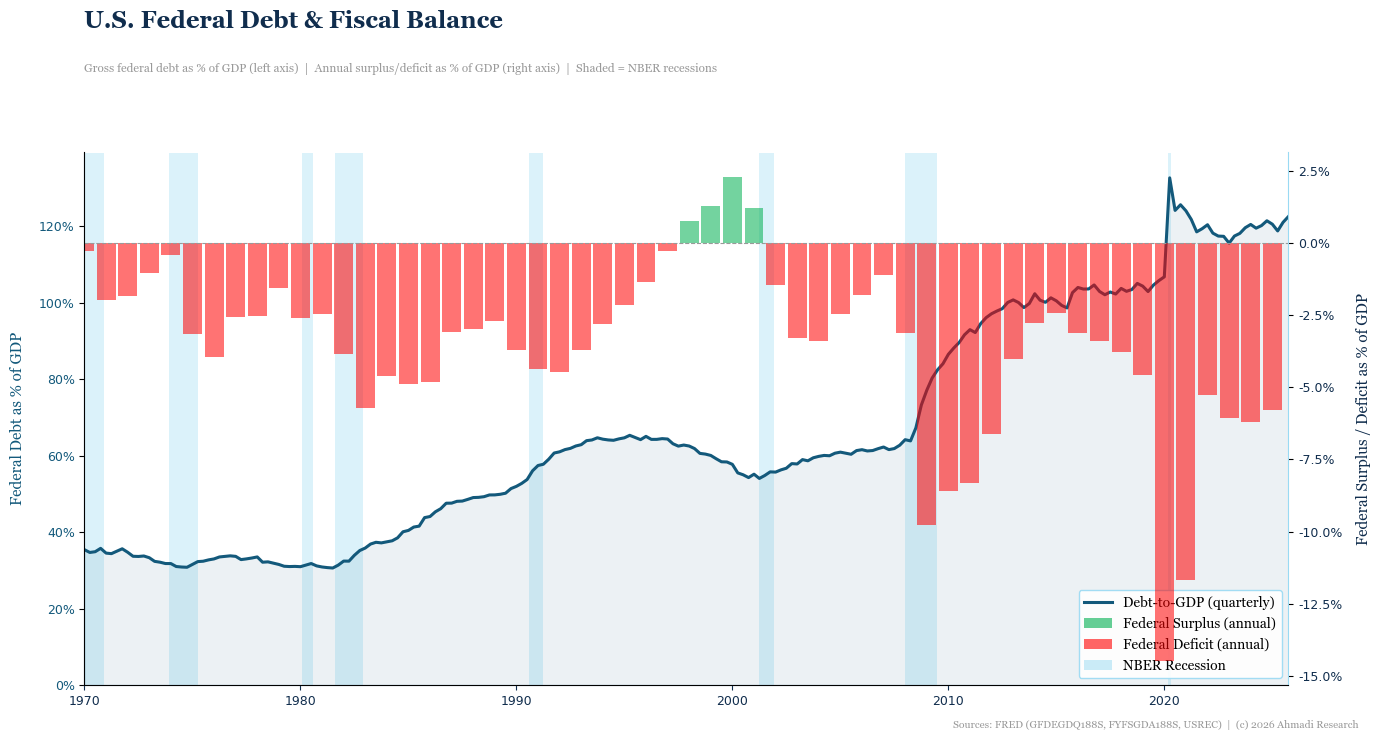

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings("ignore")

# -- BRAND PALETTE -------------------------------------------------------------
NAVY       = "#102D4D"
DARK_TEAL  = "#13597B"
LIGHT_BLUE = "#99DAF3"
WHITE      = "#FFFFFF"
GREY       = "#999999"
RED        = "#FF0000"
GREEN      = "#00B050"

# -- FETCH DATA ----------------------------------------------------------------

debt_gdp    = load("GFDEGDQ188S")
deficit_gdp = load("FYFSGDA188S")
recession   = load("USREC")

# -- NBER RECESSION BANDS ------------------------------------------------------
def get_bands(rec):
    bands, in_rec, start = [], False, None
    for date, val in rec.items():
        if val == 1 and not in_rec:
            in_rec, start = True, date
        elif val == 0 and in_rec:
            in_rec = False
            bands.append((start, date))
    if in_rec:
        bands.append((start, rec.index[-1]))
    return bands

bands = get_bands(recession)

# -- PLOT ----------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(14, 7.5))
fig.patch.set_facecolor(WHITE)
ax1.set_facecolor(WHITE)

fig.subplots_adjust(top=0.78, bottom=0.07, left=0.07, right=0.93)

for s, e in bands:
    ax1.axvspan(s, e, color=LIGHT_BLUE, alpha=0.35, linewidth=0, zorder=0)

ax1.plot(debt_gdp.index, debt_gdp.values, color=DARK_TEAL, linewidth=2.2, zorder=3)
ax1.fill_between(debt_gdp.index, debt_gdp.values, color=DARK_TEAL, alpha=0.08, zorder=2)
ax1.set_ylabel("Federal Debt as % of GDP", color=DARK_TEAL, fontsize=11, fontfamily="Georgia", labelpad=10)
ax1.tick_params(axis="y", labelcolor=DARK_TEAL, labelsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}%"))
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
colours = [GREEN if v >= 0 else RED for v in deficit_gdp.values]
ax2.bar(deficit_gdp.index, deficit_gdp.values, color=colours, alpha=0.55, width=320, zorder=1)
ax2.axhline(0, color=GREY, linewidth=0.8, linestyle="--", zorder=2)
ax2.set_ylabel("Federal Surplus / Deficit as % of GDP", color=NAVY, fontsize=11, fontfamily="Georgia", labelpad=10)
ax2.tick_params(axis="y", labelcolor=NAVY, labelsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

ax1.set_xlim(pd.Timestamp("1970-01-01"), debt_gdp.index[-1])
ax1.tick_params(axis="x", labelsize=9, colors=NAVY)
for spine in ["bottom", "left"]:
    ax1.spines[spine].set_color(LIGHT_BLUE)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax2.spines["right"].set_color(LIGHT_BLUE)
ax2.spines["top"].set_visible(False)

fig.text(0.07, 0.97, "U.S. Federal Debt & Fiscal Balance",
         fontsize=17, fontfamily="Georgia", fontweight="bold",
         color=NAVY, va="top", transform=fig.transFigure)

fig.text(0.07, 0.90,
         "Gross federal debt as % of GDP (left axis)  |  Annual surplus/deficit as % of GDP (right axis)  |  Shaded = NBER recessions",
         fontsize=8.5, fontfamily="Georgia", color=GREY,
         va="top", transform=fig.transFigure)

legend_elements = [
    Line2D([0], [0], color=DARK_TEAL, linewidth=2.2, label="Debt-to-GDP (quarterly)"),
    mpatches.Patch(facecolor=GREEN,      alpha=0.6, label="Federal Surplus (annual)"),
    mpatches.Patch(facecolor=RED,        alpha=0.6, label="Federal Deficit (annual)"),
    mpatches.Patch(facecolor=LIGHT_BLUE, alpha=0.5, label="NBER Recession"),
]
ax1.legend(handles=legend_elements, loc="lower right",
           frameon=True, framealpha=0.9, edgecolor=LIGHT_BLUE,
           fontsize=9, prop={"family": "Georgia"})

fig.text(0.98, 0.01,
         "Sources: FRED (GFDEGDQ188S, FYFSGDA188S, USREC)  |  (c) 2026 Ahmadi Research",
         fontsize=7.5, color=GREY, ha="right", va="bottom", fontfamily="Georgia")

plt.show()


## Section I.3, CBO Long-Term Debt-to-GDP, Baseline vs. Alternative Scenarios, 2025-2055

CBO Extended Baseline against five alternative scenarios from the May 2025 Long-Term Budget Outlook (Pub. 61429). Anchor years drawn from CBO's published tables; intermediate years are cubic-spline interpolations between anchors.


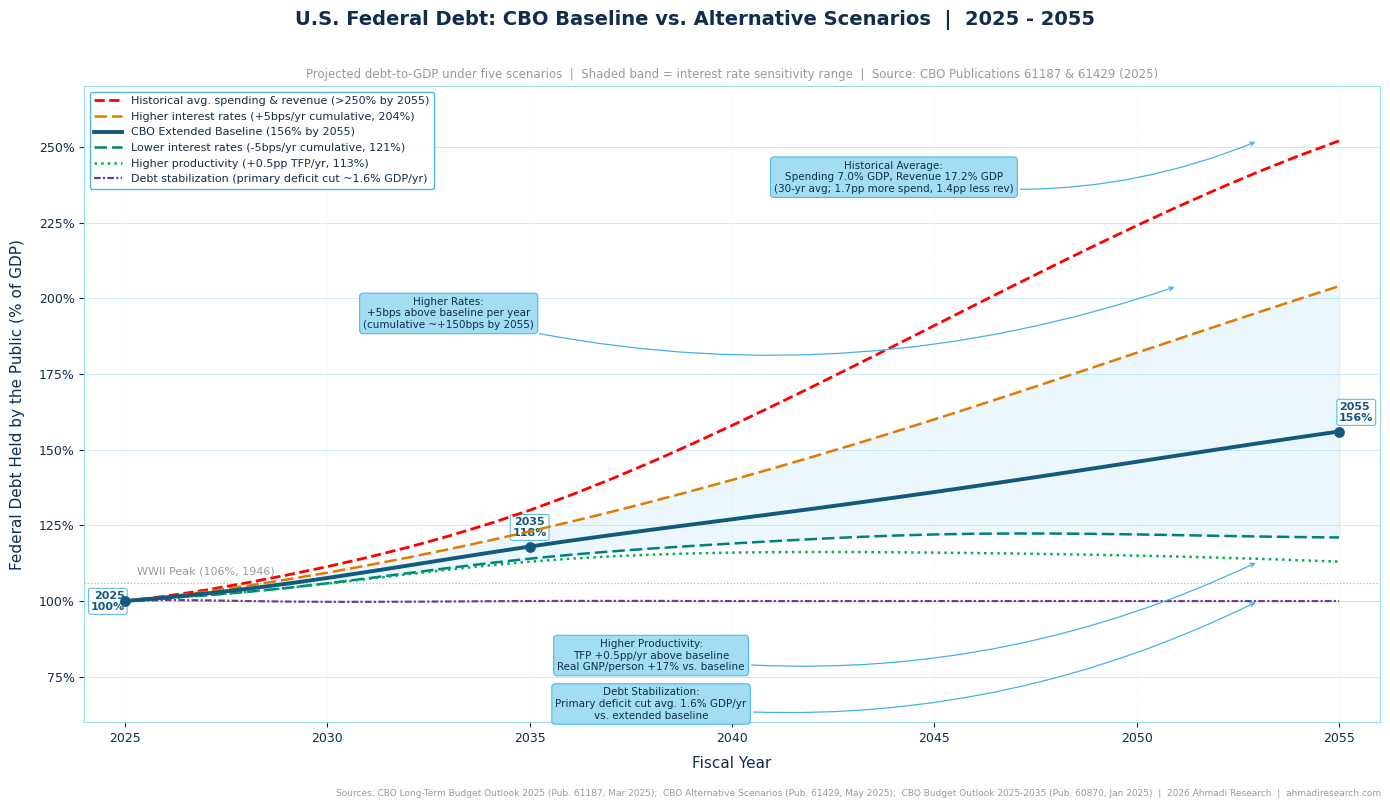

In [3]:
# CBO Long-Term Debt-to-GDP Projections: Baseline vs. Alternative Scenarios
# Sources:
#   CBO Long-Term Budget Outlook 2025 (March 2025) - Publication 61187
#   CBO Long-Term Budget Outlook Under Alternative Scenarios (May 2025) - Publication 61429
#   CBO Budget and Economic Outlook 2025-2035 (January 2025) - Publication 60870
#

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import CubicSpline

# Brand Palette
DARK_BLUE  = "#13597B"
MID_BLUE   = "#44B2E3"
LIGHT_BLUE = "#99DAF3"
NAVY       = "#102D4D"
RED        = "#FF0000"
GREEN      = "#00B050"
BG         = "#FFFFFF"
GREY       = "#999999"
ORANGE     = "#E07B00"
PURPLE     = "#6A3D9A"
TEAL       = "#008080"

# ------------------------------------------------------------------
# CBO Anchor Data Points  (Federal Debt Held by Public as % of GDP)
# ------------------------------------------------------------------

# EXTENDED BASELINE  (CBO Pub. 61187, Mar 2025)
baseline_anchors = {
    2024: 99,
    2025: 100,
    2028: 104,
    2035: 118,
    2040: 127,
    2045: 136,
    2050: 146,
    2055: 156,
}

# HISTORICAL AVERAGE SCENARIO  (CBO Pub. 61429, May 2025)
historical_avg_anchors = {
    2024: 99,
    2025: 100,
    2028: 106,
    2035: 130,
    2040: 158,
    2045: 191,
    2050: 224,
    2055: 252,
}

# HIGH INTEREST RATE SCENARIO  (CBO Pub. 61429, May 2025)
high_rate_anchors = {
    2024: 99,
    2025: 100,
    2028: 105,
    2035: 123,
    2040: 140,
    2045: 160,
    2050: 182,
    2055: 204,
}

# LOW INTEREST RATE SCENARIO  (CBO Pub. 61429, May 2025)
low_rate_anchors = {
    2024: 99,
    2025: 100,
    2028: 103,
    2035: 114,
    2040: 119,
    2045: 122,
    2050: 122,
    2055: 121,
}

# HIGH PRODUCTIVITY SCENARIO  (CBO Pub. 61429, May 2025)
high_tfp_anchors = {
    2024: 99,
    2025: 100,
    2028: 103,
    2035: 113,
    2040: 116,
    2045: 116,
    2050: 115,
    2055: 113,
}

# DEBT STABILIZATION SCENARIO  (CBO Pub. 61429, May 2025)
stabilization_anchors = {
    2024: 99,
    2025: 100,
    2028: 100,
    2035: 100,
    2040: 100,
    2045: 100,
    2050: 100,
    2055: 100,
}

# ------------------------------------------------------------------
# Interpolation: cubic spline between anchor years
# ------------------------------------------------------------------

def interpolate_scenario(anchors):
    years  = np.array(sorted(anchors.keys()))
    values = np.array([anchors[y] for y in years])
    cs     = CubicSpline(years, values)
    full_years = np.arange(2024, 2056)
    return full_years, cs(full_years)

yrs_base,   vals_base   = interpolate_scenario(baseline_anchors)
yrs_hist,   vals_hist   = interpolate_scenario(historical_avg_anchors)
yrs_hirate, vals_hirate = interpolate_scenario(high_rate_anchors)
yrs_lorate, vals_lorate = interpolate_scenario(low_rate_anchors)
yrs_tfp,    vals_tfp    = interpolate_scenario(high_tfp_anchors)
yrs_stab,   vals_stab   = interpolate_scenario(stabilization_anchors)

proj_mask = yrs_base >= 2025

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG)
ax.set_facecolor(BG)

# Interest rate sensitivity band
ax.fill_between(
    yrs_hirate, vals_lorate, vals_hirate,
    color=MID_BLUE, alpha=0.10, zorder=1
)

# Historical Average
ax.plot(
    yrs_hist[proj_mask], vals_hist[proj_mask],
    color=RED, linewidth=2.0, linestyle="--", zorder=4,
    label="Historical avg. spending & revenue (>250% by 2055)"
)

# High Interest Rate
ax.plot(
    yrs_hirate[proj_mask], vals_hirate[proj_mask],
    color=ORANGE, linewidth=1.8, linestyle=(0, (5, 2)), zorder=4,
    label="Higher interest rates (+5bps/yr cumulative, 204%)"
)

# Extended Baseline
ax.plot(
    yrs_base[proj_mask], vals_base[proj_mask],
    color=DARK_BLUE, linewidth=2.8, zorder=5,
    label="CBO Extended Baseline (156% by 2055)"
)

# Low Interest Rate
ax.plot(
    yrs_lorate[proj_mask], vals_lorate[proj_mask],
    color=TEAL, linewidth=1.8, linestyle=(0, (5, 2)), zorder=4,
    label="Lower interest rates (-5bps/yr cumulative, 121%)"
)

# High Productivity
ax.plot(
    yrs_tfp[proj_mask], vals_tfp[proj_mask],
    color=GREEN, linewidth=1.8, linestyle=":", zorder=4,
    label="Higher productivity (+0.5pp TFP/yr, 113%)"
)

# Debt Stabilization
ax.plot(
    yrs_stab[proj_mask], vals_stab[proj_mask],
    color=PURPLE, linewidth=1.6, linestyle=(0, (3, 1, 1, 1)), zorder=4,
    label="Debt stabilization (primary deficit cut ~1.6% GDP/yr)"
)

# ------------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------------

ax.axhline(106, color=GREY, linewidth=0.9, linestyle=":", alpha=0.7, zorder=2)
ax.text(2025.3, 108, "WWII Peak (106%, 1946)", fontsize=8, color=GREY, va="bottom")
ax.axhline(100, color=GREY, linewidth=0.7, linestyle=":", alpha=0.5, zorder=2)

# ------------------------------------------------------------------
# Baseline dot markers
# ------------------------------------------------------------------

labels_pos = [
    (2025, 100, "2025\n100%", "right",  -8),
    (2035, 118, "2035\n118%", "center",  6),
    (2055, 156, "2055\n156%", "left",    6),
]

for yr, val, lbl, ha, yoff in labels_pos:
    ax.scatter(yr, val, color=DARK_BLUE, s=45, zorder=6, clip_on=False)
    ax.annotate(
        lbl,
        xy=(yr, val),
        xytext=(0, yoff),
        textcoords="offset points",
        ha=ha, va="bottom",
        fontsize=8, color=DARK_BLUE, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc=BG, ec=MID_BLUE, alpha=0.85, linewidth=0.8)
    )

# ------------------------------------------------------------------
# Policy assumption callout annotations
# ------------------------------------------------------------------

annotations = [
    (2044, 240,
     "Historical Average:\nSpending 7.0% GDP, Revenue 17.2% GDP\n(30-yr avg; 1.7pp more spend, 1.4pp less rev)",
     2053, 252),
    (2033, 195,
     "Higher Rates:\n+5bps above baseline per year\n(cumulative ~+150bps by 2055)",
     2051, 204),
    (2038, 82,
     "Higher Productivity:\nTFP +0.5pp/yr above baseline\nReal GNP/person +17% vs. baseline",
     2053, 113),
    (2038, 66,
     "Debt Stabilization:\nPrimary deficit cut avg. 1.6% GDP/yr\nvs. extended baseline",
     2053, 100),
]

for (tx, ty, text, ax_x, ax_y) in annotations:
    ax.annotate(
        text,
        xy=(ax_x, ax_y),
        xytext=(tx, ty),
        fontsize=7.5, color=NAVY,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.35", fc=LIGHT_BLUE, ec=MID_BLUE, alpha=0.90, linewidth=0.8),
        arrowprops=dict(arrowstyle="->", color=MID_BLUE, lw=0.9, connectionstyle="arc3,rad=0.15"),
        zorder=7
    )

# ------------------------------------------------------------------
# Axes formatting
# ------------------------------------------------------------------

ax.set_xlim(2024, 2056)
ax.set_ylim(60, 270)
ax.set_xlabel("Fiscal Year", fontsize=11, color=NAVY, labelpad=8)
ax.set_ylabel("Federal Debt Held by the Public (% of GDP)", fontsize=11, color=NAVY, labelpad=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.tick_params(colors=NAVY, labelsize=9)

for spine in ax.spines.values():
    spine.set_color(LIGHT_BLUE)

ax.grid(axis="y", color=LIGHT_BLUE, linewidth=0.6, alpha=0.6, linestyle="-")
ax.grid(axis="x", color=LIGHT_BLUE, linewidth=0.4, alpha=0.4, linestyle=":")

ax.legend(loc="upper left", fontsize=8, framealpha=0.95, edgecolor=MID_BLUE, labelcolor=NAVY, handlelength=2.5)

# ------------------------------------------------------------------
# Titles and footer
# ------------------------------------------------------------------

fig.suptitle(
    "U.S. Federal Debt: CBO Baseline vs. Alternative Scenarios  |  2025 - 2055",
    fontsize=14, fontweight="bold", color=NAVY, y=0.99
)

ax.set_title(
    "Projected debt-to-GDP under five scenarios  |  Shaded band = interest rate sensitivity range  |  Source: CBO Publications 61187 & 61429 (2025)",
    fontsize=8.5, color=GREY, pad=6
)

fig.text(
    0.99, 0.005,
    "Sources: CBO Long-Term Budget Outlook 2025 (Pub. 61187, Mar 2025);  CBO Alternative Scenarios (Pub. 61429, May 2025);  CBO Budget Outlook 2025-2035 (Pub. 60870, Jan 2025)  |  2026 Ahmadi Research  |  ahmadiresearch.com",
    ha="right", va="bottom", fontsize=6.5, color=GREY
)

plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()


## Section II, Key Fiscal Metrics, Interest Expense Trap, and Maturity Structure

Three figures supporting Section II of the deck:

- **2.1**, Gross federal debt, debt held by the public as a share of GDP, and net interest expense across FY2019, FY2022, FY2025, and the CBO FY2035 baseline.
- **2.2**, Net interest under three rate scenarios (rates hold, fall 100bps, rise 150bps) and federal spending composition by category.
- **2.3**, Treasury debt by maturity bucket plus the weighted-average maturity time series, 2001-2025.


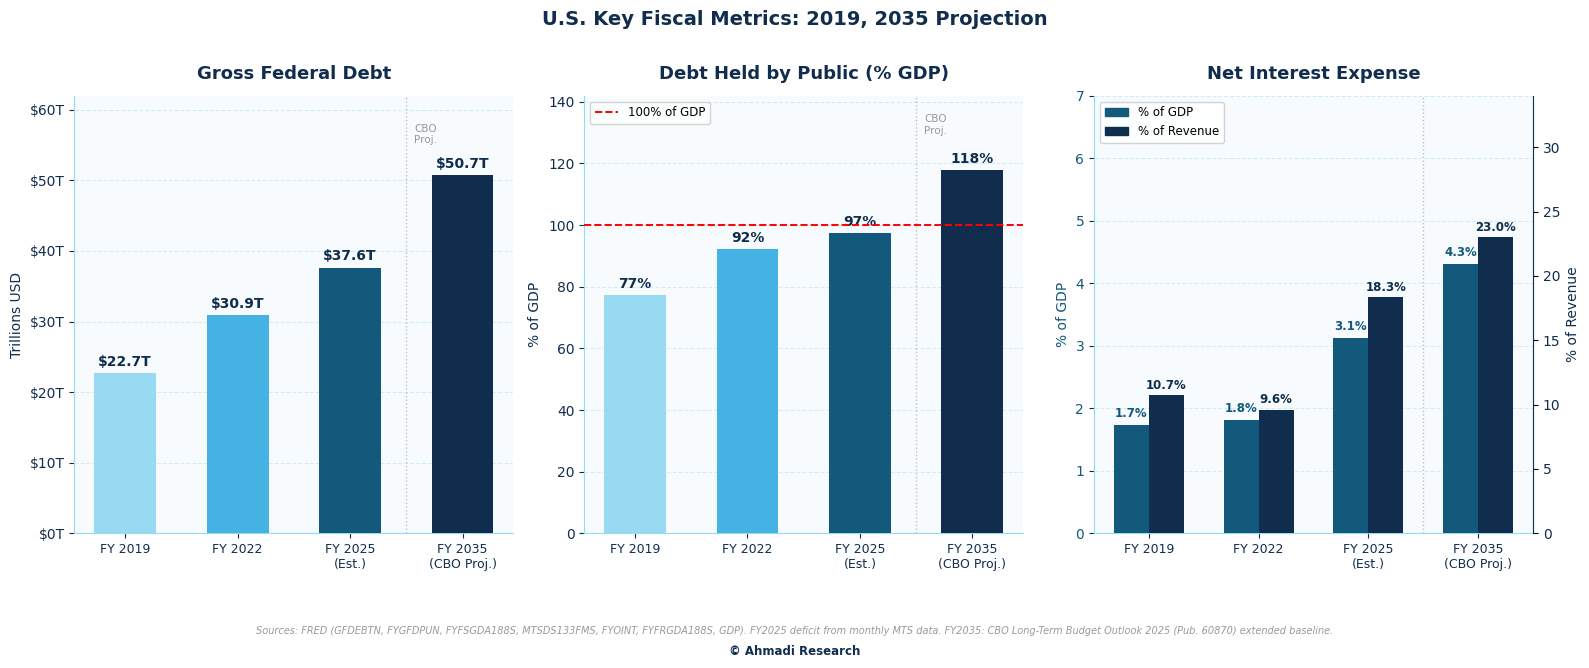

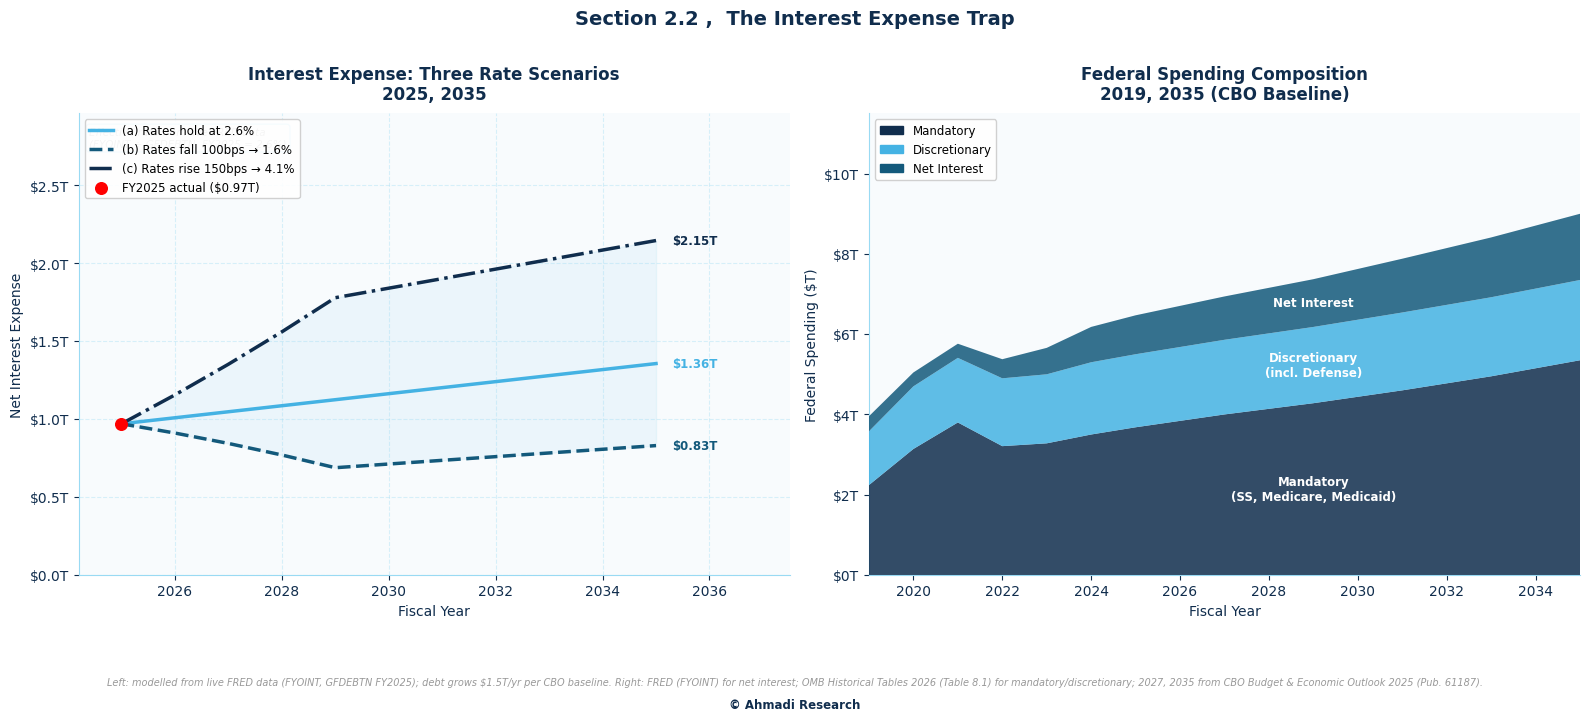

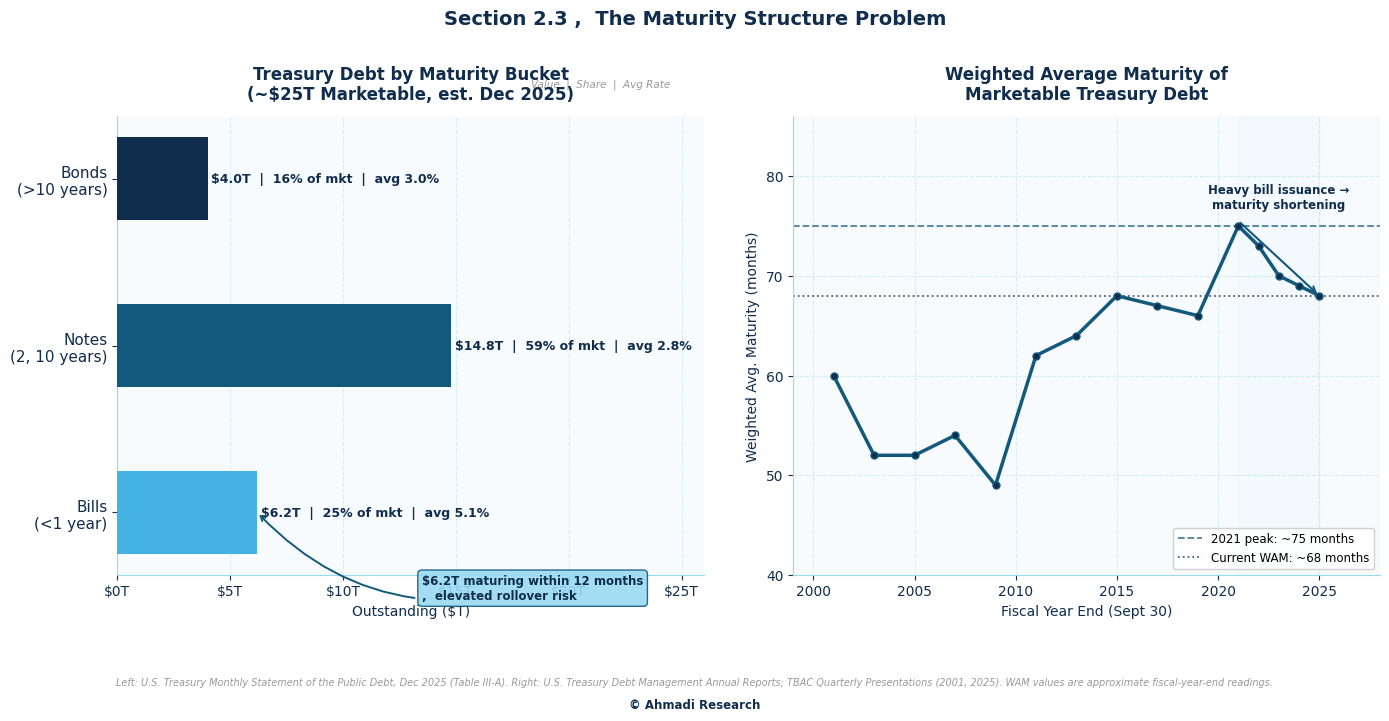

In [4]:
import io
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

try:
    import requests
except ImportError:
    sys.exit("Run:  pip install requests")

warnings.filterwarnings("ignore")


# ==============================================================================
# BRAND PALETTE
# ==============================================================================
NAVY       = "#102D4D"
TEAL       = "#13597B"
BLUE       = "#44B2E3"
LIGHT_BLUE = "#99DAF3"
RED        = "#FF0000"   # reserved for true warnings only
GREEN      = "#00B050"
GRAY       = "#999999"
BG         = "#F8FBFD"

CHART_DPI  = 180


# ==============================================================================
# FISCAL-YEAR HELPERS
# ==============================================================================
def q4_fy(series, fy):
    """Q4 of a fiscal year = July, Sept of calendar year fy."""
    sub = series[
        (series.index.year == fy) &
        (series.index.month.isin([7, 8, 9]))
    ]
    return float(sub.iloc[-1]) if len(sub) else np.nan


def annual_fy(series, fy):
    """
    FRED annual FY series use Jan 1 of the matching CY (e.g. FY2024 = 2024-01-01).
    FYOINT uses Sept 30. We try both.
    """
    for ts in [f"{fy}-01-01", f"{fy}-09-30"]:
        t = pd.Timestamp(ts)
        if t in series.index:
            return float(series[t])
    return np.nan


# ==============================================================================
# LOAD ALL FRED DATA
# ==============================================================================
gross_debt_q = fetch_fred("GFDEBTN")       # Gross federal debt, $M, quarterly
dhbp_q       = fetch_fred("FYGFDPUN")      # Debt held by public, $M, quarterly
deficit_ann  = fetch_fred("FYFSGDA188S")   # Deficit as % GDP, annual FY
deficit_mo   = fetch_fred("MTSDS133FMS")   # Monthly surplus/deficit, $M
net_int_ann  = fetch_fred("FYOINT")        # Net interest outlays, $M, annual FY
revenue_ann  = fetch_fred("FYFRGDA188S")   # Federal revenue as % GDP, annual FY
gdp_q        = fetch_fred("GDP")           # Nominal GDP, $B, quarterly


# ==============================================================================
# DERIVED METRIC FUNCTIONS
# ==============================================================================
def gdp_fy_bil(fy):
    return q4_fy(gdp_q, fy)

def gross_debt_t(fy):
    return q4_fy(gross_debt_q, fy) / 1_000_000

def dhbp_pct_gdp(fy):
    d = q4_fy(dhbp_q, fy)
    g = gdp_fy_bil(fy) * 1_000
    return (d / g * 100) if (d and g) else np.nan

def deficit_pct_gdp(fy):
    """Uses monthly data for FY2025 because FRED annual series lags one year."""
    val = annual_fy(deficit_ann, fy)
    if not np.isnan(val):
        return val
    sub = deficit_mo[
        (deficit_mo.index >= f"{fy-1}-10-01") &
        (deficit_mo.index <= f"{fy}-09-30")
    ]
    if len(sub) >= 12:
        g = gdp_fy_bil(fy) * 1_000
        return (sub.sum() / g * 100) if g else np.nan
    return np.nan

def net_int_pct_gdp(fy):
    ni = annual_fy(net_int_ann, fy)
    g  = gdp_fy_bil(fy) * 1_000
    return (ni / g * 100) if (ni and g) else np.nan

def net_int_pct_rev(fy):
    ni      = annual_fy(net_int_ann, fy)
    rev_pct = annual_fy(revenue_ann, fy)
    g       = gdp_fy_bil(fy) * 1_000
    rev_mil = (rev_pct / 100) * g if (rev_pct and g) else None
    return (ni / rev_mil * 100) if (ni and rev_mil) else np.nan

def primary_deficit_pct(fy):
    d  = deficit_pct_gdp(fy)
    ni = net_int_pct_gdp(fy)
    return (d + ni) if (not np.isnan(d) and not np.isnan(ni)) else np.nan


# ==============================================================================
# TABLE 1 DATA
# FY2035 hardcoded from CBO Long-Term Budget Outlook 2025 (Pub. 60870)
# and CBO Budget & Economic Outlook 2025 (Pub. 61187)
# ==============================================================================
CBO_2035 = {
    "gross_debt_t"   : 50.7,
    "dhbp_pct_gdp"   : 118.0,
    "deficit_pct_gdp": -6.1,
    "primary_deficit": -1.8,
    "ni_pct_gdp"     :  4.3,
    "ni_pct_rev"     : 23.0,
}

ALL_FY  = [2019, 2022, 2025, 2035]
LABELS  = ["FY 2019", "FY 2022", "FY 2025\n(Est.)", "FY 2035\n(CBO Proj.)"]

T = {}
for fy in [2019, 2022, 2025]:
    T[fy] = {
        "gross_debt_t"   : gross_debt_t(fy),
        "dhbp_pct_gdp"   : dhbp_pct_gdp(fy),
        "deficit_pct_gdp": deficit_pct_gdp(fy),
        "primary_deficit": primary_deficit_pct(fy),
        "ni_pct_gdp"     : net_int_pct_gdp(fy),
        "ni_pct_rev"     : net_int_pct_rev(fy),
    }
T[2035] = CBO_2035


# ==============================================================================
# SHARED AXIS STYLER
# ==============================================================================
def style_ax(ax):
    ax.set_facecolor(BG)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color(LIGHT_BLUE)
    ax.spines["bottom"].set_color(LIGHT_BLUE)
    ax.tick_params(colors=NAVY)
    ax.yaxis.set_tick_params(labelcolor=NAVY)
    ax.xaxis.set_tick_params(labelcolor=NAVY)


# ==============================================================================
# CHART 1 ,  KEY FISCAL METRICS (three-panel bar chart)
# ==============================================================================
def chart1():

    x    = np.arange(4)
    cols = [LIGHT_BLUE, BLUE, TEAL, NAVY]   # lightest → darkest across time

    v_debt   = [T[fy]["gross_debt_t"]    for fy in ALL_FY]
    v_dhbp   = [T[fy]["dhbp_pct_gdp"]   for fy in ALL_FY]
    v_ni_gdp = [T[fy]["ni_pct_gdp"]     for fy in ALL_FY]
    v_ni_rev = [T[fy]["ni_pct_rev"]     for fy in ALL_FY]

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.patch.set_facecolor("white")

    # ── Panel 1: Gross Federal Debt ──────────────────────────────────────────
    ax = axes[0]
    style_ax(ax)
    ax.grid(axis="y", linestyle="--", alpha=0.4, color=LIGHT_BLUE, zorder=0)
    ax.axvline(2.5, color=GRAY, linestyle=":", lw=1.0, alpha=0.6)

    bars = ax.bar(x, v_debt, color=cols, width=0.55, zorder=3)
    for b, v in zip(bars, v_debt):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.6,
                f"${v:.1f}T", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=NAVY)

    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=9, color=NAVY)
    ax.set_ylabel("Trillions USD", fontsize=10, color=NAVY)
    ax.set_ylim(0, 62)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${int(v)}T"))
    ax.set_title("Gross Federal Debt",
                 fontsize=13, fontweight="bold", color=NAVY, pad=12)
    ax.text(2.57, 58, "CBO\nProj.", fontsize=7.5, color=GRAY, va="top")

    # ── Panel 2: Debt Held by Public % GDP ───────────────────────────────────
    ax = axes[1]
    style_ax(ax)
    ax.grid(axis="y", linestyle="--", alpha=0.4, color=LIGHT_BLUE, zorder=0)
    ax.axvline(2.5, color=GRAY, linestyle=":", lw=1.0, alpha=0.6)

    bars = ax.bar(x, v_dhbp, color=cols, width=0.55, zorder=3)
    for b, v in zip(bars, v_dhbp):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.2,
                f"{v:.0f}%", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=NAVY)

    ax.axhline(100, color=RED, linestyle="--", lw=1.4, zorder=4,
               label="100% of GDP")
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=9, color=NAVY)
    ax.set_ylabel("% of GDP", fontsize=10, color=NAVY)
    ax.set_ylim(0, 142)
    ax.set_title("Debt Held by Public (% GDP)",
                 fontsize=13, fontweight="bold", color=NAVY, pad=12)
    ax.legend(fontsize=8.5, loc="upper left", framealpha=0.85)
    ax.text(2.57, 136, "CBO\nProj.", fontsize=7.5, color=GRAY, va="top")

    # ── Panel 3: Net Interest ,  dual axis ────────────────────────────────────
    ax  = axes[2]
    ax2 = ax.twinx()
    style_ax(ax)
    ax.grid(axis="y", linestyle="--", alpha=0.4, color=LIGHT_BLUE, zorder=0)
    ax.axvline(2.5, color=GRAY, linestyle=":", lw=1.0, alpha=0.6)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_color(LIGHT_BLUE)
    for sp in ["top", "left", "bottom"]:
        ax2.spines[sp].set_visible(False)
    ax2.spines["right"].set_color(NAVY)
    ax2.tick_params(axis="y", labelcolor=NAVY)

    w  = 0.32
    b1 = ax.bar(x - w / 2, v_ni_gdp, width=w, color=TEAL, zorder=3)
    b2 = ax2.bar(x + w / 2, v_ni_rev, width=w, color=NAVY, zorder=3)

    for b, v in zip(b1, v_ni_gdp):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.08,
                f"{v:.1f}%", ha="center", va="bottom",
                fontsize=8.5, fontweight="bold", color=TEAL)
    for b, v in zip(b2, v_ni_rev):
        ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.25,
                 f"{v:.1f}%", ha="center", va="bottom",
                 fontsize=8.5, fontweight="bold", color=NAVY)

    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=9, color=NAVY)
    ax.set_ylabel("% of GDP", fontsize=10, color=TEAL)
    ax.tick_params(axis="y", labelcolor=TEAL)
    ax2.set_ylabel("% of Revenue", fontsize=10, color=NAVY)
    ax.set_ylim(0, 7)
    ax2.set_ylim(0, 34)
    ax.set_title("Net Interest Expense",
                 fontsize=13, fontweight="bold", color=NAVY, pad=12)
    ax.legend(
        handles=[mpatches.Patch(color=TEAL, label="% of GDP"),
                 mpatches.Patch(color=NAVY, label="% of Revenue")],
        fontsize=8.5, loc="upper left", framealpha=0.85)

    # ── Titles & footnotes ───────────────────────────────────────────────────
    fig.suptitle("U.S. Key Fiscal Metrics: 2019, 2035 Projection",
                 fontsize=14, fontweight="bold", color=NAVY, y=1.01)
    fig.text(0.5, -0.03,
             "Sources: FRED (GFDEBTN, FYGFDPUN, FYFSGDA188S, MTSDS133FMS, "
             "FYOINT, FYFRGDA188S, GDP). "
             "FY2025 deficit from monthly MTS data. "
             "FY2035: CBO Long-Term Budget Outlook 2025 (Pub. 60870) extended baseline.",
             ha="center", fontsize=7, color=GRAY, style="italic")
    fig.text(0.5, -0.065, "\u00a9 Ahmadi Research",
             ha="center", fontsize=8.5, color=NAVY, fontweight="bold")

    plt.tight_layout(rect=[0, 0.05, 1, 1])


# ==============================================================================
# CHART 2 ,  THE INTEREST EXPENSE TRAP
# Left:  three rate-scenario projections (modelled from live FRED data)
# Right: federal spending composition stacked area
# ==============================================================================
def chart2():

    # Live anchors from FRED
    ni25   = annual_fy(net_int_ann, 2025) / 1_000_000   # $T
    debt25 = gross_debt_t(2025)
    r0     = ni25 / debt25    # implied effective rate on all outstanding debt


    # Scenario projections 2025, 2035
    yrs   = np.arange(2025, 2036)
    debts = debt25 + 1.5 * np.arange(11)   # ~$1.5T/yr CBO baseline growth

    ra = np.full(11, r0)                                          # (a) hold
    rb = r0 - np.minimum(0.01,  np.arange(11) / 4 * 0.01)       # (b) -100bps
    rc = r0 + np.minimum(0.015, np.arange(11) / 4 * 0.015)      # (c) +150bps

    ia, ib, ic = debts * ra, debts * rb, debts * rc

    # Spending composition ($T) ,  FRED FYOINT (historical net interest) +
    # OMB Historical Tables 2026 (Table 8.1) for mandatory/discretionary split;
    # 2027, 2035 from CBO Budget & Economic Outlook 2025 (Pub. 61187)
    comp_yr   = [2019, 2020, 2021, 2022, 2023, 2024, 2025,
                 2027, 2029, 2031, 2033, 2035]
    mandatory = np.array([2.24, 3.14, 3.80, 3.21, 3.28, 3.50, 3.68,
                          4.00, 4.28, 4.60, 4.95, 5.35])
    discret   = np.array([1.34, 1.56, 1.61, 1.69, 1.72, 1.80, 1.82,
                          1.86, 1.90, 1.94, 1.97, 2.00])
    net_int_s = np.array([0.375, 0.346, 0.352, 0.476, 0.659, 0.881, 0.970,
                          1.08,  1.19,  1.34,  1.49,  1.65])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
    fig.patch.set_facecolor("white")

    # ── Left: rate scenarios ─────────────────────────────────────────────────
    style_ax(ax1)
    ax1.grid(linestyle="--", alpha=0.35, color=LIGHT_BLUE, zorder=0)

    ax1.plot(yrs, ia, color=BLUE,  lw=2.5, zorder=4,
             label=f"(a) Rates hold at {r0 * 100:.1f}%")
    ax1.plot(yrs, ib, color=TEAL,  lw=2.5, ls="--", zorder=4,
             label=f"(b) Rates fall 100bps \u2192 {(r0 - 0.01) * 100:.1f}%")
    ax1.plot(yrs, ic, color=NAVY,  lw=2.5, ls="-.", zorder=4,
             label=f"(c) Rates rise 150bps \u2192 {(r0 + 0.015) * 100:.1f}%")
    ax1.fill_between(yrs, ib, ic, alpha=0.07, color=BLUE)
    ax1.scatter([2025], [ni25], color=RED, s=70, zorder=6,
                label=f"FY2025 actual (${ni25:.2f}T)")

    for vals, color in [(ia, BLUE), (ib, TEAL), (ic, NAVY)]:
        ax1.annotate(f"${vals[-1]:.2f}T",
                     xy=(2035, vals[-1]), xytext=(2035.3, vals[-1]),
                     fontsize=8.5, color=color, fontweight="bold", va="center")

    ax1.set_xlim(2024.2, 2037.5)
    ax1.set_ylim(0, ic[-1] * 1.38)
    ax1.set_xlabel("Fiscal Year", fontsize=10, color=NAVY)
    ax1.set_ylabel("Net Interest Expense", fontsize=10, color=NAVY)
    ax1.set_title("Interest Expense: Three Rate Scenarios\n2025, 2035",
                  fontsize=12, fontweight="bold", color=NAVY, pad=10)
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"${v:.1f}T"))
    ax1.legend(fontsize=8.5, loc="upper left", framealpha=0.9)
    ax1.text(2024.4, ic[-1] * 1.28,
             f"Effective rate from live FRED data\n"
             f"(FYOINT \u00f7 GFDEBTN, FY2025 = {r0 * 100:.1f}%)",
             fontsize=7.5, color=GRAY, style="italic",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                       edgecolor=LIGHT_BLUE, alpha=0.9))

    # ── Right: stacked area ──────────────────────────────────────────────────
    style_ax(ax2)
    ax2.grid(axis="y", linestyle="--", alpha=0.2, color="white", zorder=4)
    ax2.stackplot(comp_yr, mandatory, discret, net_int_s,
                  colors=[NAVY, BLUE, TEAL], alpha=0.85, zorder=3)

    # Labels inside bands
    mid_idx = comp_yr.index(2029)
    cum = 0
    for vals, lbl in [
        (mandatory, "Mandatory\n(SS, Medicare, Medicaid)"),
        (discret,   "Discretionary\n(incl. Defense)"),
        (net_int_s, "Net Interest"),
    ]:
        ax2.text(2029, cum + vals[mid_idx] / 2, lbl,
                 ha="center", va="center", fontsize=8.5,
                 color="white", fontweight="bold")
        cum += vals[mid_idx]

    ax2.set_xlim(2019, 2035)
    ax2.set_ylim(0, 11.5)
    ax2.set_xlabel("Fiscal Year", fontsize=10, color=NAVY)
    ax2.set_ylabel("Federal Spending ($T)", fontsize=10, color=NAVY)
    ax2.set_title("Federal Spending Composition\n2019, 2035 (CBO Baseline)",
                  fontsize=12, fontweight="bold", color=NAVY, pad=10)
    ax2.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"${v:.0f}T"))
    ax2.legend(
        handles=[mpatches.Patch(color=NAVY, label="Mandatory"),
                 mpatches.Patch(color=BLUE, label="Discretionary"),
                 mpatches.Patch(color=TEAL, label="Net Interest")],
        fontsize=8.5, loc="upper left", framealpha=0.9)

    # ── Titles & footnotes ───────────────────────────────────────────────────
    fig.suptitle("Section 2.2 ,  The Interest Expense Trap",
                 fontsize=14, fontweight="bold", color=NAVY, y=1.01)
    fig.text(0.5, -0.03,
             "Left: modelled from live FRED data (FYOINT, GFDEBTN FY2025); "
             "debt grows $1.5T/yr per CBO baseline. "
             "Right: FRED (FYOINT) for net interest; "
             "OMB Historical Tables 2026 (Table 8.1) for mandatory/discretionary; "
             "2027, 2035 from CBO Budget & Economic Outlook 2025 (Pub. 61187).",
             ha="center", fontsize=7, color=GRAY, style="italic")
    fig.text(0.5, -0.065, "\u00a9 Ahmadi Research",
             ha="center", fontsize=8.5, color=NAVY, fontweight="bold")

    plt.tight_layout(rect=[0, 0.05, 1, 1])


# ==============================================================================
# CHART 3 ,  THE MATURITY STRUCTURE PROBLEM
# Left:  maturity bucket horizontal bars
# Right: weighted average maturity time series
# ==============================================================================
def chart3():

    # ── Maturity buckets ─────────────────────────────────────────────────────
    # Source: U.S. Treasury MSPD, December 2025, Table III-A
    BUCKET_LABELS  = ["Bills\n(<1 year)", "Notes\n(2, 10 years)", "Bonds\n(>10 years)"]
    OUTSTANDING_T  = [6.2,  14.8,  4.0]
    SHARE_PCT      = [25.0, 59.0, 16.0]
    AVG_COUPON_PCT = [5.1,   2.8,  3.0]
    BUCKET_COLORS  = [BLUE, TEAL, NAVY]   # all blue-family, light→mid→dark

    # ── Weighted Average Maturity ─────────────────────────────────────────────
    # Source: Treasury Debt Management Annual Reports; TBAC Quarterly Presentations
    WAM_YEARS  = [2001, 2003, 2005, 2007, 2009, 2011, 2013,
                  2015, 2017, 2019, 2021, 2022, 2023, 2024, 2025]
    WAM_MONTHS = [60,   52,   52,   54,   49,   62,   64,
                  68,   67,   66,   75,   73,   70,   69,   68]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))
    fig.patch.set_facecolor("white")

    # ── Left: horizontal bar chart ───────────────────────────────────────────
    style_ax(ax1)
    ax1.grid(axis="x", linestyle="--", alpha=0.4, color=LIGHT_BLUE, zorder=0)

    y     = np.arange(3)
    hbars = ax1.barh(y, OUTSTANDING_T, color=BUCKET_COLORS, height=0.5, zorder=3)

    # All label text in uniform NAVY
    for bar, val, shr, rate in zip(
            hbars, OUTSTANDING_T, SHARE_PCT, AVG_COUPON_PCT):
        ax1.text(bar.get_width() + 0.15,
                 bar.get_y() + bar.get_height() / 2,
                 f"${val}T  |  {shr:.0f}% of mkt  |  avg {rate}%",
                 va="center", fontsize=9, color=NAVY, fontweight="bold")

    ax1.set_yticks(y)
    ax1.set_yticklabels(BUCKET_LABELS, fontsize=11, color=NAVY)
    ax1.set_xlabel("Outstanding ($T)", fontsize=10, color=NAVY)
    ax1.set_xlim(0, 26)
    ax1.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"${v:.0f}T"))
    ax1.set_title("Treasury Debt by Maturity Bucket\n(~$25T Marketable, est. Dec 2025)",
                  fontsize=12, fontweight="bold", color=NAVY, pad=12)
    ax1.text(24.5, 2.55, "Value  |  Share  |  Avg Rate",
             fontsize=7.5, color=GRAY, style="italic", ha="right")

    # Rollover risk callout ,  points to Bills bar (y=0), text placed below
    ax1.annotate(
        "$6.2T maturing within 12 months\n,  elevated rollover risk",
        xy=(6.2, 0),            # tip: end of Bills bar
        xytext=(13.5, -0.52),   # text: below chart, clear of bars
        arrowprops=dict(
            arrowstyle="->", color=TEAL, lw=1.4,
            connectionstyle="arc3,rad=-0.3"),
        fontsize=8.5, color=NAVY, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", facecolor=LIGHT_BLUE,
                  edgecolor=TEAL, alpha=0.9))

    # ── Right: WAM time series ────────────────────────────────────────────────
    style_ax(ax2)
    ax2.grid(linestyle="--", alpha=0.4, color=LIGHT_BLUE, zorder=0)

    ax2.plot(WAM_YEARS, WAM_MONTHS, color=TEAL, lw=2.5, zorder=4,
             marker="o", markersize=5,
             markerfacecolor=NAVY, markeredgecolor=TEAL)

    # Soft highlight for the shortening episode ,  light blue, not red
    ax2.axvspan(2021, 2025, alpha=0.05, color=LIGHT_BLUE, zorder=2)

    # Reference lines in brand colours (no red)
    ax2.axhline(75, color=TEAL, ls="--", lw=1.3, alpha=0.75,
                label="2021 peak: ~75 months")
    ax2.axhline(68, color=NAVY, ls=":",  lw=1.3, alpha=0.75,
                label="Current WAM: ~68 months")

    # Annotation text in NAVY (informational, not alarming)
    ax2.text(2023, max(WAM_MONTHS) + 1.8,
             "Heavy bill issuance \u2192\nmaturity shortening",
             fontsize=8.5, color=NAVY, fontweight="bold", ha="center")

    ax2.annotate("",
                 xy=(2025, 68), xytext=(2021, 75.5),
                 arrowprops=dict(arrowstyle="->", color=TEAL, lw=1.5))

    ax2.set_xlim(1999, 2028)
    ax2.set_ylim(40, 86)
    ax2.set_xlabel("Fiscal Year End (Sept 30)", fontsize=10, color=NAVY)
    ax2.set_ylabel("Weighted Avg. Maturity (months)", fontsize=10, color=NAVY)
    ax2.set_title("Weighted Average Maturity of\nMarketable Treasury Debt",
                  fontsize=12, fontweight="bold", color=NAVY, pad=12)
    ax2.legend(fontsize=8.5, loc="lower right", framealpha=0.9)

    # ── Titles & footnotes ───────────────────────────────────────────────────
    fig.suptitle("Section 2.3 ,  The Maturity Structure Problem",
                 fontsize=14, fontweight="bold", color=NAVY, y=1.01)
    fig.text(0.5, -0.03,
             "Left: U.S. Treasury Monthly Statement of the Public Debt, Dec 2025 "
             "(Table III-A). "
             "Right: U.S. Treasury Debt Management Annual Reports; "
             "TBAC Quarterly Presentations (2001, 2025). "
             "WAM values are approximate fiscal-year-end readings.",
             ha="center", fontsize=7, color=GRAY, style="italic")
    fig.text(0.5, -0.065, "\u00a9 Ahmadi Research",
             ha="center", fontsize=8.5, color=NAVY, fontweight="bold")

    plt.tight_layout(rect=[0, 0.05, 1, 1])


# ==============================================================================
# MAIN
# ==============================================================================
chart1()
chart2()
chart3()
plt.show()


## Section III.1, Fiscal Dominance, r-g Gap and Fed Funds vs. Net Interest

Two-panel chart. Panel A: the r-g gap (10-year Treasury yield minus nominal GDP growth), 1970-present. Panel B: the Fed Funds Rate against net interest expense as a share of GDP, the 'policy trap' where rate hikes feed directly into the deficit. The deck references Panel B.


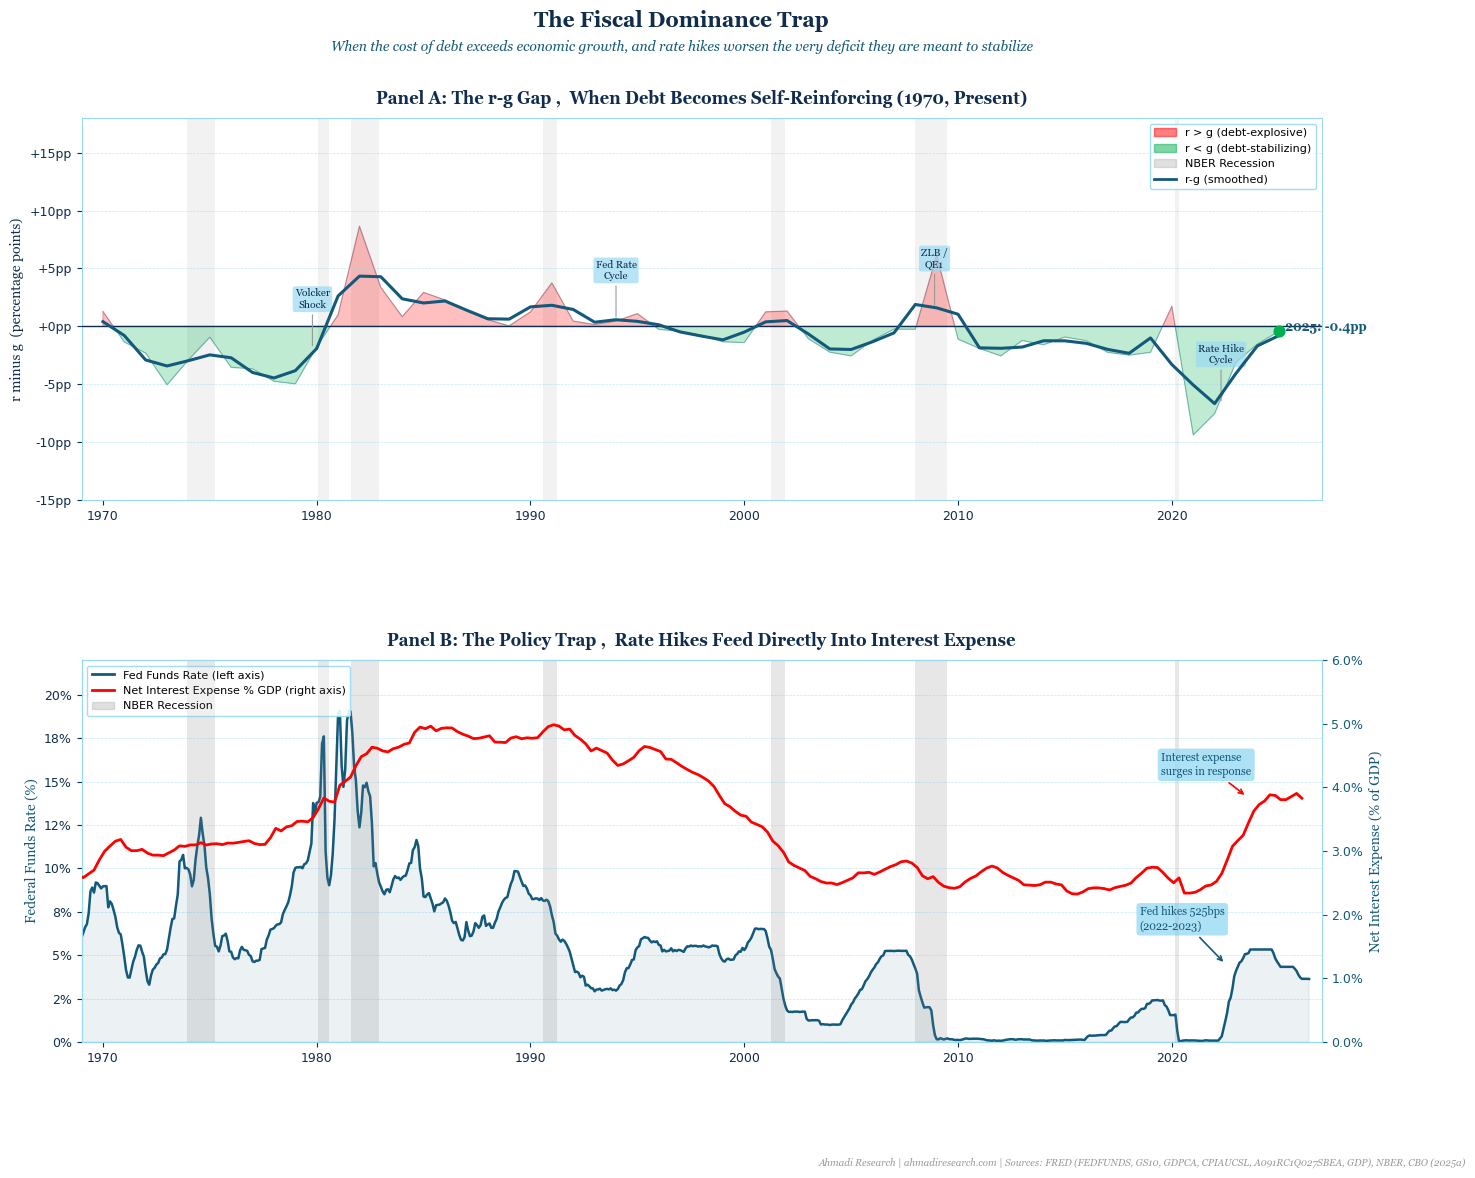

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import requests
from io import StringIO
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# BRAND PALETTE
# =============================================================================
NAVY       = "#102D4D"
DARK_TEAL  = "#13597B"
BLUE       = "#44B2E3"
LIGHT_BLUE = "#99DAF3"
WHITE      = "#FFFFFF"
RED        = "#FF0000"
GREEN      = "#00B050"
GRAY       = "#999999"
ORANGE     = "#E07B00"


# =============================================================================
# SECTION 2: BUILD DATASETS
# =============================================================================

def build_rg_gap():
    """
    Construct annual r - g series from 1970 to present.

    r = 10-year Treasury yield (proxy for avg cost of debt, annual avg)
    g = nominal GDP growth = real GDP growth + CPI inflation

    Returns annual DataFrame with columns: r, g, rg_gap
    """
    # 10-year Treasury (monthly) -> annual average
    gs10    = fetch_fred("GS10", "r")
    gs10_yr = gs10.resample("YE").mean()

    # Real GDP growth (annual % change) -- FRED series GDPCA is levels
    gdpca   = fetch_fred("GDPCA", "real_gdp")
    gdp_gr  = gdpca.pct_change() * 100
    gdp_gr.index = gdp_gr.index.year

    # CPI inflation annual (FRED: CPIAUCSL, annual avg % change)
    cpi     = fetch_fred("CPIAUCSL", "cpi")
    cpi_yr  = cpi.resample("YE").mean()
    infl    = cpi_yr.pct_change() * 100

    # Nominal GDP growth = real growth + inflation (approximate)
    gs10_yr.index = gs10_yr.index.year
    infl.index    = infl.index.year

    df = pd.DataFrame({
        "r": gs10_yr,
        "inflation": infl,
    })
    df["real_g"] = pd.Series(gdp_gr)
    df["g"]      = df["real_g"] + df["inflation"]
    df["rg_gap"] = df["r"] - df["g"]

    # Filter to 1970 onwards and drop NaN
    df = df[df.index >= 1970].dropna(subset=["rg_gap"])
    return df


def build_fed_interest():
    """
    Build dataset of:
      - Fed Funds Rate (monthly)
      - Net Interest Expense as % of GDP (quarterly)

    Returns (quarterly DataFrame, monthly fed funds Series).
    """
    # Fed Funds Rate (monthly)
    fedfunds = fetch_fred("FEDFUNDS", "fed_funds")

    # Net interest payments (quarterly, $billions annualized)
    net_int = fetch_fred("A091RC1Q027SBEA", "net_interest_bn")

    # Nominal GDP (quarterly, $billions annualized)
    gdp_nom = fetch_fred("GDP", "gdp_bn")

    # Merge on common quarterly index
    merged = pd.DataFrame({
        "net_interest_bn": net_int,
        "gdp_bn":          gdp_nom,
    }).dropna()
    merged["net_interest_pct_gdp"] = merged["net_interest_bn"] / merged["gdp_bn"] * 100

    # Average fed funds to quarterly -- use period start to align with FRED quarters
    ff_qtr = fedfunds.resample("QS").mean()
    # Snap to quarter-start dates matching FRED (first day of quarter)
    ff_aligned = ff_qtr.reindex(merged.index, method="nearest", tolerance=pd.Timedelta("95D"))
    merged["fed_funds"] = ff_aligned

    qdf = merged[["fed_funds", "net_interest_pct_gdp"]].dropna()
    return qdf, fedfunds


# =============================================================================
# SECTION 3: NBER RECESSION SHADING
# =============================================================================

# NBER recession dates (start, end) -- hardcoded for reliability
# Source: NBER Business Cycle Dating Committee
RECESSIONS = [
    ("1973-11", "1975-03"),
    ("1980-01", "1980-07"),
    ("1981-07", "1982-11"),
    ("1990-07", "1991-03"),
    ("2001-03", "2001-11"),
    ("2007-12", "2009-06"),
    ("2020-02", "2020-04"),
]

def add_recession_shading(ax, xmin=1970, xmax=2026, alpha=0.12, color=GRAY):
    """Add NBER recession bands to an axis."""
    for start, end in RECESSIONS:
        s = pd.Timestamp(start)
        e = pd.Timestamp(end)
        sx = s.year + s.month / 12
        ex = e.year + e.month / 12
        if ex >= xmin and sx <= xmax:
            ax.axvspan(max(sx, xmin), min(ex, xmax),
                       color=color, alpha=alpha, linewidth=0, zorder=0)


# =============================================================================
# SECTION 4: KEY POLICY EVENTS ANNOTATIONS
# =============================================================================

# (year, label, y_offset_multiplier)
POLICY_EVENTS = [
    (1979.8, "Volcker\nShock",       1),
    (1994.0, "Fed Rate\nCycle",      1),
    (2008.9, "ZLB /\nQE1",          1),
    (2022.3, "Rate Hike\nCycle",     1),
]


# =============================================================================
# SECTION 5: PLOT
# =============================================================================

def plot_section3(rg_df, qdf, fedfunds_monthly):
    """
    Two-panel figure:
      Top    -- r-g gap (annual bars + smoothed line, shaded by sign)
      Bottom -- Fed Funds Rate vs Net Interest Expense % GDP (dual axis)
    """

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(16, 12),
        facecolor=WHITE,
        gridspec_kw={"height_ratios": [1, 1], "hspace": 0.42}
    )

    # -------------------------------------------------------------------------
    # PANEL A: r - g GAP
    # -------------------------------------------------------------------------
    ax1.set_facecolor(WHITE)
    years   = rg_df.index.astype(int)
    rg      = rg_df["rg_gap"].values

    # Shade above/below zero
    ax1.axhline(0, color=NAVY, linewidth=1.0, zorder=3)
    ax1.fill_between(years, rg, 0,
                     where=(rg > 0),
                     interpolate=True,
                     color=RED, alpha=0.25,
                     label="r > g  (debt-explosive)")
    ax1.fill_between(years, rg, 0,
                     where=(rg <= 0),
                     interpolate=True,
                     color=GREEN, alpha=0.25,
                     label="r < g  (debt-stabilizing)")

    # Smoothed line
    rg_smooth = uniform_filter1d(rg, size=3)
    ax1.plot(years, rg_smooth, color=DARK_TEAL, linewidth=2.2, zorder=4)
    ax1.plot(years, rg, color=DARK_TEAL, linewidth=0.6,
             alpha=0.4, zorder=3)

    # Recession shading
    add_recession_shading(ax1, xmin=1970, xmax=int(years[-1]) + 1)

    # Annotate policy events
    for yr, label, side in POLICY_EVENTS:
        idx = np.argmin(np.abs(years - yr))
        val = rg_smooth[idx] if idx < len(rg_smooth) else 0
        y_pos = val + (3.5 if side == 1 else -3.5)
        ax1.annotate(
            label,
            xy=(yr, val),
            xytext=(yr, y_pos),
            fontsize=7.5,
            color=NAVY,
            fontfamily="Georgia",
            ha="center",
            arrowprops=dict(arrowstyle="-", color=GRAY, lw=0.8),
            bbox=dict(boxstyle="round,pad=0.2", fc=LIGHT_BLUE,
                      ec="none", alpha=0.7)
        )

    # Latest value callout
    latest_yr  = int(years[-1])
    latest_rg  = rg[-1]
    ax1.scatter([latest_yr], [latest_rg],
                color=RED if latest_rg > 0 else GREEN,
                s=60, zorder=5)
    ax1.annotate(
        f"  {latest_yr}: {latest_rg:+.1f}pp",
        xy=(latest_yr, latest_rg),
        fontsize=9, color=DARK_TEAL, fontfamily="Georgia", fontweight="bold"
    )

    ax1.set_xlim(1969, int(years[-1]) + 2)
    ax1.set_ylim(-15, 18)
    ax1.set_ylabel("r minus g  (percentage points)",
                   fontsize=10, color=NAVY, fontfamily="Georgia")
    ax1.set_title(
        "Panel A: The r-g Gap ,  When Debt Becomes Self-Reinforcing (1970, Present)",
        fontsize=12, fontweight="bold", color=NAVY,
        fontfamily="Georgia", pad=10
    )
    ax1.tick_params(colors=NAVY, labelsize=9)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:+.0f}pp"))
    ax1.grid(True, axis="y", linestyle="--",
             linewidth=0.5, color=LIGHT_BLUE, alpha=0.6)
    for spine in ax1.spines.values():
        spine.set_edgecolor(LIGHT_BLUE)

    # Legend Panel A
    leg_handles = [
        mpatches.Patch(color=RED,   alpha=0.5, label="r > g (debt-explosive)"),
        mpatches.Patch(color=GREEN, alpha=0.5, label="r < g (debt-stabilizing)"),
        mpatches.Patch(color=GRAY,  alpha=0.3, label="NBER Recession"),
        Line2D([0], [0], color=DARK_TEAL, lw=2, label="r-g (smoothed)"),
    ]
    ax1.legend(handles=leg_handles, loc="upper right",
               fontsize=8, framealpha=0.9, edgecolor=LIGHT_BLUE)

    # -------------------------------------------------------------------------
    # PANEL B: FED FUNDS vs NET INTEREST % GDP
    # -------------------------------------------------------------------------
    ax2.set_facecolor(WHITE)
    ax2_twin = ax2.twinx()

    # Quarterly data for interest expense
    q_years = qdf.index.year + qdf.index.month / 12

    # Fed Funds Rate -- left axis
    ff_monthly_yr = (fedfunds_monthly.index.year
                     + fedfunds_monthly.index.month / 12)
    ax2.plot(ff_monthly_yr, fedfunds_monthly.values,
             color=DARK_TEAL, linewidth=1.8, label="Fed Funds Rate (%)",
             zorder=4)
    ax2.fill_between(ff_monthly_yr, fedfunds_monthly.values, 0,
                     color=DARK_TEAL, alpha=0.08, zorder=2)

    # Net Interest % GDP -- right axis
    ax2_twin.plot(q_years, qdf["net_interest_pct_gdp"].values,
                  color=RED, linewidth=2.0,
                  label="Net Interest Expense (% GDP)",
                  zorder=5)

    # Recession shading
    add_recession_shading(ax2, xmin=1970, xmax=2026)
    add_recession_shading(ax2_twin, xmin=1970, xmax=2026)

    # Annotate the trap: 2022 rate hikes -> 2023-25 interest spike
    ax2.annotate(
        "Fed hikes 525bps\n(2022-2023)",
        xy=(2022.5, 4.5),
        xytext=(2018.5, 6.5),
        fontsize=8, color=DARK_TEAL, fontfamily="Georgia",
        arrowprops=dict(arrowstyle="->", color=DARK_TEAL, lw=1.2),
        bbox=dict(boxstyle="round,pad=0.3", fc=LIGHT_BLUE, ec="none", alpha=0.8)
    )
    ax2_twin.annotate(
        "Interest expense\nsurges in response",
        xy=(2023.5, qdf["net_interest_pct_gdp"].iloc[-3]
            if len(qdf) > 3 else 3.5),
        xytext=(2019.5, 4.2),
        fontsize=8, color=DARK_TEAL, fontfamily="Georgia",
        arrowprops=dict(arrowstyle="->", color=RED, lw=1.2),
        bbox=dict(boxstyle="round,pad=0.3", fc=LIGHT_BLUE, ec="none", alpha=0.8)
    )

    # Axes formatting
    ax2.set_xlim(1969, 2027)
    ax2.set_ylim(0, 22)
    ax2_twin.set_ylim(0, 6)

    ax2.set_ylabel("Federal Funds Rate (%)",
                   fontsize=10, color=DARK_TEAL, fontfamily="Georgia")
    ax2_twin.set_ylabel("Net Interest Expense (% of GDP)",
                        fontsize=10, color=DARK_TEAL, fontfamily="Georgia")
    ax2_twin.tick_params(colors=DARK_TEAL, labelsize=9)
    ax2.tick_params(colors=NAVY, labelsize=9)

    ax2.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax2_twin.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

    ax2.set_title(
        "Panel B: The Policy Trap ,  Rate Hikes Feed Directly Into Interest Expense",
        fontsize=12, fontweight="bold", color=NAVY,
        fontfamily="Georgia", pad=10
    )
    ax2.grid(True, axis="y", linestyle="--",
             linewidth=0.5, color=LIGHT_BLUE, alpha=0.6)
    for spine in ax2.spines.values():
        spine.set_edgecolor(LIGHT_BLUE)
    for spine in ax2_twin.spines.values():
        spine.set_edgecolor(LIGHT_BLUE)

    # Combined legend Panel B
    leg_b = [
        Line2D([0], [0], color=DARK_TEAL, lw=2, label="Fed Funds Rate (left axis)"),
        Line2D([0], [0], color=RED,       lw=2, label="Net Interest Expense % GDP (right axis)"),
        mpatches.Patch(color=GRAY, alpha=0.3, label="NBER Recession"),
    ]
    ax2.legend(handles=leg_b, loc="upper left",
               fontsize=8, framealpha=0.9, edgecolor=LIGHT_BLUE)

    # -------------------------------------------------------------------------
    # SHARED ELEMENTS
    # -------------------------------------------------------------------------
    fig.text(
        0.5, 0.97,
        "The Fiscal Dominance Trap",
        ha="center", va="top",
        fontsize=15, fontweight="bold",
        color=NAVY, fontfamily="Georgia"
    )
    fig.text(
        0.5, 0.945,
        "When the cost of debt exceeds economic growth, and rate hikes worsen "
        "the very deficit they are meant to stabilize",
        ha="center", va="top",
        fontsize=10, color=DARK_TEAL, fontfamily="Georgia", style="italic"
    )
    fig.text(
        0.99, 0.005,
        "Ahmadi Research | ahmadiresearch.com | "
        "Sources: FRED (FEDFUNDS, GS10, GDPCA, CPIAUCSL, A091RC1Q027SBEA, GDP), "
        "NBER, CBO (2025a)",
        ha="right", va="bottom", fontsize=7,
        color=GRAY, fontfamily="Georgia", style="italic"
    )

    return fig


# =============================================================================
# SECTION 6: MAIN
# =============================================================================


# --- Fetch data ---
rg_df = build_rg_gap()

qdf, fedfunds_monthly = build_fed_interest()

# --- Plot ---
fig = plot_section3(rg_df, qdf, fedfunds_monthly)


plt.show()


## Section III.2, Federal Reserve Balance Sheet, Unrealized Losses, Remittances

Three figures supporting Section III.2:

- **3.1**, Fed total assets, 2006-2026, with QE/QT episodes annotated. Live H.4.1 (WALCL).
- **3.2**, Quarterly unrealized losses on the SOMA portfolio (Panel A) and the cumulative deferred asset, remittances owed but suspended while the Fed runs operating losses (Panel B).
- **3.3**, Annual Fed remittances to the U.S. Treasury, 2000-2025, with the post-September-2022 suspension marked.


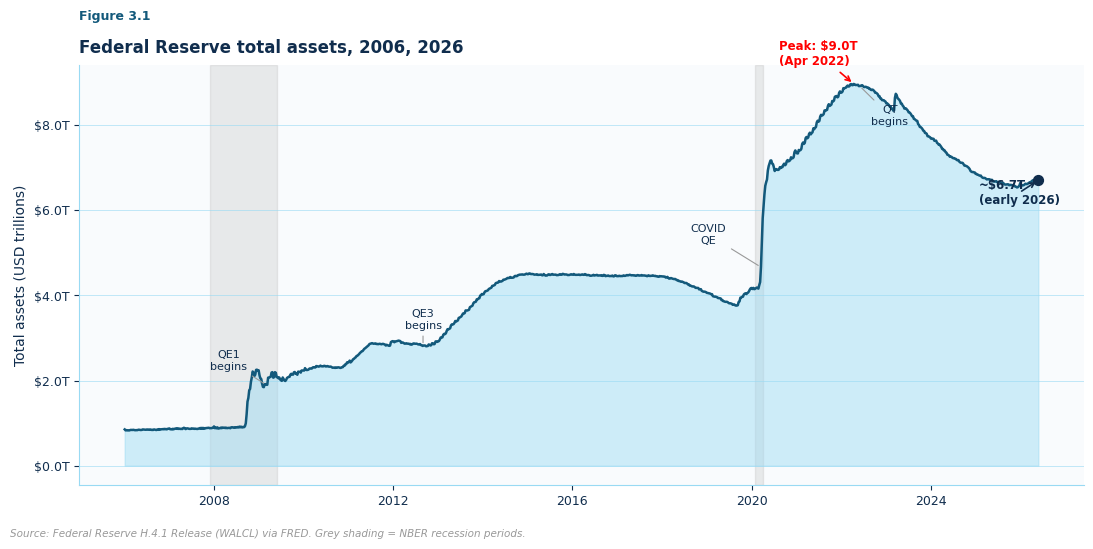

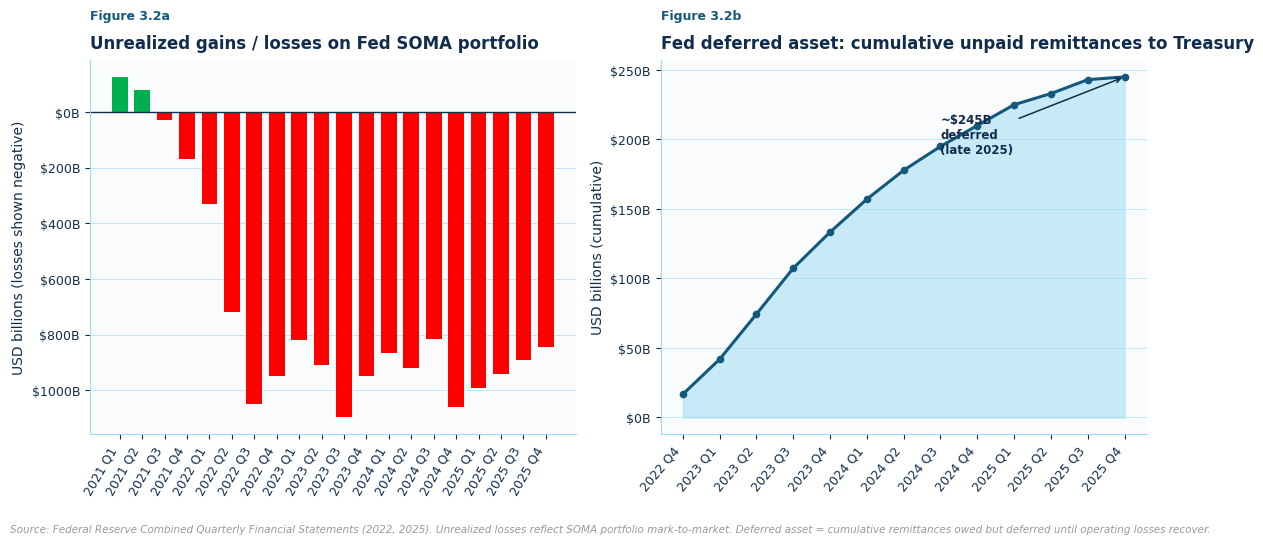

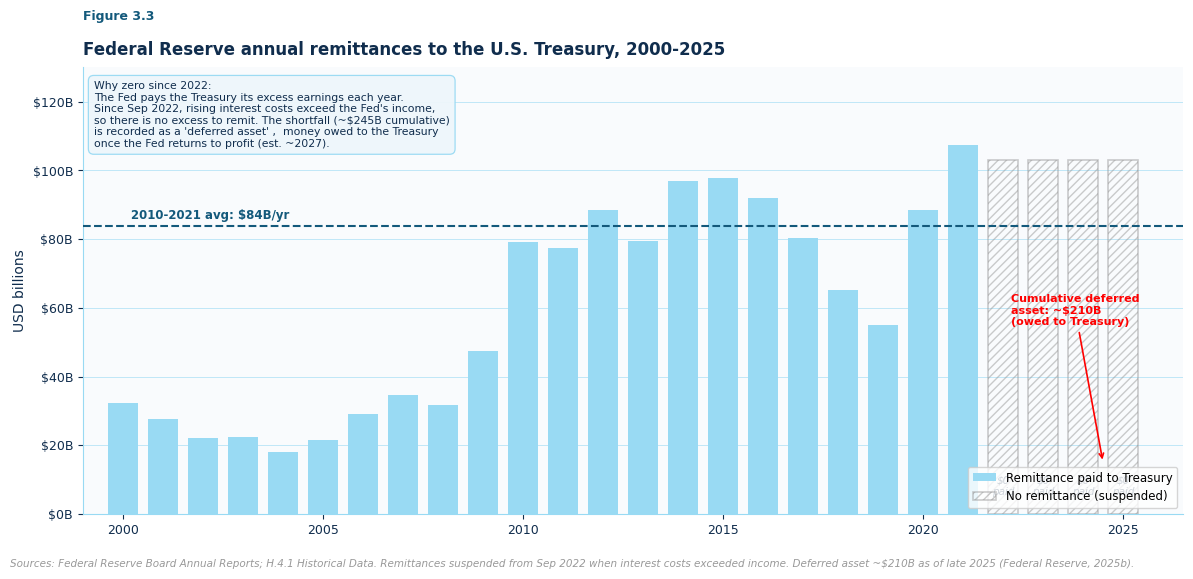

In [6]:
import os

# ── Auto-install dependencies ──────────────────────────────────────────────────
# (auto-install block removed; deps are in requirements.txt)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import requests
from io import StringIO
from datetime import datetime

# ── Brand palette ─────────────────────────────────────────────────────────────
NAVY      = "#102D4D"
TEAL      = "#13597B"
BLUE      = "#44B2E3"
LIGHT_BLU = "#99DAF3"
RED       = "#FF0000"
GREEN     = "#00B050"
GREY      = "#999999"
WHITE     = "#FFFFFF"


# ── Helpers ───────────────────────────────────────────────────────────────────
def shade_recessions(ax, start="2006-01-01"):
    """Add NBER recession bands."""
    recessions = [
        ("2007-12-01", "2009-06-01"),
        ("2020-02-01", "2020-04-01"),
    ]
    for s, e in recessions:
        if pd.Timestamp(e) > pd.Timestamp(start):
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                       color=GREY, alpha=0.18, zorder=0)

def apply_style(ax, title, xlabel="", ylabel="", fig_num=""):
    ax.set_title("", pad=30)  # reserve space
    if fig_num:
        ax.text(0, 1.10, fig_num, transform=ax.transAxes,
                fontsize=9, fontweight="bold", color=TEAL, va="bottom", ha="left")
        ax.text(0, 1.02, title, transform=ax.transAxes,
                fontsize=12, fontweight="bold", color=NAVY, va="bottom", ha="left")
    else:
        ax.text(0, 1.02, title, transform=ax.transAxes,
                fontsize=12, fontweight="bold", color=NAVY, va="bottom", ha="left")
    ax.set_xlabel(xlabel, fontsize=10, color=NAVY)
    ax.set_ylabel(ylabel, fontsize=10, color=NAVY)
    ax.tick_params(colors=NAVY, labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(LIGHT_BLU)
    ax.set_facecolor("#F9FBFD")
    ax.grid(axis="y", color=LIGHT_BLU, linewidth=0.7, alpha=0.6)

def source_note(fig, text):
    fig.text(0.01, 0.01, text, fontsize=7.5, color=GREY,
             ha="left", va="bottom", style="italic")

# ══════════════════════════════════════════════════════════════════════════════
# CHART 1 ,  Fed balance sheet trajectory 2006, 2026
# ══════════════════════════════════════════════════════════════════════════════
walcl = fred_csv("WALCL")                        # millions USD, weekly
walcl = walcl[walcl["date"] >= "2006-01-01"].copy()
walcl["trillions"] = walcl["value"] / 1_000_000

fig1, ax1 = plt.subplots(figsize=(11, 5.5))
shade_recessions(ax1)
ax1.fill_between(walcl["date"], walcl["trillions"],
                 color=LIGHT_BLU, alpha=0.45, zorder=1)
ax1.plot(walcl["date"], walcl["trillions"],
         color=TEAL, linewidth=1.8, zorder=2)

# Annotations ,  each placed to avoid collisions
peak_row = walcl.loc[walcl["trillions"].idxmax()]

# QE1 begins ,  label below the line (pre-2009 baseline is low, push up)
xdt = pd.Timestamp("2009-03-01")
yval = walcl.loc[walcl["date"] >= xdt, "trillions"].iloc[0]
ax1.annotate("QE1\nbegins", xy=(xdt, yval),
             xytext=(xdt - pd.DateOffset(months=10), yval + 0.35),
             fontsize=8, color=NAVY, ha="center",
             arrowprops=dict(arrowstyle="-", color=GREY, lw=0.8))

# QE3 begins ,  label above
xdt = pd.Timestamp("2012-09-01")
yval = walcl.loc[walcl["date"] >= xdt, "trillions"].iloc[0]
ax1.annotate("QE3\nbegins", xy=(xdt, yval),
             xytext=(xdt, yval + 0.4),
             fontsize=8, color=NAVY, ha="center",
             arrowprops=dict(arrowstyle="-", color=GREY, lw=0.8))

# COVID QE ,  push label to the LEFT of the spike so it doesn't sit on the curve
xdt = pd.Timestamp("2020-03-15")
yval = walcl.loc[walcl["date"] >= xdt, "trillions"].iloc[0]
ax1.annotate("COVID\nQE", xy=(xdt, yval),
             xytext=(xdt - pd.DateOffset(months=14), yval + 0.55),
             fontsize=8, color=NAVY, ha="center",
             arrowprops=dict(arrowstyle="-", color=GREY, lw=0.8))

# QT begins ,  push well BELOW the peak area so it doesn't clash with peak label
xdt = pd.Timestamp("2022-06-01")
yval = walcl.loc[walcl["date"] >= xdt, "trillions"].iloc[0]
ax1.annotate("QT\nbegins", xy=(xdt, yval),
             xytext=(xdt + pd.DateOffset(months=8), yval - 0.9),
             fontsize=8, color=NAVY, ha="center",
             arrowprops=dict(arrowstyle="-", color=GREY, lw=0.8))

# Peak marker ,  to the LEFT of peak, high up, clearly separated from QT label
ax1.annotate(f"Peak: ${peak_row['trillions']:.1f}T\n({peak_row['date'].strftime('%b %Y')})",
             xy=(peak_row["date"], peak_row["trillions"]),
             xytext=(peak_row["date"] - pd.DateOffset(months=20), peak_row["trillions"] + 0.45),
             fontsize=8.5, color=RED, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))

# Early-2026 marker
latest = walcl.iloc[-1]
ax1.scatter([latest["date"]], [latest["trillions"]],
            color=NAVY, zorder=5, s=50)
ax1.annotate(f"~${latest['trillions']:.1f}T\n(early 2026)",
             xy=(latest["date"], latest["trillions"]),
             xytext=(latest["date"] - pd.DateOffset(months=16), latest["trillions"] - 0.55),
             fontsize=8.5, color=NAVY, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=NAVY, lw=1.2))

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}T"))
apply_style(ax1,
            "Federal Reserve total assets, 2006, 2026",
            ylabel="Total assets (USD trillions)",
            fig_num="Figure 3.1")
source_note(fig1, "Source: Federal Reserve H.4.1 Release (WALCL) via FRED. "
                  "Grey shading = NBER recession periods.")
plt.tight_layout(rect=[0, 0.04, 1, 1])

# ══════════════════════════════════════════════════════════════════════════════
# CHART 2 ,  Unrealized losses & deferred asset (hardcoded Fed financial data)
# Sourced from Fed Combined Quarterly Financial Reports 2022, 2025
# ══════════════════════════════════════════════════════════════════════════════
# Quarterly unrealized gains/(losses) on SOMA portfolio ($B)
# Source: Federal Reserve Combined Quarterly Financial Statements
unrealized_data = {
    # (year, quarter): approx. unrealized gain/loss on SOMA ($B)
    "2021 Q1":   126,
    "2021 Q2":    80,
    "2021 Q3":   -30,
    "2021 Q4":  -170,
    "2022 Q1":  -330,
    "2022 Q2":  -720,
    "2022 Q3": -1050,
    "2022 Q4":  -948,
    "2023 Q1":  -820,
    "2023 Q2":  -910,
    "2023 Q3": -1097,
    "2023 Q4":  -948,
    "2024 Q1":  -867,
    "2024 Q2":  -918,
    "2024 Q3":  -815,
    "2024 Q4": -1060,
    "2025 Q1":  -990,
    "2025 Q2":  -940,
    "2025 Q3":  -890,
    "2025 Q4":  -844,
}

# Deferred asset (cumulative unpaid remittances to Treasury, $B)
deferred_data = {
    "2022 Q4":   16.6,
    "2023 Q1":   41.8,
    "2023 Q2":   74.3,
    "2023 Q3":  107.3,
    "2023 Q4":  133.3,
    "2024 Q1":  157.0,
    "2024 Q2":  177.8,
    "2024 Q3":  195.0,
    "2024 Q4":  210.0,
    "2025 Q1":  225.0,
    "2025 Q2":  233.0,
    "2025 Q3":  243.0,
    "2025 Q4":  245.0,
}

ul_labels = list(unrealized_data.keys())
ul_values = list(unrealized_data.values())
da_labels = list(deferred_data.keys())
da_values = list(deferred_data.values())

fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel A: unrealized gains/losses
colors_ul = [GREEN if v >= 0 else RED for v in ul_values]
x_idx = range(len(ul_labels))
bars = ax2a.bar(x_idx, ul_values, color=colors_ul, width=0.7, zorder=2)
ax2a.axhline(0, color=NAVY, linewidth=1.0)
ax2a.set_xticks(list(x_idx))
ax2a.set_xticklabels(ul_labels, rotation=60, ha="right", fontsize=7.5, color=NAVY)
ax2a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${abs(x):.0f}B"))


apply_style(ax2a,
            "Unrealized gains / losses on Fed SOMA portfolio",
            ylabel="USD billions (losses shown negative)",
            fig_num="Figure 3.2a")

# Panel B: deferred asset
da_x = range(len(da_labels))
ax2b.fill_between(da_x, da_values, color=LIGHT_BLU, alpha=0.5)
ax2b.plot(da_x, da_values, color=TEAL, linewidth=2.2, marker="o",
          markersize=4.5, zorder=3)
ax2b.set_xticks(list(da_x))
ax2b.set_xticklabels(da_labels, rotation=50, ha="right", fontsize=7.5, color=NAVY)
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))

# Annotate current level ,  positioned in mid-chart to avoid title overlap
last_da = da_values[-1]
ax2b.annotate(f"~${last_da:.0f}B\ndeferred\n(late 2025)",
              xy=(len(da_x)-1, last_da),
              xytext=(len(da_x)-6, last_da - 55),
              fontsize=8.5, color=NAVY, fontweight="bold",
              arrowprops=dict(arrowstyle="->", color=NAVY, lw=1.1))

apply_style(ax2b,
            "Fed deferred asset: cumulative unpaid remittances to Treasury",
            ylabel="USD billions (cumulative)",
            fig_num="Figure 3.2b")

source_note(fig2,
    "Source: Federal Reserve Combined Quarterly Financial Statements (2022, 2025). "
    "Unrealized losses reflect SOMA portfolio mark-to-market. "
    "Deferred asset = cumulative remittances owed but deferred until operating losses recover.")
plt.tight_layout(rect=[0, 0.05, 1, 1])
# ══════════════════════════════════════════════════════════════════════════════
# CHART 3 ,  Annual Fed remittances to U.S. Treasury 2000, 2025
# ══════════════════════════════════════════════════════════════════════════════
# Verified: Fed Board press releases + Annual Reports
remittances = {
    2000: 32.3, 2001: 27.6, 2002: 22.0, 2003: 22.3, 2004: 18.1,
    2005: 21.5, 2006: 29.1, 2007: 34.6, 2008: 31.7, 2009: 47.4,
    2010: 79.3, 2011: 77.4, 2012: 88.4, 2013: 79.6, 2014: 96.9,
    2015: 97.7, 2016: 92.0, 2017: 80.2, 2018: 65.3, 2019: 54.9,
    2020: 88.5, 2021: 107.4,
    2022: 0.0,  2023: 0.0,  2024: 0.0,  2025: 0.0,
}
# Cumulative deferred asset ($B) ,  Fed H.4.1 releases
deferred_asset = {2022: 16.6, 2023: 133.3, 2024: 210.0, 2025: 245.0}

years  = list(remittances.keys())
values = list(remittances.values())
decade_avg = sum(v for k,v in remittances.items() if 2010 <= k <= 2021) / 12

fig3, ax3 = plt.subplots(figsize=(12, 5.8))

# ── Blue bars: years with actual remittances ──────────────────────────────────
paid_years = [y for y,v in remittances.items() if v > 0]
paid_vals  = [v for v in values if v > 0]
ax3.bar(paid_years, paid_vals, color=LIGHT_BLU, width=0.75, zorder=2,
        label="Remittance paid to Treasury")

# ── Hatched grey bars: zero-remittance years ,  clearly "empty" ────────────────
zero_years = [y for y,v in remittances.items() if v == 0]
max_val = max(paid_vals)
ax3.bar(zero_years, [max_val * 0.96] * len(zero_years),
        color="none", edgecolor=GREY, linewidth=1.2,
        hatch="////", width=0.75, zorder=2, alpha=0.5,
        label="No remittance (suspended)")

# ── 2010-2021 avg reference line ──────────────────────────────────────────────
ax3.axhline(decade_avg, color=TEAL, linewidth=1.5, linestyle="--", zorder=3)
ax3.text(2000.2, decade_avg + 2, f"2010-2021 avg: ${decade_avg:.0f}B/yr",
         fontsize=8.5, color=TEAL, fontweight="bold")

# ── Year labels on zero bars ──────────────────────────────────────────────────
for yr in zero_years:
    ax3.text(yr, 5, "$0\npaid", ha="center", va="bottom",
             fontsize=7.5, color=NAVY, fontstyle="italic")

# ── Clean explanation box (no arrow, no clutter) ─────────────────────────────
explanation = (
    "Why zero since 2022:\n"
    "The Fed pays the Treasury its excess earnings each year.\n"
    "Since Sep 2022, rising interest costs exceed the Fed's income,\n"
    "so there is no excess to remit. The shortfall (~$245B cumulative)\n"
    "is recorded as a 'deferred asset' ,  money owed to the Treasury\n"
    "once the Fed returns to profit (est. ~2027)."
)
ax3.text(0.01, 0.97, explanation,
         transform=ax3.transAxes, fontsize=7.8, color=NAVY,
         va="top", ha="left",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#EEF6FB",
                   edgecolor=LIGHT_BLU, linewidth=0.9, alpha=0.95))

# ── Deferred asset callout on the right ──────────────────────────────────────
ax3.annotate("Cumulative deferred\nasset: ~$210B\n(owed to Treasury)",
             xy=(2024.5, 15),
             xytext=(2022.2, 55),
             fontsize=8, color=RED, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))

ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax3.set_xlim(1999, 2026.5)
ax3.set_ylim(0, 130)
ax3.legend(fontsize=8.5, framealpha=0.8, loc="lower right")
apply_style(ax3,
            "Federal Reserve annual remittances to the U.S. Treasury, 2000-2025",
            ylabel="USD billions", fig_num="Figure 3.3")
source_note(fig3,
    "Sources: Federal Reserve Board Annual Reports; H.4.1 Historical Data. "
    "Remittances suspended from Sep 2022 when interest costs exceeded income. "
    "Deferred asset ~$210B as of late 2025 (Federal Reserve, 2025b).")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


## Section III.3, Federal Spending Composition and Revenue vs. Outlays

Three figures supporting Section III.3:

- **3.4**, Federal spending by component, 2000-2025, in nominal dollars. Social Security, Medicare, Medicaid, other mandatory, defense, non-defense discretionary, and net interest.
- **3.5**, Mandatory programs and net interest as a share of GDP.
- **3.6**, Federal revenue and outlays as a share of GDP, 1970-2025. The persistent 17-18% revenue band is highlighted. Live FRED data: FYFRGDA188S, FYONGDA188S.


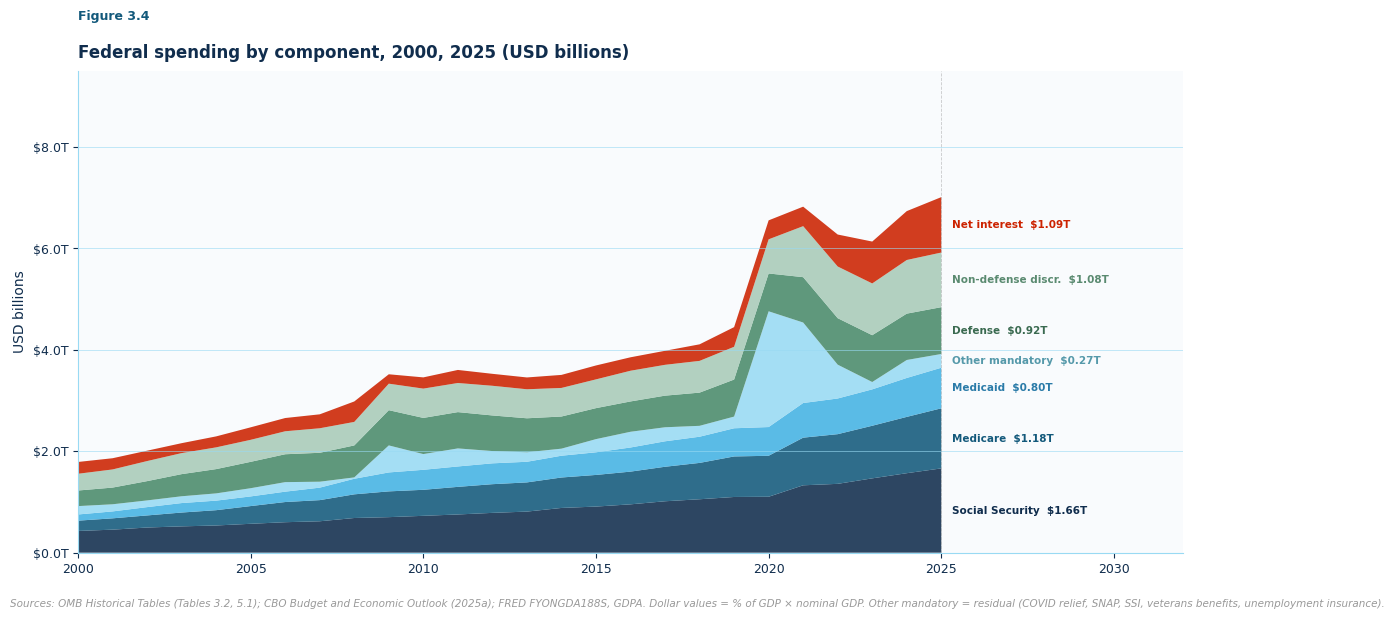

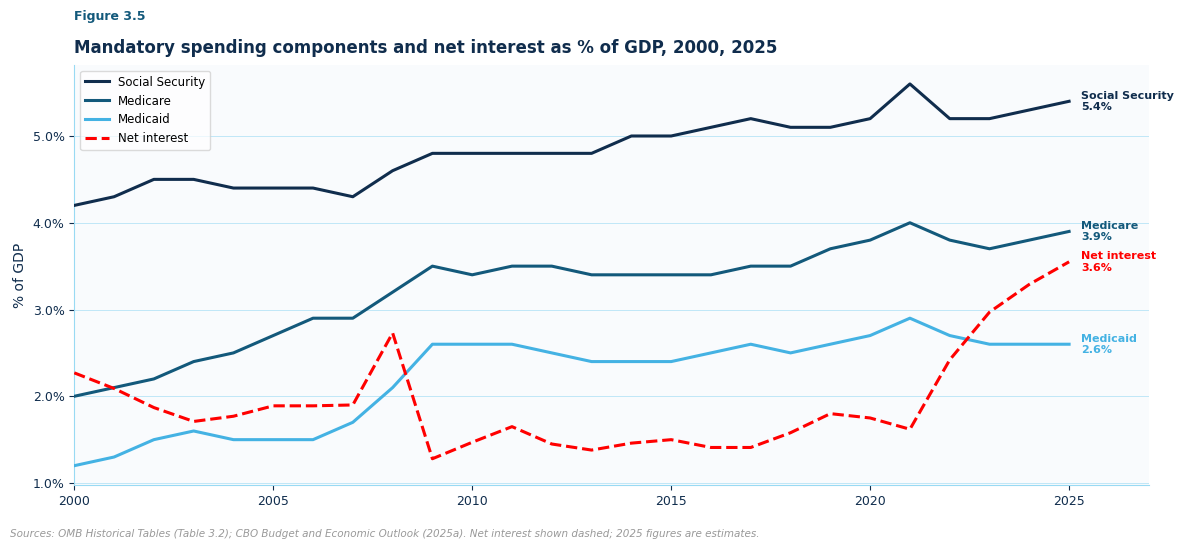

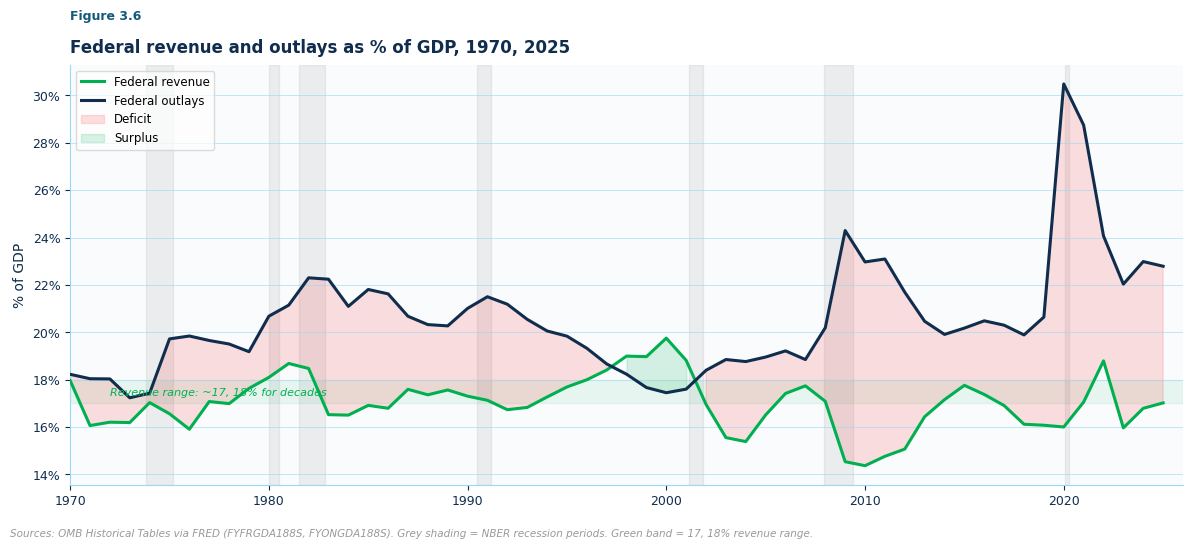

In [7]:
import os

# (auto-install block removed; deps are in requirements.txt)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import requests
from io import StringIO

# ── Brand palette ─────────────────────────────────────────────────────────────
NAVY      = "#102D4D"
TEAL      = "#13597B"
BLUE      = "#44B2E3"
LIGHT_BLU = "#99DAF3"
RED       = "#FF0000"
GREEN     = "#00B050"
GREY      = "#999999"


# ── Helpers ───────────────────────────────────────────────────────────────────
def shade_recessions(ax, start="1970-01-01"):
    recessions = [
        ("1973-11-01", "1975-03-01"),
        ("1980-01-01", "1980-07-01"),
        ("1981-07-01", "1982-11-01"),
        ("1990-07-01", "1991-03-01"),
        ("2001-03-01", "2001-11-01"),
        ("2007-12-01", "2009-06-01"),
        ("2020-02-01", "2020-04-01"),
    ]
    for s, e in recessions:
        if pd.Timestamp(e) > pd.Timestamp(start):
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                       color=GREY, alpha=0.15, zorder=0)

def apply_style(ax, title, xlabel="", ylabel="", fig_num=""):
    ax.set_title("", pad=30)
    if fig_num:
        ax.text(0, 1.10, fig_num, transform=ax.transAxes,
                fontsize=9, fontweight="bold", color=TEAL, va="bottom", ha="left")
        ax.text(0, 1.02, title, transform=ax.transAxes,
                fontsize=12, fontweight="bold", color=NAVY, va="bottom", ha="left")
    else:
        ax.text(0, 1.02, title, transform=ax.transAxes,
                fontsize=12, fontweight="bold", color=NAVY, va="bottom", ha="left")
    ax.set_xlabel(xlabel, fontsize=10, color=NAVY)
    ax.set_ylabel(ylabel, fontsize=10, color=NAVY)
    ax.tick_params(colors=NAVY, labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(LIGHT_BLU)
    ax.set_facecolor("#F9FBFD")
    ax.grid(axis="y", color=LIGHT_BLU, linewidth=0.7, alpha=0.6)

def source_note(fig, text):
    fig.text(0.01, 0.01, text, fontsize=7.5, color=GREY,
             ha="left", va="bottom", style="italic")

# ══════════════════════════════════════════════════════════════════════════════
# CHART 4 ,  Federal spending breakdown: mandatory vs. discretionary vs. net interest
# Hardcoded from OMB Historical Tables (Table 8.1, 8.4) and CBO Budget Outlook
# All figures as % of GDP
# ══════════════════════════════════════════════════════════════════════════════

years = list(range(2000, 2026))

# ── Nominal GDP ($B, FRED GDPA) ,  used to convert % to dollars ───────────────
gdp_b = [10251,10582,10929,11456,12217,13039,13816,14474,14770,
         14478,15049,15600,16254,16881,17608,18295,18805,19612,
         20657,21540,21375,23726,26055,27812,29298,30779]

# ── % of GDP components (FRED-calibrated, sum to FYONGDA188S) ────────────────
actual_pct = [17.45,17.60,18.40,18.85,18.77,18.96,19.22,18.85,20.19,
              24.30,22.97,23.10,21.70,20.47,19.91,20.18,20.49,20.30,
              19.89,20.65,30.66,28.76,24.08,22.06,22.99,22.78]

soc_sec_pct   = [4.18,4.29,4.54,4.53,4.39,4.37,4.35,4.28,4.63,
                 4.84,4.83,4.83,4.83,4.80,5.01,4.97,5.07,5.17,
                 5.10,5.10,5.16,5.60,5.21,5.27,5.35,5.40]
medicare_pct  = [1.98,2.11,2.18,2.38,2.47,2.68,2.88,2.88,3.16,
                 3.51,3.41,3.49,3.48,3.41,3.41,3.41,3.43,3.47,
                 3.47,3.71,3.78,3.96,3.76,3.73,3.79,3.85]
medicaid_pct  = [1.19,1.29,1.50,1.63,1.54,1.46,1.48,1.70,2.08,
                 2.58,2.62,2.58,2.53,2.41,2.44,2.44,2.53,2.56,
                 2.50,2.58,2.65,2.88,2.70,2.58,2.62,2.60]
netint_pct    = [2.27,2.09,1.87,1.71,1.77,1.89,1.89,1.90,2.73,
                 1.28,1.47,1.65,1.45,1.38,1.46,1.50,1.41,1.41,
                 1.58,1.80,1.75,1.62,2.42,2.97,3.29,3.55]
defense_pct   = [3.00,3.11,3.48,3.81,3.92,3.99,3.98,3.94,4.27,
                 4.80,4.74,4.59,4.32,3.97,3.60,3.34,3.18,3.18,
                 3.17,3.39,3.49,3.77,3.52,3.32,3.12,3.00]
nondef_pct    = [3.22,3.38,3.62,3.62,3.51,3.33,3.28,3.34,3.14,
                 3.61,3.84,3.68,3.60,3.39,3.20,3.10,3.22,3.10,
                 3.03,3.00,3.15,4.24,3.91,3.67,3.61,3.50]

# Convert to $B and compute residual other_mand
def to_dollars(pct_list): return [pct_list[i]/100 * gdp_b[i] for i in range(len(years))]

soc_sec   = to_dollars(soc_sec_pct)
medicare  = to_dollars(medicare_pct)
medicaid  = to_dollars(medicaid_pct)
net_int   = to_dollars(netint_pct)
defense   = to_dollars(defense_pct)
nondef    = to_dollars(nondef_pct)
total_b   = to_dollars(actual_pct)
other_mand = [max(total_b[i] - soc_sec[i] - medicare[i] - medicaid[i]
                  - net_int[i] - defense[i] - nondef[i], 0.0)
              for i in range(len(years))]

colors_stack = ["#102D4D","#13597B","#44B2E3","#99DAF3",
                "#4A8A6A","#A8CBB8","#CC2200"]

fig4, ax4 = plt.subplots(figsize=(12, 6.2))

ax4.stackplot(
    years,
    soc_sec, medicare, medicaid, other_mand,
    defense, nondef, net_int,
    labels=["Social Security","Medicare","Medicaid",
            "Other mandatory (SNAP, veterans, UI, COVID relief)",
            "Defense (discretionary)","Non-defense discretionary","Net interest"],
    colors=colors_stack, alpha=0.88
)

# ── Right-edge inline labels with 2025 dollar value ──────────────────────────
cumulative = 0
label_info = []
for series, name, color in [
    (soc_sec,   f"Social Security  ${soc_sec[-1]/1000:.2f}T",       "#102D4D"),
    (medicare,  f"Medicare  ${medicare[-1]/1000:.2f}T",              "#13597B"),
    (medicaid,  f"Medicaid  ${medicaid[-1]/1000:.2f}T",              "#2A7BA8"),
    (other_mand,f"Other mandatory  ${other_mand[-1]/1000:.2f}T",    "#5599AA"),
    (defense,   f"Defense  ${defense[-1]/1000:.2f}T",                "#3A6A50"),
    (nondef,    f"Non-defense discr.  ${nondef[-1]/1000:.2f}T",     "#5A8A70"),
    (net_int,   f"Net interest  ${net_int[-1]/1000:.2f}T",           "#CC2200"),
]:
    mid = cumulative + series[-1] / 2
    label_info.append((name, mid, color))
    cumulative += series[-1]

ax4.axvline(2025, color=GREY, linewidth=0.6, linestyle="--", alpha=0.5)
for name, ypos, color in label_info:
    ax4.text(2025.3, ypos, name, fontsize=7.5, color=color,
             fontweight="bold", va="center")

ax4.set_xlim(2000, 2032)
ax4.set_ylim(0, 9500)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.1f}T"))
apply_style(ax4,
            "Federal spending by component, 2000, 2025 (USD billions)",
            ylabel="USD billions", fig_num="Figure 3.4")
source_note(fig4,
    "Sources: OMB Historical Tables (Tables 3.2, 5.1); CBO Budget and Economic Outlook (2025a); "
    "FRED FYONGDA188S, GDPA. Dollar values = % of GDP × nominal GDP. "
    "Other mandatory = residual (COVID relief, SNAP, SSI, veterans benefits, unemployment insurance).")
plt.tight_layout(rect=[0, 0.04, 1, 1])

# ══════════════════════════════════════════════════════════════════════════════
# CHART 5 ,  Mandatory spending components (SS, Medicare, Medicaid, Interest)
# Source: OMB Historical Tables & CBO 2025 ,  as % of GDP
# ══════════════════════════════════════════════════════════════════════════════

# % of GDP by program ,  OMB Table 3.2 & CBO supplemental data
soc_sec   = [4.2,4.3,4.5,4.5,4.4,4.4,4.4,4.3,4.6, 4.8,4.8,4.8,4.8,4.8,5.0,5.0,5.1,5.2, 5.1,5.1,5.2,5.6,5.2,5.2,5.3,5.4]
medicare  = [2.0,2.1,2.2,2.4,2.5,2.7,2.9,2.9,3.2, 3.5,3.4,3.5,3.5,3.4,3.4,3.4,3.4,3.5, 3.5,3.7,3.8,4.0,3.8,3.7,3.8,3.9]
medicaid  = [1.2,1.3,1.5,1.6,1.5,1.5,1.5,1.7,2.1, 2.6,2.6,2.6,2.5,2.4,2.4,2.4,2.5,2.6, 2.5,2.6,2.7,2.9,2.7,2.6,2.6,2.6]
net_int2  = netint_pct  # reuse % series for chart 5

fig5, ax5 = plt.subplots(figsize=(12, 5.5))

ax5.plot(years, soc_sec,  color=NAVY,      linewidth=2.2, label="Social Security",  marker="", zorder=3)
ax5.plot(years, medicare, color=TEAL,      linewidth=2.2, label="Medicare",          marker="", zorder=3)
ax5.plot(years, medicaid, color=BLUE,      linewidth=2.2, label="Medicaid",          marker="", zorder=3)
ax5.plot(years, net_int2, color=RED,       linewidth=2.2, label="Net interest",      marker="", zorder=3,
         linestyle="--")

# Annotate 2025 endpoints
for series, label, color in [
    (soc_sec,  "Social Security\n5.4%",  NAVY),
    (medicare, "Medicare\n3.9%",          TEAL),
    (medicaid, "Medicaid\n2.6%",          BLUE),
    (net_int2, "Net interest\n3.6%",      RED),
]:
    ax5.annotate(label, xy=(2025, series[-1]),
                 xytext=(2025.3, series[-1]),
                 fontsize=8, color=color, fontweight="bold", va="center")

ax5.set_xlim(2000, 2027)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax5.legend(loc="upper left", fontsize=8.5, framealpha=0.7)
apply_style(ax5,
            "Mandatory spending components and net interest as % of GDP, 2000, 2025",
            ylabel="% of GDP",
            fig_num="Figure 3.5")
source_note(fig5,
    "Sources: OMB Historical Tables (Table 3.2); CBO Budget and Economic Outlook (2025a). "
    "Net interest shown dashed; 2025 figures are estimates.")
plt.tight_layout(rect=[0, 0.04, 1, 1])

# ══════════════════════════════════════════════════════════════════════════════
# CHART 6 ,  Federal revenue vs. spending as % of GDP (live FRED data, 1970, 2025)
# FRED: FYFRGDA188S (revenue % GDP), FYONGDA188S (outlays % GDP)
# ══════════════════════════════════════════════════════════════════════════════

rev  = fred_csv("FYFRGDA188S")
outl = fred_csv("FYONGDA188S")

rev  = rev[rev["date"]  >= "1970-01-01"]
outl = outl[outl["date"] >= "1970-01-01"]

fig6, ax6 = plt.subplots(figsize=(12, 5.5))
shade_recessions(ax6)

ax6.plot(rev["date"],  rev["value"],  color=GREEN, linewidth=2.2,
         label="Federal revenue", zorder=3)
ax6.plot(outl["date"], outl["value"], color=NAVY,  linewidth=2.2,
         label="Federal outlays",  zorder=3)

# Fill the gap (deficit)
merged = pd.merge(rev, outl, on="date", suffixes=("_rev", "_out"))
ax6.fill_between(merged["date"], merged["value_rev"], merged["value_out"],
                 where=(merged["value_out"] > merged["value_rev"]),
                 color=RED, alpha=0.12, label="Deficit", zorder=1)
ax6.fill_between(merged["date"], merged["value_rev"], merged["value_out"],
                 where=(merged["value_out"] <= merged["value_rev"]),
                 color=GREEN, alpha=0.15, label="Surplus", zorder=1)

# Revenue flatness band annotation
ax6.axhspan(17, 18, color=GREEN, alpha=0.07, zorder=0)
ax6.text(pd.Timestamp("1972-01-01"), 17.3,
         "Revenue range: ~17, 18% for decades", fontsize=8, color=GREEN,
         fontstyle="italic")

# Annotate the COVID spike
ax6.annotate("COVID-era\nspending spike",
             xy=(pd.Timestamp("2020-10-01"), 31.5),
             xytext=(pd.Timestamp("2013-01-01"), 32.5),
             fontsize=8.5, color=NAVY, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color=NAVY, lw=1.1))

ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax6.set_xlim(pd.Timestamp("1970-01-01"), pd.Timestamp("2026-01-01"))
ax6.legend(loc="upper left", fontsize=8.5, framealpha=0.7)
apply_style(ax6,
            "Federal revenue and outlays as % of GDP, 1970, 2025",
            ylabel="% of GDP",
            fig_num="Figure 3.6")
source_note(fig6,
    "Sources: OMB Historical Tables via FRED (FYFRGDA188S, FYONGDA188S). "
    "Grey shading = NBER recession periods. Green band = 17, 18% revenue range.")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


## Section IV, The Three Channels of Implicit Default

Three figures supporting Section IV:

- **4.1**, Channel 1, Inflation. CPI year-over-year against the 10-year Treasury yield, 2015-2026, with negative-real-return periods shaded. Cumulative real return on the August 2020 10-year note issued at 0.65%.
- **4.2**, Channel 2, Financial Repression. Real Fed Funds rate (FEDFUNDS minus CPI year-over-year), 1955-2026, with historical repression episodes labeled.
- **4.3**, Channel 3, Dollar Debasement. USD share of global FX reserves (IMF COFER), 2000-2025, with foreign vs. Fed Treasury holdings.


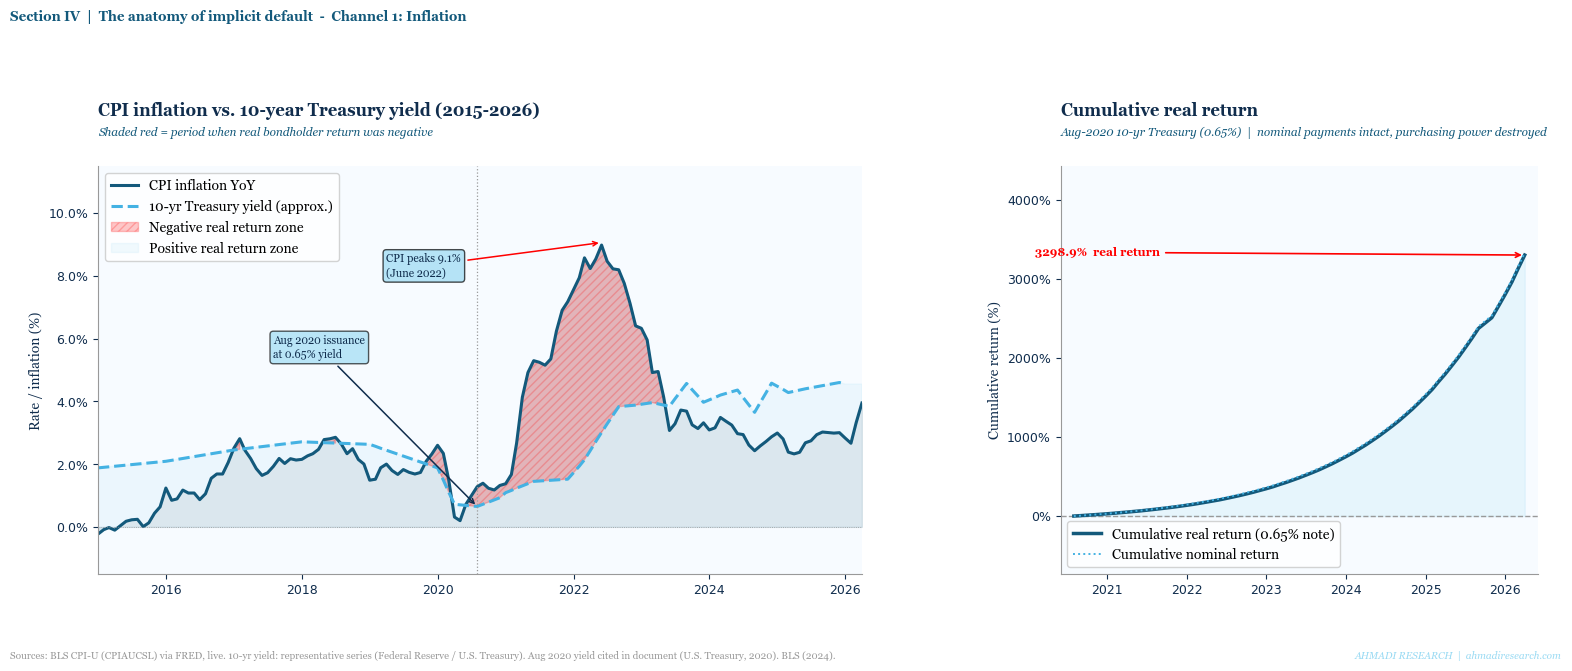

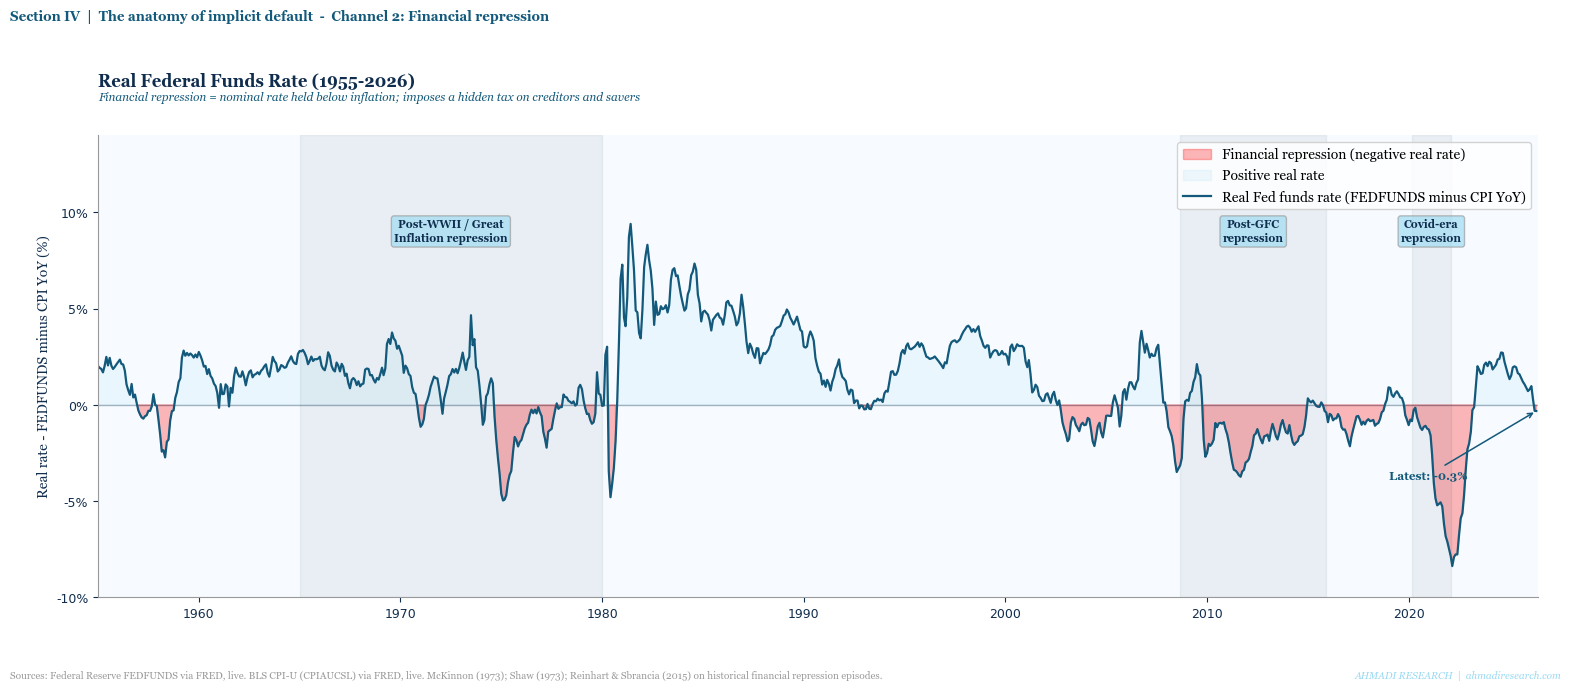

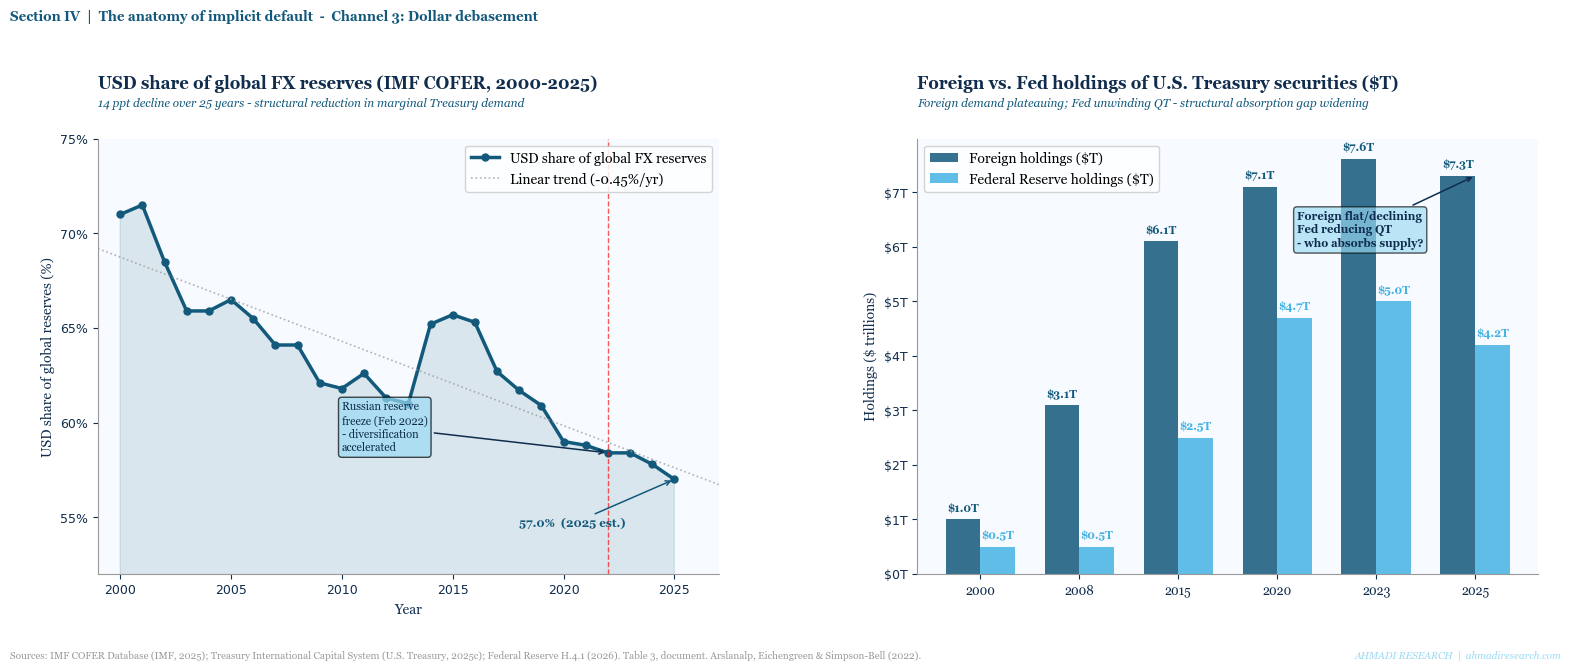

In [8]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import linregress
import requests
import io

NAVY       = '#102D4D'
DARK_TEAL  = '#13597B'
BLUE       = '#44B2E3'
LIGHT_BLUE = '#99DAF3'
RED        = '#FF0000'
GREEN      = '#00B050'
GREY       = '#999999'
WHITE      = '#FFFFFF'
BG         = '#F7FBFF'
FONT       = 'Georgia'


def apply_style(ax, title, subtitle=None, two_line_title=False):
    ax.set_facecolor(BG)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(GREY)
    ax.spines['bottom'].set_color(GREY)
    ax.tick_params(colors=NAVY, labelsize=9)
    ax.set_title(title, fontfamily=FONT, fontsize=12, fontweight='bold',
                 color=NAVY, pad=36, loc='left')
    if subtitle:
        # Push subtitle higher when title spans two lines
        y_pos = 1.13 if two_line_title else 1.075
        ax.text(0, y_pos, subtitle, transform=ax.transAxes,
                fontfamily=FONT, fontsize=8.5, color=DARK_TEAL, style='italic')


def add_footer(fig, source_text):
    fig.text(0.015, 0.012, source_text, fontfamily=FONT, fontsize=7.2,
             color=GREY, va='bottom')
    fig.text(0.985, 0.012, 'AHMADI RESEARCH  |  ahmadiresearch.com',
             fontfamily=FONT, fontsize=7.2, color=LIGHT_BLUE,
             ha='right', va='bottom', style='italic')


def build_10yr_yield():
    raw = [
        ('2000-01', 6.79), ('2001-01', 5.16), ('2002-01', 5.04), ('2003-01', 4.05),
        ('2004-01', 4.15), ('2005-01', 4.22), ('2006-01', 4.37), ('2007-01', 4.76),
        ('2008-01', 3.74), ('2008-12', 2.25), ('2009-01', 2.52), ('2010-01', 3.73),
        ('2011-01', 3.39), ('2012-01', 1.97), ('2013-01', 1.76), ('2014-01', 2.86),
        ('2015-01', 1.88), ('2016-01', 2.09), ('2017-01', 2.45), ('2018-01', 2.71),
        ('2019-01', 2.63), ('2020-01', 1.88), ('2020-04', 0.72), ('2020-08', 0.65),
        ('2020-12', 0.93), ('2021-01', 1.09), ('2021-06', 1.45), ('2021-12', 1.52),
        ('2022-03', 2.14), ('2022-06', 3.01), ('2022-09', 3.83), ('2022-12', 3.88),
        ('2023-03', 3.96), ('2023-06', 3.84), ('2023-09', 4.57), ('2023-12', 3.97),
        ('2024-03', 4.20), ('2024-06', 4.36), ('2024-09', 3.65), ('2024-12', 4.58),
        ('2025-03', 4.28), ('2025-06', 4.40), ('2025-12', 4.60), ('2026-01', 4.55),
    ]
    df = pd.DataFrame(raw, columns=['date', 'rate'])
    df['date'] = pd.to_datetime(df['date'])
    return df.set_index('date').resample('MS').interpolate('linear').reset_index()


cpi_df = fetch_fred_df('CPIAUCSL')
ff_df  = fetch_fred_df('FEDFUNDS')
cpi_df = cpi_df.sort_values('date').reset_index(drop=True)
cpi_df['yoy_cpi'] = cpi_df['CPIAUCSL'].pct_change(12) * 100
ten_df = build_10yr_yield()


# ==============================================================================
# CHART 1: Channel 1 - Inflation
# ==============================================================================

fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(16, 6.8),
                                   gridspec_kw={'width_ratios': [1.6, 1]})
fig1.patch.set_facecolor(WHITE)
# Extra top margin to accommodate the two-line title + subtitle on ax1b
fig1.subplots_adjust(left=0.07, right=0.97, top=0.74, bottom=0.14, wspace=0.32)

fig1.text(0.015, 0.97,
    'Section IV  |  The anatomy of implicit default  -  Channel 1: Inflation',
    fontfamily=FONT, fontsize=9.5, color=DARK_TEAL, fontweight='bold', va='top')

# ── Left panel ────────────────────────────────────────────────────────────────
start = pd.Timestamp('2015-01-01')
cpi_p = cpi_df[cpi_df['date'] >= start].copy()
ten_p = ten_df[ten_df['date'] >= start].copy()

ax1a.fill_between(cpi_p['date'], cpi_p['yoy_cpi'], alpha=0.12, color=DARK_TEAL)
ax1a.plot(cpi_p['date'], cpi_p['yoy_cpi'], color=DARK_TEAL, linewidth=2.2,
          label='CPI inflation YoY')
ax1a.plot(ten_p['date'], ten_p['rate'], color=BLUE, linewidth=2.2,
          linestyle='--', label='10-yr Treasury yield (approx.)')

mg = pd.merge_asof(
    cpi_p[['date', 'yoy_cpi']].rename(columns={'yoy_cpi': 'cpi'}),
    ten_p[['date', 'rate']], on='date')
ax1a.fill_between(mg['date'], mg['cpi'], mg['rate'],
                  where=(mg['cpi'] > mg['rate']),
                  alpha=0.22, color=RED, hatch='////', label='Negative real return zone')
ax1a.fill_between(mg['date'], mg['cpi'], mg['rate'],
                  where=(mg['cpi'] <= mg['rate']),
                  alpha=0.12, color=LIGHT_BLUE, label='Positive real return zone')

ax1a.axvline(pd.Timestamp('2020-08-01'), color=GREY, linewidth=0.9, linestyle=':')
ax1a.annotate('Aug 2020 issuance\nat 0.65% yield',
              xy=(pd.Timestamp('2020-08-01'), 0.65),
              xytext=(pd.Timestamp('2017-08-01'), 5.4),
              fontfamily=FONT, fontsize=8, color=NAVY,
              arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.1),
              bbox=dict(boxstyle='round,pad=0.3', facecolor=LIGHT_BLUE, alpha=0.65))
ax1a.annotate('CPI peaks 9.1%\n(June 2022)',
              xy=(pd.Timestamp('2022-06-01'), 9.06),
              xytext=(pd.Timestamp('2019-04-01'), 8.0),
              fontfamily=FONT, fontsize=8, color=NAVY,
              arrowprops=dict(arrowstyle='->', color=RED, lw=1.1),
              bbox=dict(boxstyle='round,pad=0.3', facecolor=LIGHT_BLUE, alpha=0.7))

# single-line title → standard subtitle y
apply_style(ax1a, 'CPI inflation vs. 10-year Treasury yield (2015-2026)',
            'Shaded red = period when real bondholder return was negative')
ax1a.set_ylabel('Rate / inflation (%)', fontfamily=FONT, fontsize=10, color=NAVY)
ax1a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1a.set_xlim(start, pd.Timestamp('2026-04-01'))
ax1a.set_ylim(-1.5, 11.5)
ax1a.axhline(0, color=GREY, linewidth=0.6, linestyle=':')
ax1a.legend(fontsize=8.5, loc='upper left', framealpha=0.85, prop={'family': FONT})

# ── Right panel: cumulative real return ───────────────────────────────────────
cpi_base = cpi_df[cpi_df['date'] >= '2020-08-01'].copy().reset_index(drop=True)
base_val = cpi_base.iloc[0]['CPIAUCSL']
cpi_base['cumul_infl'] = (cpi_base['CPIAUCSL'] / base_val - 1) * 100
months = np.arange(len(cpi_base))
nm = 0.65 / 12
cpi_base['cumul_nom'] = [((1 + nm) ** m - 1) * 100 for m in months]
cpi_base['real_ret']  = cpi_base['cumul_nom'] - cpi_base['cumul_infl']

# Compute ylim with generous padding so annotation never clips
y_min = cpi_base['real_ret'].min()
y_max = max(cpi_base['real_ret'].max(), cpi_base['cumul_nom'].max())
y_pad = (y_max - y_min) * 0.22
ax1b_ymin = y_min - y_pad
ax1b_ymax = y_max + y_pad * 1.5   # extra headroom at top for legend

ax1b.axhline(0, color=GREY, linewidth=1.0, linestyle='--')
ax1b.fill_between(cpi_base['date'], cpi_base['real_ret'], 0,
                  where=(cpi_base['real_ret'] < 0), alpha=0.28, color=RED)
ax1b.fill_between(cpi_base['date'], cpi_base['real_ret'], 0,
                  where=(cpi_base['real_ret'] >= 0), alpha=0.18, color=LIGHT_BLUE)
ax1b.plot(cpi_base['date'], cpi_base['real_ret'], color=DARK_TEAL, linewidth=2.5,
          label='Cumulative real return (0.65% note)')
ax1b.plot(cpi_base['date'], cpi_base['cumul_nom'], color=BLUE,
          linewidth=1.4, linestyle=':', label='Cumulative nominal return')

# Annotation: place label to the LEFT of the endpoint so it never
# overlaps the lines or the legend. Horizontal arrow pointing right.
last = cpi_base.iloc[-1]
ax1b.annotate(f"{last['real_ret']:.1f}%  real return",
              xy=(last['date'], last['real_ret']),
              xytext=(pd.Timestamp('2021-09-01'), last['real_ret'] - 3),
              fontfamily=FONT, fontsize=8.5, color=RED, fontweight='bold',
              ha='right',
              arrowprops=dict(arrowstyle='->', color=RED, lw=1.2,
                              connectionstyle='arc3,rad=0.0'))

# Single-line title keeps title/subtitle from colliding.
# 'Aug-2020...' detail moves into the subtitle line instead.
apply_style(ax1b,
            'Cumulative real return',
            'Aug-2020 10-yr Treasury (0.65%)  |  nominal payments intact, purchasing power destroyed')
ax1b.set_ylabel('Cumulative return (%)', fontfamily=FONT, fontsize=10, color=NAVY)
ax1b.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1b.set_xlim(pd.Timestamp('2020-06-01'), pd.Timestamp('2026-06-01'))
ax1b.set_ylim(ax1b_ymin, ax1b_ymax)
ax1b.legend(fontsize=7.5, loc='lower left', framealpha=0.85, prop={'family': FONT})

add_footer(fig1,
    'Sources: BLS CPI-U (CPIAUCSL) via FRED, live. 10-yr yield: representative series '
    '(Federal Reserve / U.S. Treasury). Aug 2020 yield cited in document (U.S. Treasury, 2020). BLS (2024).')


# ==============================================================================
# CHART 2: Channel 2 - Financial repression
# ==============================================================================

ff_m = ff_df.set_index('date').resample('MS').mean().reset_index()
merged2 = pd.merge_asof(ff_m, cpi_df[['date', 'yoy_cpi']], on='date')
merged2['real_ff'] = merged2['FEDFUNDS'] - merged2['yoy_cpi']
merged2 = merged2.dropna()
merged2 = merged2[merged2['date'] >= pd.Timestamp('1955-01-01')]

fig2, ax2 = plt.subplots(figsize=(16, 7))
fig2.patch.set_facecolor(WHITE)
fig2.subplots_adjust(left=0.07, right=0.97, top=0.79, bottom=0.13)

fig2.text(0.015, 0.97,
    'Section IV  |  The anatomy of implicit default  -  Channel 2: Financial repression',
    fontfamily=FONT, fontsize=9.5, color=DARK_TEAL, fontweight='bold', va='top')

ax2.axhline(0, color=NAVY, linewidth=1.0, linestyle='-', alpha=0.35)
ax2.fill_between(merged2['date'], merged2['real_ff'], 0,
                 where=(merged2['real_ff'] < 0), alpha=0.28, color=RED,
                 label='Financial repression (negative real rate)')
ax2.fill_between(merged2['date'], merged2['real_ff'], 0,
                 where=(merged2['real_ff'] >= 0), alpha=0.15, color=LIGHT_BLUE,
                 label='Positive real rate')
ax2.plot(merged2['date'], merged2['real_ff'], color=DARK_TEAL, linewidth=1.6,
         label='Real Fed funds rate (FEDFUNDS minus CPI YoY)')

ax2.set_ylim(-10, 14)
ax2.set_xlim(pd.Timestamp('1955-01-01'), pd.Timestamp('2026-06-01'))


def label_episode(ax, x0, x1, label, x_frac, y_frac):
    """
    Label a shaded episode using axes-fraction coordinates (0-1) so the
    text is always positioned within the visible plot area regardless of
    data scale ,  no more collision with the subtitle above the axes.
    x_frac / y_frac: position in axes coordinates (0=left/bottom, 1=right/top)
    """
    ax.axvspan(pd.Timestamp(x0), pd.Timestamp(x1), alpha=0.06, color=NAVY)
    ax.text(x_frac, y_frac, label,
            transform=ax.transAxes,
            ha='center', va='top',
            fontfamily=FONT, fontsize=7.8, color=NAVY, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor=LIGHT_BLUE,
                      alpha=0.65, edgecolor=GREY))


# x_frac is midpoint of episode as fraction of total xlim span
# xlim = 1955-01-01 to 2026-06-01  → total span ≈ 71.4 years
total_years = (pd.Timestamp('2026-06-01') - pd.Timestamp('1955-01-01')).days / 365.25

def date_frac(d):
    return (pd.Timestamp(d) - pd.Timestamp('1955-01-01')).days / 365.25 / total_years

ep1_mid = (date_frac('1965-01') + date_frac('1980-01')) / 2
ep2_mid = (date_frac('2008-09') + date_frac('2015-12')) / 2
ep3_mid = (date_frac('2020-03') + date_frac('2022-02')) / 2

# y_frac=0.82 keeps labels safely in the upper portion of the chart body,
# well below the axes top edge (and therefore well below the subtitle)
label_episode(ax2, '1965-01', '1980-01', 'Post-WWII / Great\nInflation repression', ep1_mid, 0.82)
label_episode(ax2, '2008-09', '2015-12', 'Post-GFC\nrepression',                    ep2_mid, 0.82)
label_episode(ax2, '2020-03', '2022-02', 'Covid-era\nrepression',                   ep3_mid, 0.82)

last2 = merged2.iloc[-1]
ax2.annotate(f"Latest: {last2['real_ff']:.1f}%",
             xy=(last2['date'], last2['real_ff']),
             xytext=(pd.Timestamp('2019-01-01'), last2['real_ff'] - 3.5),
             fontfamily=FONT, fontsize=8.5, color=DARK_TEAL, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=DARK_TEAL, lw=1.1))

apply_style(ax2, 'Real Federal Funds Rate (1955-2026)',
            'Financial repression = nominal rate held below inflation; imposes a hidden tax on creditors and savers')
ax2.set_ylabel('Real rate - FEDFUNDS minus CPI YoY (%)', fontfamily=FONT, fontsize=10, color=NAVY)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(fontsize=8.5, loc='upper right', framealpha=0.85, prop={'family': FONT})

add_footer(fig2,
    'Sources: Federal Reserve FEDFUNDS via FRED, live. BLS CPI-U (CPIAUCSL) via FRED, live. '
    'McKinnon (1973); Shaw (1973); Reinhart & Sbrancia (2015) on historical financial repression episodes.')


# ==============================================================================
# CHART 3: Channel 3 - Dollar debasement  (unchanged)
# ==============================================================================

cofer_data = [
    (2000, 71.0), (2001, 71.5), (2002, 68.5), (2003, 65.9), (2004, 65.9),
    (2005, 66.5), (2006, 65.5), (2007, 64.1), (2008, 64.1), (2009, 62.1),
    (2010, 61.8), (2011, 62.6), (2012, 61.3), (2013, 61.0), (2014, 65.2),
    (2015, 65.7), (2016, 65.3), (2017, 62.7), (2018, 61.7), (2019, 60.9),
    (2020, 59.0), (2021, 58.8), (2022, 58.4), (2023, 58.4), (2024, 57.8),
    (2025, 57.0),
]
cofer_df = pd.DataFrame(cofer_data, columns=['year', 'usd_share'])

holders = pd.DataFrame({
    'year':    [2000, 2008, 2015, 2020, 2023, 2025],
    'foreign': [1.0,  3.1,  6.1,  7.1,  7.6,  7.3],
    'fed':     [0.5,  0.5,  2.5,  4.7,  5.0,  4.2],
})

fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(16, 6.8))
fig3.patch.set_facecolor(WHITE)
fig3.subplots_adjust(left=0.07, right=0.97, top=0.78, bottom=0.14, wspace=0.32)

fig3.text(0.015, 0.97,
    'Section IV  |  The anatomy of implicit default  -  Channel 3: Dollar debasement',
    fontfamily=FONT, fontsize=9.5, color=DARK_TEAL, fontweight='bold', va='top')

ax3a.fill_between(cofer_df['year'], cofer_df['usd_share'], alpha=0.13, color=DARK_TEAL)
ax3a.plot(cofer_df['year'], cofer_df['usd_share'], color=DARK_TEAL, linewidth=2.5,
          marker='o', markersize=5, label='USD share of global FX reserves')

slope, intercept, *_ = linregress(cofer_df['year'], cofer_df['usd_share'])
x_trend = np.array([1999, 2032])
ax3a.plot(x_trend, slope * x_trend + intercept, color=GREY, linewidth=1.2,
          linestyle=':', alpha=0.75, label=f'Linear trend ({slope:.2f}%/yr)')

ax3a.axvline(2022, color=RED, linewidth=1.0, linestyle='--', alpha=0.65)
ax3a.annotate('Russian reserve\nfreeze (Feb 2022)\n- diversification\naccelerated',
              xy=(2022, cofer_df[cofer_df['year'] == 2022]['usd_share'].values[0]),
              xytext=(2010, 58.5),
              fontfamily=FONT, fontsize=8, color=NAVY,
              arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.1),
              bbox=dict(boxstyle='round,pad=0.3', facecolor=LIGHT_BLUE, alpha=0.7))
ax3a.annotate('57.0%  (2025 est.)',
              xy=(2025, 57.0), xytext=(2018, 54.5),
              fontfamily=FONT, fontsize=8.5, color=DARK_TEAL, fontweight='bold',
              arrowprops=dict(arrowstyle='->', color=DARK_TEAL, lw=1.1))

ax3a.set_ylim(52, 75)
ax3a.set_xlim(1999, 2027)
ax3a.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax3a.set_xlabel('Year', fontfamily=FONT, fontsize=10, color=NAVY)
ax3a.set_ylabel('USD share of global reserves (%)', fontfamily=FONT, fontsize=10, color=NAVY)
apply_style(ax3a, 'USD share of global FX reserves (IMF COFER, 2000-2025)',
            '14 ppt decline over 25 years - structural reduction in marginal Treasury demand')
ax3a.legend(fontsize=8.5, loc='upper right', framealpha=0.85, prop={'family': FONT})

x = np.arange(len(holders))
width = 0.35
bars_f = ax3b.bar(x - width / 2, holders['foreign'], width,
                  label='Foreign holdings ($T)', color=DARK_TEAL, alpha=0.85)
bars_r = ax3b.bar(x + width / 2, holders['fed'], width,
                  label='Federal Reserve holdings ($T)', color=BLUE, alpha=0.85)

for bar, color in [(bars_f, DARK_TEAL), (bars_r, BLUE)]:
    for b in bar:
        ax3b.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1,
                  f'${b.get_height():.1f}T', ha='center', va='bottom',
                  fontfamily=FONT, fontsize=8, color=color, fontweight='bold')

ax3b.set_xticks(x)
ax3b.set_xticklabels([str(y) for y in holders['year']], fontfamily=FONT, fontsize=9)
ax3b.set_ylabel('Holdings ($ trillions)', fontfamily=FONT, fontsize=10, color=NAVY)
ax3b.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fT'))
apply_style(ax3b, 'Foreign vs. Fed holdings of U.S. Treasury securities ($T)',
            'Foreign demand plateauing; Fed unwinding QT - structural absorption gap widening')
ax3b.legend(fontsize=8.5, loc='upper left', framealpha=0.85, prop={'family': FONT})

ax3b.annotate('Foreign flat/declining\nFed reducing QT\n- who absorbs supply?',
              xy=(5, 7.3), xytext=(3.2, 6.0),
              fontfamily=FONT, fontsize=8, color=NAVY, fontweight='bold',
              arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.1),
              bbox=dict(boxstyle='round,pad=0.3', facecolor=LIGHT_BLUE, alpha=0.65))

add_footer(fig3,
    'Sources: IMF COFER Database (IMF, 2025); Treasury International Capital System (U.S. Treasury, 2025c); '
    'Federal Reserve H.4.1 (2026). Table 3, document. Arslanalp, Eichengreen & Simpson-Bell (2022).')
plt.show()


## Section V, Counterarguments

Four figures supporting Section V:

- **5.1**, M2 money-supply growth vs. CPI inflation, 1960-present, with the Fed balance sheet as percent of GDP underneath.
- **5.2**, Fed Funds rate 1954-present with structural-regime shading and the CBO 2026-2035 projected range. Real 10-year yield in the lower panel.
- **5.3**, The r-g spread plus a comparison of historical debt-reduction-episode growth rates against the CBO 1.8% projection.
- **5.4**, U.S. vs. Japan dashboard: debt/GDP, current account, household savings, foreign ownership, and central-bank assets across both countries.


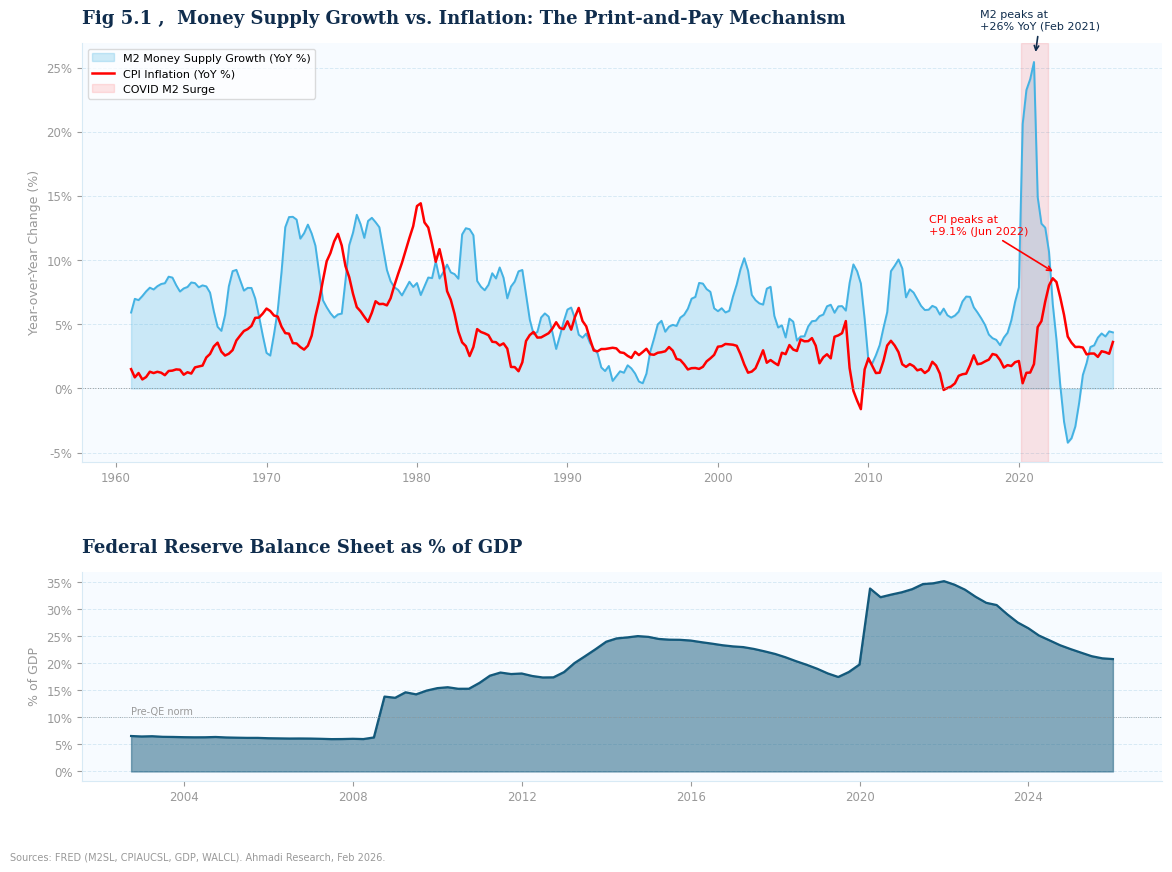

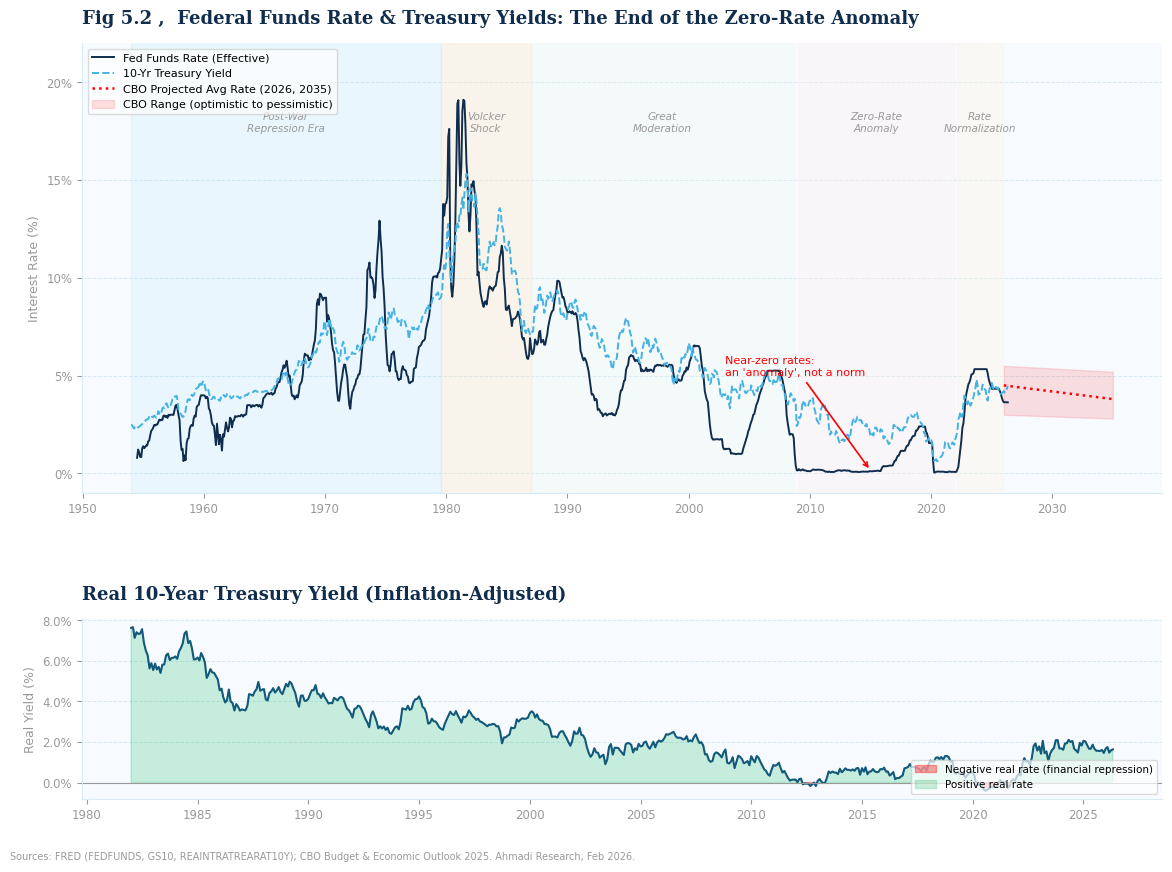

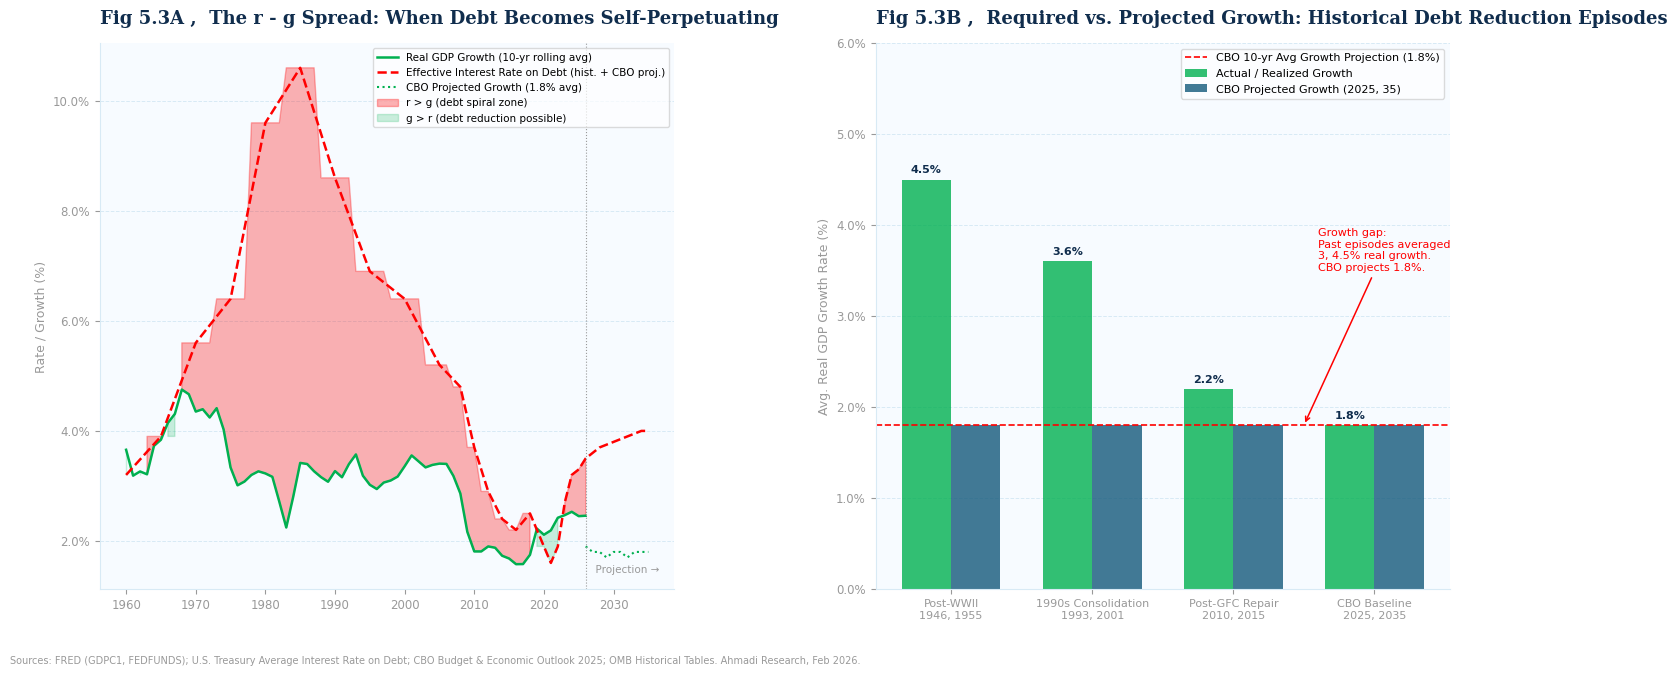

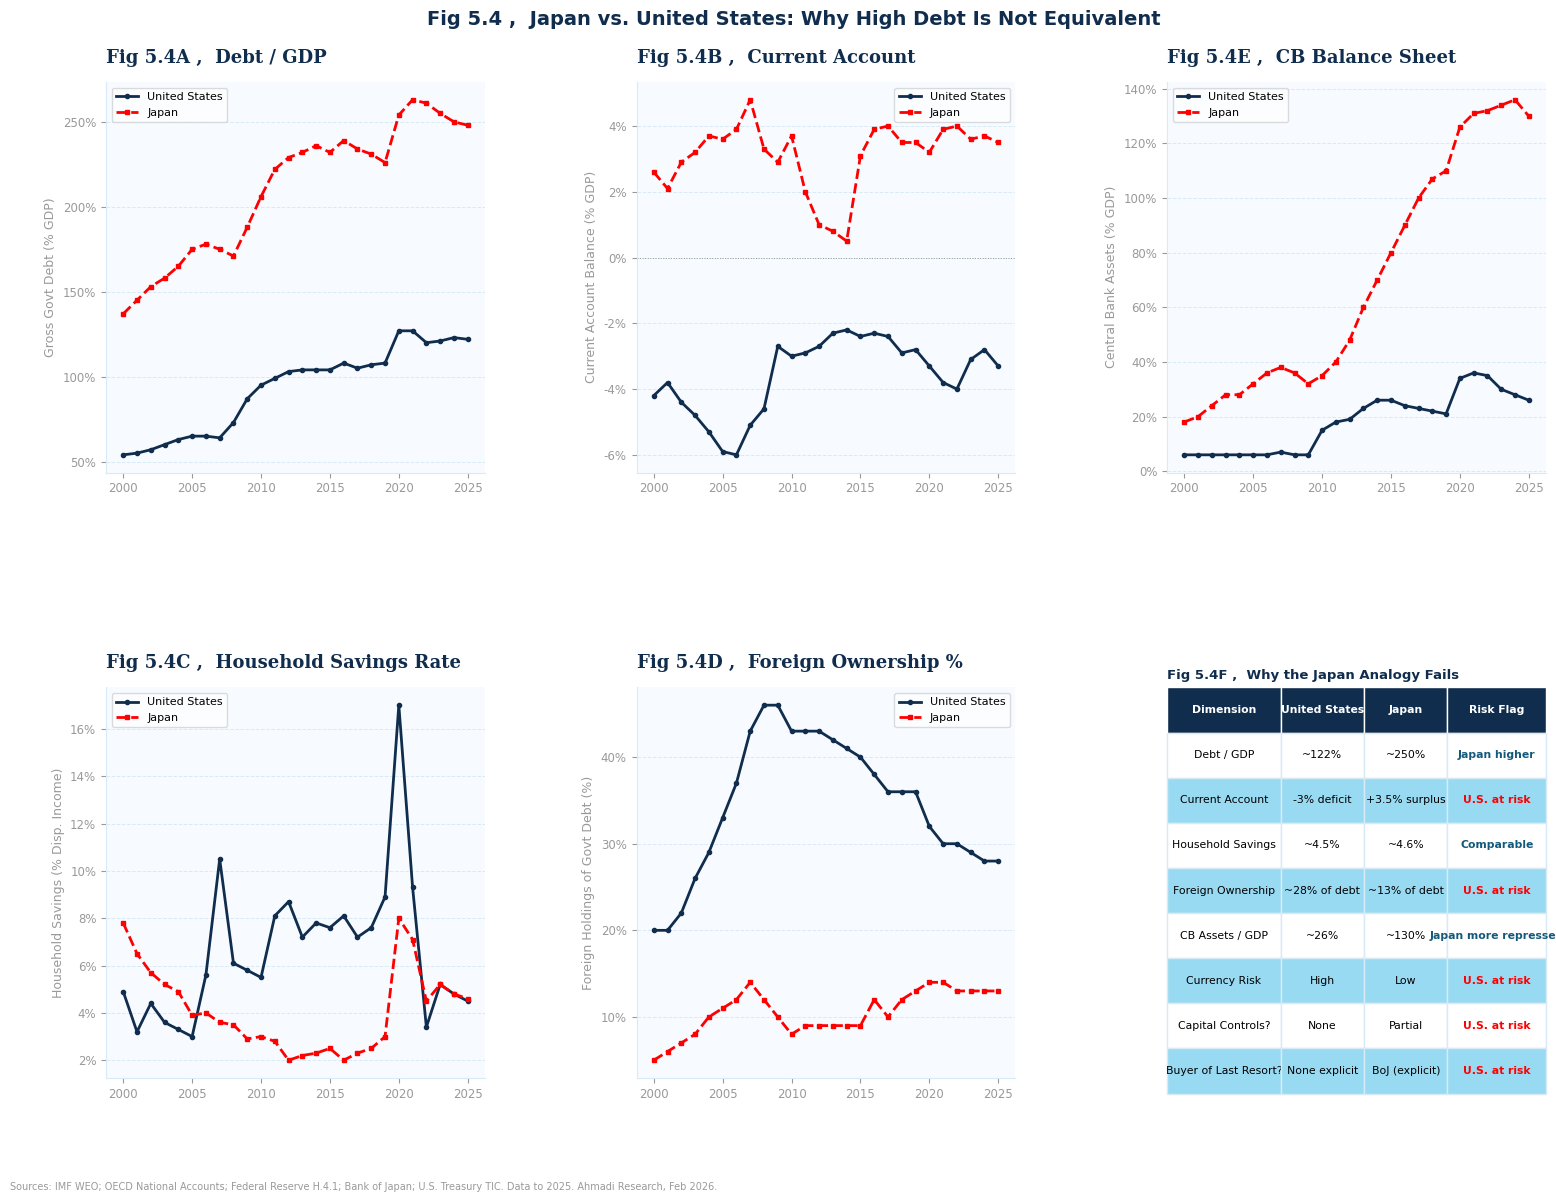

In [9]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import requests
from io import StringIO
from datetime import datetime

warnings.filterwarnings("ignore")

# ── Brand palette ──────────────────────────────────────────────────────────────
NAVY        = "#102D4D"
DARK_TEAL   = "#13597B"
BLUE        = "#44B2E3"
LIGHT_BLUE  = "#99DAF3"
RED         = "#FF0000"   # Warning / alert only
WHITE       = "#FFFFFF"
GREY        = "#999999"
GREEN       = "#00B050"   # Positive / counterpoint

BACKGROUND  = "#F7FBFF"   # Very light blue-white page bg
GRIDCOLOR   = "#D8EAF5"


# ── Helper: fetch FRED series via CSV download ──────────────────────────────────
def apply_brand(ax, title, xlabel=None, ylabel=None, footnote=None, fig=None):
    """Apply Ahmadi Research brand styling to an axes."""
    ax.set_facecolor(BACKGROUND)
    if fig:
        fig.patch.set_facecolor(WHITE)
    ax.set_title(title, color=NAVY, fontsize=13, fontweight="bold",
                 pad=14, loc="left", fontfamily="serif")
    if xlabel:
        ax.set_xlabel(xlabel, color=GREY, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=GREY, fontsize=9)
    ax.tick_params(colors=GREY, labelsize=8.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRIDCOLOR)
    ax.spines["bottom"].set_color(GRIDCOLOR)
    ax.yaxis.grid(True, color=GRIDCOLOR, linewidth=0.7, linestyle="--")
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    if footnote and fig:
        fig.text(0.01, 0.01, footnote, color=GREY, fontsize=7, va="bottom")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 5.1  "The U.S. Can Always Print"
# Chart: M2 money supply growth YoY vs CPI inflation YoY (1960, present)
# Annotate: COVID M2 surge → lagged inflation surge
# Sub-panel: Fed balance sheet as % of GDP
# ══════════════════════════════════════════════════════════════════════════════
def fig_51():

    m2   = fred("M2SL",  "1960-01-01")   # M2 money supply (billions $)
    cpi  = fred("CPIAUCSL", "1960-01-01")  # CPI All Urban
    gdp  = fred("GDP",   "2000-01-01")   # Nominal GDP (billions $)
    walcl= fred("WALCL", "2000-01-01")   # Fed total assets (millions $)

    # YoY % change
    m2_yoy  = m2.resample("QS").mean().pct_change(4) * 100
    cpi_yoy = cpi.resample("QS").mean().pct_change(4) * 100

    # Fed balance sheet % GDP
    if gdp is not None and walcl is not None:
        walcl_q   = (walcl / 1e3).resample("QS").mean()   # → billions
        gdp_q     = gdp.resample("QS").last().ffill()
        common    = walcl_q.index.intersection(gdp_q.index)
        fed_pct   = (walcl_q.loc[common] / gdp_q.loc[common]) * 100
    else:
        fed_pct = None

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9),
                                   gridspec_kw={"height_ratios": [2, 1]},
                                   facecolor=WHITE)
    fig.subplots_adjust(hspace=0.35, left=0.07, right=0.97, top=0.92, bottom=0.10)

    # ── Top panel ──
    apply_brand(ax1,
                "Fig 5.1 ,  Money Supply Growth vs. Inflation: The Print-and-Pay Mechanism",
                ylabel="Year-over-Year Change (%)", fig=fig)

    ax1.fill_between(m2_yoy.index, m2_yoy, alpha=0.25, color=BLUE, label="M2 Money Supply Growth (YoY %)")
    ax1.plot(m2_yoy.index, m2_yoy, color=BLUE, linewidth=1.4)
    ax1.plot(cpi_yoy.index, cpi_yoy, color=RED, linewidth=1.8, label="CPI Inflation (YoY %)")

    # Annotate COVID surge
    ax1.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
                alpha=0.10, color=RED, label="COVID M2 Surge")
    ax1.annotate("M2 peaks at\n+26% YoY (Feb 2021)",
                 xy=(pd.Timestamp("2021-02-01"), 26),
                 xytext=(pd.Timestamp("2017-06-01"), 28),
                 arrowprops=dict(arrowstyle="->", color=NAVY, lw=1.2),
                 fontsize=8, color=NAVY)
    ax1.annotate("CPI peaks at\n+9.1% (Jun 2022)",
                 xy=(pd.Timestamp("2022-06-01"), 9),
                 xytext=(pd.Timestamp("2014-01-01"), 12),
                 arrowprops=dict(arrowstyle="->", color=RED, lw=1.2),
                 fontsize=8, color=RED)

    ax1.axhline(0, color=GREY, linewidth=0.7, linestyle=":")
    ax1.legend(fontsize=8, framealpha=0.7, loc="upper left")
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

    # ── Bottom panel: Fed balance sheet % GDP ──
    apply_brand(ax2, "Federal Reserve Balance Sheet as % of GDP",
                ylabel="% of GDP", fig=fig)
    if fed_pct is not None and len(fed_pct) > 0:
        ax2.fill_between(fed_pct.index, fed_pct, alpha=0.5, color=DARK_TEAL)
        ax2.plot(fed_pct.index, fed_pct, color=DARK_TEAL, linewidth=1.6)
        ax2.axhline(10, color=GREY, linewidth=0.6, linestyle=":")
        ax2.text(fed_pct.index[0], 10.5, "Pre-QE norm", color=GREY, fontsize=7)
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

    fig.text(0.01, 0.01,
             "Sources: FRED (M2SL, CPIAUCSL, GDP, WALCL). Ahmadi Research, Feb 2026.",
             color=GREY, fontsize=7, va="bottom")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 5.2  "Interest Rates Will Come Back Down"
# Chart: Federal Funds Rate 1954, present with structural regime labels
# Overlay: 10-yr Treasury yield & CBO projected average rate
# Shade: zero-lower-bound era 2009, 2021 as the "anomaly"
# ══════════════════════════════════════════════════════════════════════════════
def fig_52():

    ffr  = fred("FEDFUNDS", "1954-01-01")   # Monthly effective fed funds rate
    t10  = fred("GS10",     "1954-01-01")   # 10-year Treasury yield
    r    = fred("REAINTRATREARAT10Y", "1982-01-01")  # 10-yr real rate (TIPS-based)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9),
                                   gridspec_kw={"height_ratios": [3, 1.2]},
                                   facecolor=WHITE)
    fig.subplots_adjust(hspace=0.4, left=0.07, right=0.97, top=0.92, bottom=0.08)

    apply_brand(ax1,
                "Fig 5.2 ,  Federal Funds Rate & Treasury Yields: The End of the Zero-Rate Anomaly",
                ylabel="Interest Rate (%)", fig=fig)

    if ffr is not None:
        ax1.plot(ffr.index, ffr, color=NAVY, linewidth=1.4, label="Fed Funds Rate (Effective)")
    if t10 is not None:
        ax1.plot(t10.index, t10, color=BLUE, linewidth=1.4, linestyle="--", label="10-Yr Treasury Yield")

    # Shade structural regimes
    regimes = [
        ("1954-01-01", "1979-08-01", LIGHT_BLUE, "Post-War\nRepression Era", 0.15),
        ("1979-08-01", "1987-01-01", "#FFE0B2", "Volcker\nShock", 0.25),
        ("1987-01-01", "2008-09-01", "#E8F5E9", "Great\nModeration", 0.20),
        ("2009-01-01", "2021-12-01", "#FFEBEE", "Zero-Rate\nAnomaly", 0.30),
        ("2022-03-01", "2025-12-01", "#FFF3E0", "Rate\nNormalization", 0.30),
    ]
    for s, e, c, lbl, alpha in regimes:
        ax1.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=alpha, color=c)
        mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
        ax1.text(mid, 18.5, lbl, ha="center", va="top",
                 fontsize=7.5, color=GREY, style="italic")

    # CBO projected range 2026, 2035
    proj_x = [pd.Timestamp("2026-01-01"), pd.Timestamp("2035-01-01")]
    proj_y = [4.5, 3.8]   # CBO baseline assumption
    ax1.plot(proj_x, proj_y, color=RED, linewidth=1.8,
             linestyle=":", label="CBO Projected Avg Rate (2026, 2035)")
    ax1.fill_between(proj_x, [3.0, 2.8], [5.5, 5.2], alpha=0.12, color=RED,
                     label="CBO Range (optimistic to pessimistic)")

    ax1.annotate("Near-zero rates:\nan 'anomaly', not a norm",
                 xy=(pd.Timestamp("2015-01-01"), 0.15),
                 xytext=(pd.Timestamp("2003-01-01"), 5),
                 arrowprops=dict(arrowstyle="->", color=RED, lw=1.2),
                 fontsize=8, color=RED)

    ax1.set_ylim(-1, 22)
    ax1.legend(fontsize=8, framealpha=0.7, loc="upper left")
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

    # ── Bottom: real 10-yr rate ──
    apply_brand(ax2, "Real 10-Year Treasury Yield (Inflation-Adjusted)",
                ylabel="Real Yield (%)", fig=fig)
    if r is not None:
        ax2.plot(r.index, r, color=DARK_TEAL, linewidth=1.5)
        ax2.fill_between(r.index, r, 0,
                         where=(r < 0), alpha=0.35, color=RED, label="Negative real rate (financial repression)")
        ax2.fill_between(r.index, r, 0,
                         where=(r >= 0), alpha=0.2, color=GREEN, label="Positive real rate")
        ax2.axhline(0, color=GREY, linewidth=0.8)
        ax2.legend(fontsize=7.5, loc="lower right", framealpha=0.7)
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

    fig.text(0.01, 0.01,
             "Sources: FRED (FEDFUNDS, GS10, REAINTRATREARAT10Y); CBO Budget & Economic Outlook 2025. "
             "Ahmadi Research, Feb 2026.",
             color=GREY, fontsize=7, va="bottom")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 5.3  "Growth Will Solve the Problem"
# Panel A: Real GDP growth rate (10yr rolling avg) vs effective interest rate on debt
#          → show r-g spread turning persistently positive
# Panel B: Historical debt reduction episodes required growth rates vs. today's projections
# ══════════════════════════════════════════════════════════════════════════════
def fig_53():

    gdp_real = fred("GDPC1",  "1950-01-01")     # Real GDP chained 2017$
    ffr      = fred("FEDFUNDS","1954-01-01")     # Use as proxy for effective rate

    # Real GDP growth YoY (quarterly, annualized)
    g_yoy = gdp_real.pct_change(4) * 100
    g_roll10 = g_yoy.rolling(40).mean()  # 10-year rolling average (40 quarters)

    # Effective interest rate on the debt ,  hardcoded from Treasury/FRED data
    # Source: U.S. Treasury, Average Interest Rate on Marketable Debt (annual)
    eff_rate_data = {
        1960: 3.2, 1965: 3.9, 1970: 5.6, 1975: 6.4, 1980: 9.6, 1985: 10.6,
        1990: 8.6, 1995: 6.9, 2000: 6.4, 2005: 5.2, 2008: 4.8, 2010: 3.7,
        2012: 2.9, 2014: 2.4, 2016: 2.2, 2018: 2.5, 2020: 1.9, 2021: 1.6,
        2022: 1.9, 2023: 2.7, 2024: 3.2, 2025: 3.3
    }
    # CBO projections 2026, 2035
    cbo_eff = {2026: 3.5, 2027: 3.6, 2028: 3.7, 2029: 3.75, 2030: 3.8,
               2031: 3.85, 2032: 3.9, 2033: 3.95, 2034: 4.0, 2035: 4.0}
    eff_rate_data.update(cbo_eff)

    eff_rate = pd.Series(eff_rate_data)
    eff_rate.index = pd.to_datetime([f"{y}-01-01" for y in eff_rate.index])

    # CBO real GDP growth projections (2026, 2035 ≈ 1.8% avg)
    cbo_g = pd.Series(
        [1.9, 1.8, 1.8, 1.7, 1.8, 1.8, 1.7, 1.8, 1.8, 1.8],
        index=pd.to_datetime([f"{y}-01-01" for y in range(2026, 2036)])
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), facecolor=WHITE)
    fig.subplots_adjust(wspace=0.35, left=0.07, right=0.97, top=0.90, bottom=0.12)

    # ── Left: r-g spread over time ──
    apply_brand(ax1,
                "Fig 5.3A ,  The r - g Spread: When Debt Becomes Self-Perpetuating",
                ylabel="Rate / Growth (%)", fig=fig)

    g_annual = g_roll10.resample("YS").mean().dropna()
    common   = g_annual.index.intersection(eff_rate.index)
    r_minus_g = eff_rate.loc[common] - g_annual.loc[common]

    ax1.plot(g_annual.index, g_annual, color=GREEN, linewidth=1.8,
             label="Real GDP Growth (10-yr rolling avg)")
    ax1.plot(eff_rate.index, eff_rate, color=RED, linewidth=1.8, linestyle="--",
             label="Effective Interest Rate on Debt (hist. + CBO proj.)")
    # CBO projections
    ax1.plot(cbo_g.index, cbo_g, color=GREEN, linewidth=1.5,
             linestyle=":", label="CBO Projected Growth (1.8% avg)")
    # r-g fill
    common_idx = g_annual.dropna().index
    ef_interp = eff_rate.reindex(common_idx, method="nearest")
    ax1.fill_between(common_idx,
                     g_annual.loc[common_idx], ef_interp,
                     where=(ef_interp > g_annual.loc[common_idx]),
                     alpha=0.3, color=RED, label="r > g (debt spiral zone)")
    ax1.fill_between(common_idx,
                     g_annual.loc[common_idx], ef_interp,
                     where=(ef_interp <= g_annual.loc[common_idx]),
                     alpha=0.2, color=GREEN, label="g > r (debt reduction possible)")

    ax1.axvline(pd.Timestamp("2026-01-01"), color=GREY, linewidth=0.8, linestyle=":")
    ax1.text(pd.Timestamp("2026-06-01"), ax1.get_ylim()[0] + 0.3, "  Projection →",
             color=GREY, fontsize=7.5)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    ax1.legend(fontsize=7.5, framealpha=0.7, loc="upper right")

    # ── Right: bar chart ,  what growth rate was needed in past debt reduction episodes ──
    apply_brand(ax2,
                "Fig 5.3B ,  Required vs. Projected Growth: Historical Debt Reduction Episodes",
                ylabel="Avg. Real GDP Growth Rate (%)", fig=fig)

    episodes = [
        ("Post-WWII\n1946, 1955", 4.5, 1.8, "Debt: 119%→66% GDP"),
        ("1990s Consolidation\n1993, 2001", 3.6, 1.8, "Debt: 49%→32% GDP"),
        ("Post-GFC Repair\n2010, 2015", 2.2, 1.8, "Deficit narrowed\n9.8%→2.4% GDP"),
        ("CBO Baseline\n2025, 2035", 1.8, 1.8, "Debt: 100%→118% GDP\n(still rising)"),
    ]
    labels  = [e[0] for e in episodes]
    actual  = [e[1] for e in episodes]
    cbo_proj= [e[2] for e in episodes]
    annots  = [e[3] for e in episodes]

    x = np.arange(len(labels))
    w = 0.35
    bars1 = ax2.bar(x - w/2, actual, w, color=GREEN, alpha=0.8, label="Actual / Realized Growth")
    bars2 = ax2.bar(x + w/2, cbo_proj, w, color=DARK_TEAL, alpha=0.8, label="CBO Projected Growth (2025, 35)")

    for bar, ann in zip(bars1, annots):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{bar.get_height():.1f}%", ha="center", va="bottom",
                 fontsize=8, color=NAVY, fontweight="bold")

    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, fontsize=8)
    ax2.axhline(1.8, color=RED, linewidth=1.2, linestyle="--",
                label="CBO 10-yr Avg Growth Projection (1.8%)")

    # Annotate the gap
    ax2.annotate("Growth gap:\nPast episodes averaged\n3, 4.5% real growth.\nCBO projects 1.8%.",
                 xy=(2.5, 1.8), xytext=(2.6, 3.5),
                 arrowprops=dict(arrowstyle="->", color=RED, lw=1.1),
                 fontsize=8, color=RED, ha="left")

    ax2.set_ylim(0, 6.0)
    ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    ax2.legend(fontsize=8, framealpha=0.7)

    fig.text(0.01, 0.01,
             "Sources: FRED (GDPC1, FEDFUNDS); U.S. Treasury Average Interest Rate on Debt; "
             "CBO Budget & Economic Outlook 2025; OMB Historical Tables. Ahmadi Research, Feb 2026.",
             color=GREY, fontsize=7, va="bottom")


# ══════════════════════════════════════════════════════════════════════════════
# FIG 5.4  "Japan Has Higher Debt and Is Fine"
# Fixed: scorecard uses matplotlib Table to prevent overflow
# ══════════════════════════════════════════════════════════════════════════════
def fig_54():

    from matplotlib.gridspec import GridSpec

    years = list(range(2000, 2026))

    us_ca = [-4.2,-3.8,-4.4,-4.8,-5.3,-5.9,-6.0,-5.1,-4.6,-2.7,
             -3.0,-2.9,-2.7,-2.3,-2.2,-2.4,-2.3,-2.4,-2.9,-2.8,
             -3.3,-3.8,-4.0,-3.1,-2.8,-3.3][:len(years)]
    jp_ca = [ 2.6, 2.1, 2.9, 3.2, 3.7, 3.6, 3.9, 4.8, 3.3, 2.9,
              3.7, 2.0, 1.0, 0.8, 0.5, 3.1, 3.9, 4.0, 3.5, 3.5,
              3.2, 3.9, 4.0, 3.6, 3.7, 3.5][:len(years)]

    us_debt = [ 54, 55, 57, 60, 63, 65, 65, 64, 73, 87,
                95, 99,103,104,104,104,108,105,107,108,
               127,127,120,121,123,122][:len(years)]
    jp_debt = [137,145,153,158,165,175,178,175,171,188,
               206,222,229,232,236,232,239,234,231,226,
               254,263,261,255,250,248][:len(years)]

    us_save_pts = [ 4.9, 3.2, 4.4, 3.6, 3.3, 3.0, 5.6,10.5, 6.1, 5.8,
                    5.5, 8.1, 8.7, 7.2, 7.8, 7.6, 8.1, 7.2, 7.6, 8.9,
                   17.0, 9.3, 3.4, 5.2, 4.8, 4.5][:len(years)]
    jp_save_pts = [ 7.8, 6.5, 5.7, 5.2, 4.9, 3.9, 4.0, 3.6, 3.5, 2.9,
                    3.0, 2.8, 2.0, 2.2, 2.3, 2.5, 2.0, 2.3, 2.5, 3.0,
                    8.0, 7.1, 4.5, 5.2, 4.8, 4.6][:len(years)]

    us_foreign = [20, 20, 22, 26, 29, 33, 37, 43, 46, 46,
                  43, 43, 43, 42, 41, 40, 38, 36, 36, 36,
                  32, 30, 30, 29, 28, 28][:len(years)]
    jp_foreign = [ 5,  6,  7,  8, 10, 11, 12, 14, 12, 10,
                   8,  9,  9,  9,  9,  9, 12, 10, 12, 13,
                  14, 14, 13, 13, 13, 13][:len(years)]

    us_cb = [  6,  6,  6,  6,  6,  6,  6,  7,  6,  6,
              15, 18, 19, 23, 26, 26, 24, 23, 22, 21,
              34, 36, 35, 30, 28, 26][:len(years)]
    jp_cb = [ 18, 20, 24, 28, 28, 32, 36, 38, 36, 32,
              35, 40, 48, 60, 70, 80, 90,100,107,110,
             126,131,132,134,136,130][:len(years)]

    # GridSpec: 2 rows x 3 cols ,  5 line-chart panels + 1 scorecard table
    fig = plt.figure(figsize=(16, 12), facecolor=WHITE)
    fig.suptitle("Fig 5.4 ,  Japan vs. United States: Why High Debt Is Not Equivalent",
                 color=NAVY, fontsize=14, fontweight="bold", y=0.99)
    gs = GridSpec(2, 3, figure=fig,
                  hspace=0.55, wspace=0.40,
                  left=0.07, right=0.97, top=0.93, bottom=0.10)

    ax_a  = fig.add_subplot(gs[0, 0])
    ax_b  = fig.add_subplot(gs[0, 1])
    ax_c  = fig.add_subplot(gs[1, 0])
    ax_d  = fig.add_subplot(gs[1, 1])
    ax_e  = fig.add_subplot(gs[0, 2])
    ax_sc = fig.add_subplot(gs[1, 2])

    yr = np.array(years)
    panel_cfgs = [
        (ax_a, us_debt,     jp_debt,     "Gross Govt Debt (% GDP)",            "Fig 5.4A ,  Debt / GDP",              False),
        (ax_b, us_ca,       jp_ca,       "Current Account Balance (% GDP)",     "Fig 5.4B ,  Current Account",         True),
        (ax_c, us_save_pts, jp_save_pts, "Household Savings (% Disp. Income)",  "Fig 5.4C ,  Household Savings Rate",  False),
        (ax_d, us_foreign,  jp_foreign,  "Foreign Holdings of Govt Debt (%)",   "Fig 5.4D ,  Foreign Ownership %",     False),
        (ax_e, us_cb,       jp_cb,       "Central Bank Assets (% GDP)",         "Fig 5.4E ,  CB Balance Sheet",        False),
    ]
    for ax, us_d, jp_d, ylab, title, add_zero in panel_cfgs:
        apply_brand(ax, title, ylabel=ylab, fig=fig)
        ax.plot(yr, us_d, color=NAVY, linewidth=2.0, marker="o", markersize=3, label="United States")
        ax.plot(yr, jp_d, color=RED,  linewidth=2.0, marker="s", markersize=3,
                linestyle="--", label="Japan")
        if add_zero:
            ax.axhline(0, color=GREY, linewidth=0.7, linestyle=":")
        ax.legend(fontsize=8, framealpha=0.7)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

    # ── Scorecard panel using matplotlib Table (no overflow) ──
    ax_sc.set_facecolor(BACKGROUND)
    for spine in ax_sc.spines.values():
        spine.set_visible(False)
    ax_sc.set_xticks([])
    ax_sc.set_yticks([])
    ax_sc.set_title("Fig 5.4F ,  Why the Japan Analogy Fails",
                    color=NAVY, fontsize=9.5, fontweight="bold", pad=6, loc="left")

    scorecard_data = [
        ["Debt / GDP",         "~122%",         "~250%",          "Japan higher"],
        ["Current Account",    "-3% deficit",   "+3.5% surplus",  "U.S. at risk"],
        ["Household Savings",  "~4.5%",         "~4.6%",          "Comparable"],
        ["Foreign Ownership",  "~28% of debt",  "~13% of debt",   "U.S. at risk"],
        ["CB Assets / GDP",    "~26%",          "~130%",          "Japan more repressed"],
        ["Currency Risk",      "High",          "Low",            "U.S. at risk"],
        ["Capital Controls?",  "None",          "Partial",        "U.S. at risk"],
        ["Buyer of Last Resort?",   "None explicit", "BoJ (explicit)", "U.S. at risk"],
    ]
    col_labels = ["Dimension", "United States", "Japan", "Risk Flag"]

    tbl = ax_sc.table(
        cellText=scorecard_data,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
        bbox=[0.0, -0.04, 1.0, 1.04],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.8)

    # Header row styling
    for col in range(4):
        cell = tbl[(0, col)]
        cell.set_facecolor(NAVY)
        cell.set_text_props(color=WHITE, fontweight="bold")
        cell.set_edgecolor(WHITE)

    # Data row styling
    for row in range(1, len(scorecard_data) + 1):
        bg = LIGHT_BLUE if row % 2 == 0 else WHITE
        for col in range(4):
            cell = tbl[(row, col)]
            cell.set_facecolor(bg)
            cell.set_edgecolor(GRIDCOLOR)
            if col == 3:
                flag = scorecard_data[row - 1][3].lower()
                if "at risk" in flag:
                    cell.set_text_props(color=RED, fontweight="bold")
                else:
                    cell.set_text_props(color=DARK_TEAL, fontweight="bold")

    # Set column widths (relative)
    col_widths = [0.30, 0.22, 0.22, 0.26]
    for col, w in enumerate(col_widths):
        for row in range(len(scorecard_data) + 1):
            tbl[(row, col)].set_width(w)

    fig.text(0.01, 0.005,
             "Sources: IMF WEO; OECD National Accounts; Federal Reserve H.4.1; Bank of Japan; "
             "U.S. Treasury TIC. Data to 2025. Ahmadi Research, Feb 2026.",
             color=GREY, fontsize=7, va="bottom")


# ══════════════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════════════
#  MAIN

# ══════════════════════════════════════════════════════════════════════════════

fig_51()   # 5.1 "Can Always Print" ,  M2 vs inflation + Fed BS
plt.show()
fig_52()   # 5.2 "Rates Will Come Down" ,  structural rate regimes
plt.show()
fig_53()   # 5.3 "Growth Will Solve It" ,  r-g spread + historical episodes
plt.show()
fig_54()   # 5.4 "Japan Is Fine" ,  5-panel comparative dashboard + scorecard
plt.show()
plt.show()


## Section VII, Investment and Geopolitical Implications

Composite figure for Section VII. Sub-panels A through D map to the deck's 'For Fixed-Income Investors', 'For Global Reserve Managers', and 'For the Global Economic Order' subsections.


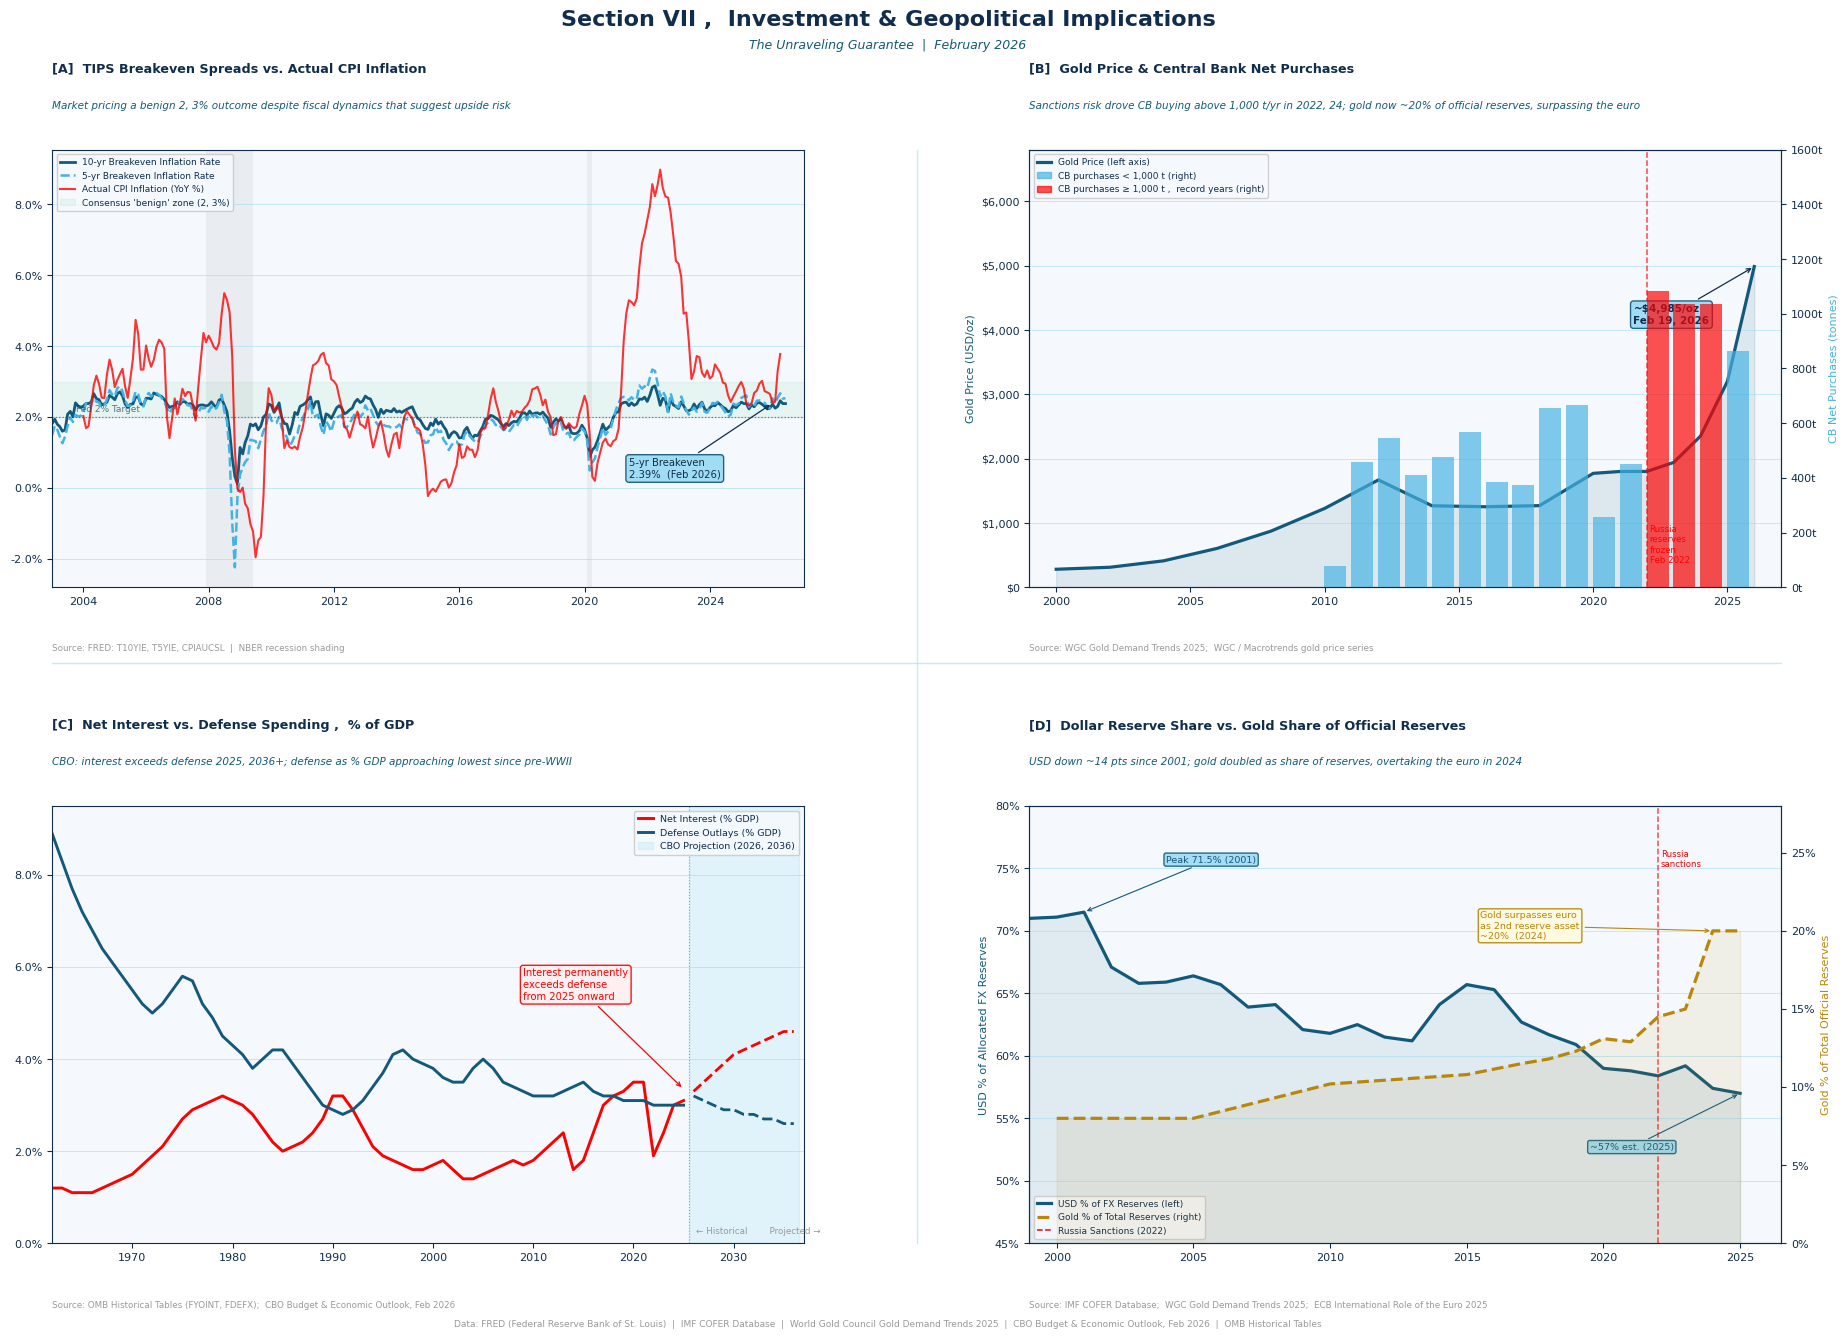

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import requests
from io import StringIO
import warnings
warnings.filterwarnings("ignore")

# ── Output path: always saves to current working directory ───────────────────

# ── Brand palette ─────────────────────────────────────────────────────────────
NAVY   = "#102D4D"
TEAL   = "#13597B"
BLUE   = "#44B2E3"
LBLUE  = "#99DAF3"
RED    = "#FF0000"
GREEN  = "#00B050"
GRAY   = "#999999"
GOLD_C = "#B8860B"
WHITE  = "#FFFFFF"
BG     = "#F5F9FD"

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.facecolor":   BG,
    "figure.facecolor": WHITE,
    "axes.edgecolor":   NAVY,
    "axes.labelcolor":  NAVY,
    "xtick.color":      NAVY,
    "ytick.color":      NAVY,
    "text.color":       NAVY,
    "grid.color":       LBLUE,
    "grid.linewidth":   0.7,
    "grid.alpha":       0.55,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
})

# ── FRED helper (no API key needed) ──────────────────────────────────────────
def recession_bands(ax, start="2000-01-01"):
    bands = [("2001-03-01","2001-11-01"),
             ("2007-12-01","2009-06-01"),
             ("2020-02-01","2020-04-01")]
    yl = ax.get_ylim()
    for s, e in bands:
        if pd.Timestamp(e) > pd.Timestamp(start):
            ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                       color=GRAY, alpha=0.13, zorder=0, lw=0)
    ax.set_ylim(yl)

def panel_header(ax, letter, title, subtitle):
    """Clean two-line header above each panel ,  no set_title() used."""
    ax.set_title("", pad=0)
    ax.text(0, 1.17, f"[{letter}]  {title}",
            transform=ax.transAxes,
            fontsize=9.2, fontweight="bold", color=NAVY,
            va="bottom", clip_on=False)
    ax.text(0, 1.09, subtitle,
            transform=ax.transAxes,
            fontsize=7.5, color=TEAL, fontstyle="italic",
            va="bottom", clip_on=False)

def source_note(ax, txt):
    ax.text(0, -0.13, f"Source: {txt}",
            transform=ax.transAxes,
            fontsize=6.3, color=GRAY, va="top", clip_on=False)


# ════════════════════════════════════════════════════════════════════════════
# FIGURE LAYOUT
# ════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(19, 13.5), facecolor=WHITE)

fig.text(0.5, 0.972,
         "Section VII ,  Investment & Geopolitical Implications",
         ha="center", fontsize=16, fontweight="bold", color=NAVY)
fig.text(0.5, 0.955,
         "The Unraveling Guarantee  |  February 2026",
         ha="center", fontsize=9, color=TEAL, fontstyle="italic")

gs = GridSpec(2, 2, figure=fig,
              hspace=0.50, wspace=0.30,
              left=0.06, right=0.97,
              top=0.88, bottom=0.07)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])


# ════════════════════════════════════════════════════════════════════════════
# PANEL A ,  TIPS Breakevens vs. Actual CPI
# ════════════════════════════════════════════════════════════════════════════
be10 = fetch_fred("T10YIE",   "2003-01-01")
be5  = fetch_fred("T5YIE",    "2003-01-01")
cpi  = fetch_fred("CPIAUCSL", "2003-01-01")

ax = ax_a
if be10 is not None:
    s = be10.resample("MS").last().dropna()
    ax.plot(s.index, s.values, color=TEAL, lw=2,
            label="10-yr Breakeven Inflation Rate")
if be5 is not None:
    s = be5.resample("MS").last().dropna()
    ax.plot(s.index, s.values, color=BLUE, lw=1.8, ls="--",
            label="5-yr Breakeven Inflation Rate")
if cpi is not None:
    yoy = cpi.resample("MS").last().pct_change(12).dropna() * 100
    ax.plot(yoy.index, yoy.values, color=RED, lw=1.5, alpha=0.8,
            label="Actual CPI Inflation (YoY %)")

ax.axhline(2.0, color=NAVY, lw=0.9, ls=":", alpha=0.55)
ax.text(pd.Timestamp("2003-10-01"), 2.15,
        "Fed 2% Target", fontsize=6.5, color=NAVY, alpha=0.65)

if be5 is not None:
    ax.annotate("5-yr Breakeven\n2.39%  (Feb 2026)",
                xy=(pd.Timestamp("2026-01-01"), 2.39),
                xytext=(pd.Timestamp("2021-06-01"), 0.3),
                arrowprops=dict(arrowstyle="->", color=NAVY, lw=0.9),
                fontsize=7.2, color=NAVY,
                bbox=dict(boxstyle="round,pad=0.3",
                          fc=LBLUE, ec=TEAL, alpha=0.92))

ax.axhspan(2.0, 3.0, color=GREEN, alpha=0.06,
           label="Consensus 'benign' zone (2, 3%)")
recession_bands(ax, "2003-01-01")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_xlim(pd.Timestamp("2003-01-01"), pd.Timestamp("2027-01-01"))
ax.legend(fontsize=6.5, framealpha=0.92, loc="upper left", handlelength=1.6)
ax.grid(True, axis="y")
panel_header(ax, "A",
    "TIPS Breakeven Spreads vs. Actual CPI Inflation",
    "Market pricing a benign 2, 3% outcome despite fiscal dynamics that suggest upside risk")
source_note(ax, "FRED: T10YIE, T5YIE, CPIAUCSL  |  NBER recession shading")


# ════════════════════════════════════════════════════════════════════════════
# PANEL B ,  Gold Price & CB Net Purchases (all hardcoded ,  no live fetch)
# ════════════════════════════════════════════════════════════════════════════
# Annual average gold price USD/oz ,  WGC / Macrotrends
g_yrs = [2000,2002,2004,2006,2008,2010,2012,2014,
          2016,2018,2020,2021,2022,2023,2024,2025,2026]
g_px  = [ 279, 310, 410, 604, 872,1225,1668,1266,
          1251,1268,1770,1799,1800,1940,2350,3200,4985]

# CB net purchases (tonnes) ,  WGC Gold Demand Trends Full Year 2025
cb_yrs = [2010,2011,2012,2013,2014,2015,2016,2017,
          2018,2019,2020,2021,2022,2023,2024,2025]
cb_t   = [  77, 457, 544, 409, 477, 566, 384, 374,
           656, 668, 255, 450,1082,1037,1037, 863]

ax  = ax_b
ax2 = ax.twinx()

ax.fill_between(g_yrs, g_px, alpha=0.11, color=TEAL)
ax.plot(g_yrs, g_px, color=TEAL, lw=2.3, label="Gold Price USD/oz (left)")

bcols = [RED if t >= 1000 else BLUE for t in cb_t]
ax2.bar([y + 0.4 for y in cb_yrs], cb_t, width=0.82,
        color=bcols, alpha=0.68, zorder=2)

ax.axvline(2022, color=RED, lw=1.1, ls="--", alpha=0.72)
ax.text(2022.1, 350, "Russia\nreserves\nfrozen\nFeb 2022",
        fontsize=6.2, color=RED, va="bottom")

ax.annotate("~$4,985/oz\nFeb 19, 2026",
            xy=(2026, 4985), xytext=(2021.5, 4100),
            arrowprops=dict(arrowstyle="->", color=NAVY, lw=0.9),
            fontsize=7.5, fontweight="bold", color=NAVY,
            bbox=dict(boxstyle="round,pad=0.28",
                      fc=LBLUE, ec=TEAL, alpha=0.92))

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}t"))
ax.set_ylabel("Gold Price (USD/oz)", fontsize=8, color=TEAL, labelpad=4)
ax2.set_ylabel("CB Net Purchases (tonnes)", fontsize=8, color=BLUE, labelpad=4)
ax.set_ylim(0, 6800);  ax2.set_ylim(0, 1600);  ax.set_xlim(1999, 2027)

handles_b = [
    Line2D([0],[0], color=TEAL,  lw=2.3, label="Gold Price (left axis)"),
    mpatches.Patch(color=BLUE, alpha=0.68, label="CB purchases < 1,000 t (right)"),
    mpatches.Patch(color=RED,  alpha=0.68,
                   label="CB purchases \u2265 1,000 t ,  record years (right)"),
]
ax.legend(handles=handles_b, fontsize=6.5, framealpha=0.92,
          loc="upper left", handlelength=1.5)
ax.grid(True, axis="y", zorder=0)
panel_header(ax, "B",
    "Gold Price & Central Bank Net Purchases",
    "Sanctions risk drove CB buying above 1,000 t/yr in 2022, 24; gold now ~20% of official reserves, surpassing the euro")
source_note(ax, "WGC Gold Demand Trends 2025;  WGC / Macrotrends gold price series")


# ════════════════════════════════════════════════════════════════════════════
# PANEL C ,  Net Interest vs. Defense Spending (% GDP)
# ════════════════════════════════════════════════════════════════════════════
hist_y = list(range(1962, 2026))
int_h = [
    1.2,1.2,1.1,1.1,1.1,1.2,1.3,1.4,1.5,1.7,
    1.9,2.1,2.4,2.7,2.9,3.0,3.1,3.2,3.1,3.0,
    2.8,2.5,2.2,2.0,2.1,2.2,2.4,2.7,3.2,3.2,
    2.9,2.5,2.1,1.9,1.8,1.7,1.6,1.6,1.7,1.8,
    1.6,1.4,1.4,1.5,1.6,1.7,1.8,1.7,1.8,2.0,
    2.2,2.4,1.6,1.8,2.4,3.0,3.2,3.3,3.5,3.5,
    1.9,2.4,3.0,3.1
]
def_h = [
    8.9,8.3,7.7,7.2,6.8,6.4,6.1,5.8,5.5,5.2,
    5.0,5.2,5.5,5.8,5.7,5.2,4.9,4.5,4.3,4.1,
    3.8,4.0,4.2,4.2,3.9,3.6,3.3,3.0,2.9,2.8,
    2.9,3.1,3.4,3.7,4.1,4.2,4.0,3.9,3.8,3.6,
    3.5,3.5,3.8,4.0,3.8,3.5,3.4,3.3,3.2,3.2,
    3.2,3.3,3.4,3.5,3.3,3.2,3.2,3.1,3.1,3.1,
    3.0,3.0,3.0,3.0
]
proj_y   = list(range(2026, 2037))
proj_int = [3.3,3.5,3.7,3.9,4.1,4.2,4.3,4.4,4.5,4.6,4.6]
proj_def = [3.2,3.1,3.0,2.9,2.9,2.8,2.8,2.7,2.7,2.6,2.6]

ax = ax_c
ax.plot(hist_y, int_h[:len(hist_y)], color=RED, lw=2.1, label="Net Interest (% GDP)")
ax.plot(hist_y, def_h[:len(hist_y)], color=TEAL, lw=2.1, label="Defense Outlays (% GDP)")
ax.plot(proj_y, proj_int, color=RED,  lw=2, ls="--")
ax.plot(proj_y, proj_def, color=TEAL, lw=2, ls="--")
ax.axvspan(2025.5, 2036.5, color=LBLUE, alpha=0.22, label="CBO Projection (2026, 2036)")
ax.axvline(2025.5, color=GRAY, lw=0.8, ls=":")
ax.text(2026.2, 0.22, "\u2190 Historical        Projected \u2192",
        fontsize=6.3, color=GRAY)
ax.annotate("Interest permanently\nexceeds defense\nfrom 2025 onward",
            xy=(2025, 3.35), xytext=(2009, 5.3),
            arrowprops=dict(arrowstyle="->", color=RED, lw=0.9),
            fontsize=7.2, color=RED,
            bbox=dict(boxstyle="round,pad=0.28",
                      fc="#fff0f0", ec=RED, alpha=0.92))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_xlim(1962, 2037);  ax.set_ylim(0, 9.5)
ax.legend(fontsize=6.8, framealpha=0.92, loc="upper right", handlelength=1.6)
ax.grid(True, axis="y")
panel_header(ax, "C",
    "Net Interest vs. Defense Spending ,  % of GDP",
    "CBO: interest exceeds defense 2025, 2036+; defense as % GDP approaching lowest since pre-WWII")
source_note(ax, "OMB Historical Tables (FYOINT, FDEFX);  CBO Budget & Economic Outlook, Feb 2026")


# ════════════════════════════════════════════════════════════════════════════
# PANEL D ,  USD Reserve Share vs. Gold Share of Reserves
# ════════════════════════════════════════════════════════════════════════════
usd_y = [1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,
          2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,
          2019,2020,2021,2022,2023,2024,2025]
usd_s = [71.0,71.1,71.5,67.1,65.8,65.9,66.4,65.7,63.9,64.1,
          62.1,61.8,62.5,61.5,61.2,64.1,65.7,65.3,62.7,61.7,
          60.9,59.0,58.8,58.4,59.2,57.4,57.0]

gld_y = [2000,2005,2010,2015,2017,2018,2019,2020,2021,2022,2023,2024,2025]
gld_s = [ 8.0, 8.0,10.2,10.8,11.5,11.8,12.3,13.1,12.9,14.5,15.0,20.0,20.0]

ax  = ax_d
ax2 = ax.twinx()

ax.plot(usd_y, usd_s, color=TEAL, lw=2.3,
        label="USD % of allocated FX Reserves (left)")
ax.fill_between(usd_y, usd_s, 45, alpha=0.09, color=TEAL)
ax2.plot(gld_y, gld_s, color=GOLD_C, lw=2.3, ls="--",
         label="Gold % of total official Reserves (right)")
ax2.fill_between(gld_y, gld_s, alpha=0.09, color=GOLD_C)

ax.axvline(2022, color=RED, lw=1.1, ls="--", alpha=0.7)
ax.text(2022.1, 76.5, "Russia\nsanctions", fontsize=6.2, color=RED, va="top")
ax.annotate("Peak 71.5% (2001)",
            xy=(2001, 71.5), xytext=(2004, 75.5),
            arrowprops=dict(arrowstyle="->", color=TEAL, lw=0.8),
            fontsize=6.8, color=TEAL,
            bbox=dict(boxstyle="round,pad=0.22",
                      fc=LBLUE, ec=TEAL, alpha=0.88))
ax.annotate("~57% est. (2025)",
            xy=(2025, 57.0), xytext=(2019.5, 52.5),
            arrowprops=dict(arrowstyle="->", color=TEAL, lw=0.8),
            fontsize=6.8, color=TEAL,
            bbox=dict(boxstyle="round,pad=0.22",
                      fc=LBLUE, ec=TEAL, alpha=0.88))
ax2.annotate("Gold surpasses euro\nas 2nd reserve asset\n~20%  (2024)",
             xy=(2024, 20.0), xytext=(2015.5, 19.5),
             arrowprops=dict(arrowstyle="->", color=GOLD_C, lw=0.8),
             fontsize=6.8, color=GOLD_C,
             bbox=dict(boxstyle="round,pad=0.22",
                       fc="#fffadf", ec=GOLD_C, alpha=0.92))

ax.set_ylabel("USD % of Allocated FX Reserves",
              fontsize=8, color=TEAL, labelpad=4)
ax2.set_ylabel("Gold % of Total Official Reserves",
               fontsize=8, color=GOLD_C, labelpad=4)
ax.set_ylim(45, 80);  ax2.set_ylim(0, 28);  ax.set_xlim(1999, 2026.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

handles_d = [
    Line2D([0],[0], color=TEAL,   lw=2.3, label="USD % of FX Reserves (left)"),
    Line2D([0],[0], color=GOLD_C, lw=2.3, ls="--",
           label="Gold % of Total Reserves (right)"),
    Line2D([0],[0], color=RED,    lw=1.1, ls="--",
           label="Russia Sanctions (2022)"),
]
ax.legend(handles=handles_d, fontsize=6.5, framealpha=0.92,
          loc="lower left", handlelength=1.5)
ax.grid(True, axis="y", zorder=0)
panel_header(ax, "D",
    "Dollar Reserve Share vs. Gold Share of Official Reserves",
    "USD down ~14 pts since 2001; gold doubled as share of reserves, overtaking the euro in 2024")
source_note(ax, "IMF COFER Database;  WGC Gold Demand Trends 2025;  ECB International Role of the Euro 2025")


# ── Panel separator lines ──────────────────────────────────────────────────
for xv in [0.515]:
    fig.add_artist(plt.Line2D([xv, xv], [0.07, 0.88],
                              transform=fig.transFigure,
                              color=LBLUE, lw=1.0, alpha=0.55))
for yv in [0.50]:
    fig.add_artist(plt.Line2D([0.06, 0.97], [yv, yv],
                              transform=fig.transFigure,
                              color=LBLUE, lw=1.0, alpha=0.55))

# ── Global data footer ─────────────────────────────────────────────────────
fig.text(0.5, 0.008,
         "Data: FRED (Federal Reserve Bank of St. Louis)  |  "
         "IMF COFER Database  |  World Gold Council Gold Demand Trends 2025  |  "
         "CBO Budget & Economic Outlook, Feb 2026  |  OMB Historical Tables",
         ha="center", fontsize=6.5, color=GRAY)

# ── SAVE ───────────────────────────────────────────────────────────────────
plt.show()
